<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        📞 Customer Churn in Telecom 🤖
    </h1>
</div>

# 📂 Overview

**Background**

The **Customer Churn in Telecom – Sample Dataset by IBM** contains customer-level data from a fictional telecommunications company. Each row represents an individual customer, and each column describes demographic information, subscribed services, billing details, and contract characteristics.

The data structure makes it highly suitable for analyzing **customer churn behavior**, identifying retention risk factors, and building predictive machine learning models.

This dataset is ideal for:

* **Exploratory Data Analysis (EDA) on customer behavior**
* **Customer segmentation & retention analysis**
* **Feature engineering for subscription-based businesses**
* **Binary classification modeling (Churn prediction)**
* **Business-driven ML model interpretation**

**Goal of the Project**

Build a machine learning model to **predict customer churn** (`Churn`: Yes/No) based on customer demographics, subscribed services, and billing information.

The objective is to help telecom companies:

* Identify high-risk customers
* Improve retention strategies
* Optimize contract and pricing structures
* Reduce revenue loss

**Key Features**

| Feature Name       | Description                                               |
| ------------------ | --------------------------------------------------------- |
| `customerID`       | Unique customer identifier (not used for modeling)        |
| `gender`           | Customer gender (Male/Female)                             |
| `SeniorCitizen`    | Whether the customer is a senior citizen (0/1)            |
| `Partner`          | Whether the customer has a partner (Yes/No)               |
| `Dependents`       | Whether the customer has dependents (Yes/No)              |
| `tenure`           | Number of months the customer has stayed with the company |
| `PhoneService`     | Whether the customer has phone service                    |
| `MultipleLines`    | Whether the customer has multiple phone lines             |
| `InternetService`  | Type of internet service (DSL, Fiber optic, No)           |
| `OnlineSecurity`   | Online security service subscription                      |
| `OnlineBackup`     | Online backup subscription                                |
| `DeviceProtection` | Device protection service                                 |
| `TechSupport`      | Technical support service                                 |
| `StreamingTV`      | Streaming TV service                                      |
| `StreamingMovies`  | Streaming movies service                                  |
| `Contract`         | Contract type (Month-to-month, One year, Two year)        |
| `PaperlessBilling` | Whether paperless billing is enabled                      |
| `PaymentMethod`    | Payment method type                                       |
| `MonthlyCharges`   | Monthly subscription charges                              |
| `TotalCharges`     | Total charges accumulated                                 |
| `Churn`            | Target variable (Yes = churned, No = retained)            |

**Files Provided**

From *Kaggle Playground Series – Season 6, Episode 3*:

* `train.csv`: Training dataset with target.
* `test.csv`: Test dataset without target.
* `sample_submission.csv`: Submission template.
* Data is synthetically generated based on realistic health indicator distributions.

(Source: [Kaggle Competition – S6E3](https://www.kaggle.com/competitions/playground-series-s6e3))

From *IBM Sample Telco Customer Churn Dataset (Kaggle)*:

* `WA_Fn-UseC_-Telco-Customer-Churn.csv`: Main dataset containing customer information and churn label.
* The dataset is publicly available on Kaggle and widely used for churn prediction benchmarking.

(Source: [Customer Churn in Telecom – Sample Dataset by IBM](https://www.kaggle.com/datasets/thedrzee/customer-churn-in-telecom-sample-dataset-by-ibm))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin > pip_log_pingouin.txt 2>&1

In [2]:
# =====================================================
# Core Data Manipulation
# =====================================================
import pandas as pd                                         # DataFrame creation & manipulation
import numpy as np                                          # Numerical computing (arrays, math ops)

# =====================================================
# Visualization & Interactive Plotting
# =====================================================
import matplotlib.pyplot as plt                             # Base plotting (static matplotlib)
import seaborn as sns                                       # Statistical & high-level visualization

# =====================================================
# Statistical Distribution & Diagnostics
# =====================================================
from scipy.stats import (
    skew,                                                   # Distribution skewness
    kurtosis,                                               # Distribution kurtosis
    probplot                                                # Q-Q plot for normality check
)

# =====================================================
# Jupyter Display Utilities
# =====================================================
from IPython.display import (
    display,                                                # Display DataFrame/objects
    HTML                                                    # Render custom HTML in notebook
)

# =====================================================
# Machine Learning - Data Splitting & Preprocessing
# =====================================================
from sklearn.model_selection import (
    StratifiedKFold                                         # Stratified cross-validation
)
from sklearn.preprocessing import LabelEncoder
from sklearn.base import (
    BaseEstimator,                                          # Base class for custom estimators
    TransformerMixin                                        # Mixin for custom transformers
)

# =====================================================
# Machine Learning - Evaluation Metrics
# =====================================================
from sklearn.metrics import (
    confusion_matrix,                                       # Classification confusion matrix
    roc_curve,                                              # ROC curve points
    roc_auc_score,                                          # ROC-AUC score
    precision_recall_curve,                                 # Precision-Recall curve
    average_precision_score,                                # Average precision (PR-AUC)
    classification_report                                   # Generate full classification summary (precision, recall, f1-score, support)
)

# =====================================================
# Machine Learning Models
# =====================================================
from xgboost import XGBClassifier                           # Gradient boosting (XGBoost)
import lightgbm as lgb                                      # Gradient boosting (LightGBM)
from catboost import CatBoostClassifier                     # Gradient boosting (CatBoost)

# =====================================================
# Hyperparameter Optimization
# =====================================================
import optuna                                               # Hyperparameter tuning framework
optuna.logging.set_verbosity(
    optuna.logging.WARNING                                  # Reduce Optuna logging noise
)

# =====================================================
# Statistical Hypothesis Testing
# =====================================================
from scipy.stats import (
    chi2_contingency,                                       # Chi-square test (categorical)
    kruskal,                                                # Kruskal-Wallis (non-parametric ANOVA)
    levene,                                                 # Variance homogeneity test
    ttest_ind,                                              # Independent t-test (parametric)
    mannwhitneyu                                            # Mann-Whitney U test (non-parametric)
)

import scikit_posthocs as sp                                # Post-hoc statistical tests
import pingouin as pg                                       # Statistical utilities & effect sizes

# =====================================================
# Statistical Modeling (ANOVA / Regression / OLS)
# =====================================================
import statsmodels.formula.api as smf                       # Formula-based statistical modeling
from statsmodels.formula.api import ols                     # Ordinary Least Squares regression
from statsmodels.stats.anova import anova_lm                # ANOVA table
from statsmodels.stats.multicomp import pairwise_tukeyhsd   # Tukey HSD multiple comparison

# =====================================================
# System, Logging & Utilities
# =====================================================
import logging                                              # Logging system
from logging.handlers import RotatingFileHandler            # Log handler that rotates log files based on size limits
import sys                                                  # System-specific parameters
import os                                                   # OS interaction (paths, env vars)

from typing import (
    List,                                                   # List type hint
    Optional,                                               # Optional type hint
    Iterable                                                # Iterable type hint
)

import gc                                                   # Garbage collection (memory cleanup)
from colorlog import ColoredFormatter                       # Colored log formatter for enhanced console readability

# =====================================================
# Notebook Settings & Environment Control
# =====================================================
import warnings
warnings.filterwarnings("ignore")                           # Suppress warning messages

pd.set_option("display.max_columns", 500)                   # Display up to 500 columns
pd.set_option("display.max_colwidth", None)                 # Unlimited column width

In [3]:
class config:
    """
    Global configuration class for:
    - Reproducibility
    - Data paths
    - Logging
    - Data utilities
    """

    # Reproducibility & Experiment Settings
    random_state = 42                   # Global random seed for reproducibility
    n_split_kfold = 5                   # Number of folds for cross-validation
    threshold  = 0.5                    # Probability cutoff used to convert predicted probabilities into binary class labels
    target_feature = "Churn"            # Target column name
    customer_column = "customerID"      # Unique ID column
    id_column = "id"                    # Unique ID column

    # ========= Data Paths =========
    original_data = "/kaggle/input/datasets/thedrzee/customer-churn-in-telecom-sample-dataset-by-ibm/WA_Fn-UseC_-Telco-Customer-Churn.csv"
    train_data = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
    test_data = "/kaggle/input/competitions/playground-series-s6e3/test.csv"

    # Main color palette for plots/dashboards
    COLORS = ["#667eea", "#764ba2", "#a855f7", "#f093fb", "#fbc2eb"]

    # ========= Logger =========
    @staticmethod
    def setup_notebook_logger(level: int = logging.DEBUG, log_file: str | None = None) -> logging.Logger:
        """
        Create a clean logger for Jupyter Notebook.
        - Prevent duplicated logs when re-running cells
        - Output logs to stdout
        """
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False   # Prevent logs from propagating to the root logger

        # Clear handlers to avoid duplicate logs
        if logger.hasHandlers():
            logger.handlers.clear()

        # Colored Console Format
        color_formatter = ColoredFormatter(
            "%(log_color)s%(asctime)s | "
            "%(levelname)-8s | "
            # "%(cyan)s%(name)s:%(funcName)s%(reset)s - "
            "%(message)s",
            datefmt="%Y-%m-%d %H:%M:%S",
            log_colors={
                "DEBUG": "white",
                "INFO": "green",
                "WARNING": "yellow",
                "ERROR": "red",
                "CRITICAL": "bold_red",
            },
            secondary_log_colors={},
            style="%"
        )

        console_handler = logging.StreamHandler(sys.stdout)
        console_handler.setFormatter(color_formatter)
        logger.addHandler(console_handler)

        # File Handler (No color)
        if log_file:
            file_formatter = logging.Formatter(
                "%(asctime)s | %(levelname)-8s | %(message)s",
                datefmt="%Y-%m-%d %H:%M:%S",
            )

            file_handler = RotatingFileHandler(
                log_file,
                maxBytes=500 * 1024 * 1024,
                backupCount=5
            )
            file_handler.setFormatter(file_formatter)
            logger.addHandler(file_handler)

        logger.info(
            f"Logging configured: level={logging.getLevelName(level)}, format=colored"
        )

        return logger

    # ========= Data Utils =========
    @staticmethod
    def read_csv_safe(path: str, logger: logging.Logger, 
                      encodings: Iterable[str] = ("utf-8", "latin1", "cp1252", "ISO-8859-1")) -> Optional[pd.DataFrame]:
        """
        Safely read CSV file by trying multiple encodings.
        Log progress and failures.
        """
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded file with encoding: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed with encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("CSV file is empty.")
                return None
            except pd.errors.ParserError:
                logger.error("CSV parsing error. Please check file format.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error while reading CSV: {e}")
                return None
        logger.error("Unable to read file with all provided encodings.")
        return None

    @staticmethod
    def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
        """
        Standardize column names.
        """
        df.columns = (
            df.columns
            .str.strip()
            .str.replace(r"[^\w\s]", "", regex=True)   # remove special chars
            .str.replace(r"\s+", "_", regex=True)
        )
        return df

    @staticmethod
    def reduce_mem_usage(cols: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """
        Reduce memory usage by downcasting numeric types.
        """
        for col in cols:
            col_type = df[col].dtype
            if pd.api.types.is_numeric_dtype(col_type):
                c_min = df[col].min()
                c_max = df[col].max()
                # Integer
                if pd.api.types.is_integer_dtype(col_type):
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    else:
                        pass
                else: # Float
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype("category")
        return df

    @staticmethod
    def convert_cat(features: List[str], df: pd.DataFrame) -> pd.DataFrame:
        """
        Convert specified columns in a DataFrame to categorical type.
        """
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

    @staticmethod
    def memory_report(df: pd.DataFrame) -> float:
        """
        Return dataframe memory usage in MB.
        """
        return round(df.memory_usage(deep=True).sum() / 1024**2, 2)

    # XGBoost Hyperparameters
    xgb_params = {
        "n_estimators": 5000,
        "learning_rate": 0.02,
        "max_depth": 4,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "min_child_weight": 3,
        "gamma": 0.1,
        "reg_alpha": 0.1,
        "reg_lambda": 2.0,
        "random_state": random_state,
        "n_jobs": -1,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "verbose": 0,
        "tree_method": "hist",
        "device": "cuda",
        "max_bin": 256,
        "grow_policy": "lossguide",
        "use_label_encoder": False,
        "booster": "gbtree"
    }

    # LightGBM Hyperparameters
    lgb_params = {
        "n_estimators": 8000,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "objective": "binary",
        "random_state": random_state,
        "n_jobs": -1,
        "device": "cpu",
        "max_bin": 255,
        "metric": "AUC",
        "verbose": -1
    }

    # CatBoost Hyperparameters
    cat_params = {
        "iterations": 10000, 
        "learning_rate": 0.02, 
        "depth": 8,
        "l2_leaf_reg": 3.0, 
        "random_seed": random_state,
        "task_type": "GPU",
        "devices": "0", 
        "verbose": False, 
        "eval_metric": "Logloss",
        "grow_policy": "Lossguide",
        "loss_function": "Logloss",
        "bootstrap_type": "Bernoulli",
        "verbose": 0,
        "thread_count": -1
    }

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>

In [4]:
# Initialize notebook logger
logger = config.setup_notebook_logger()

# Load datasets safely
df_train = config.read_csv_safe(config.train_data, logger).pipe(config.clean_columns)
df_test = config.read_csv_safe(config.test_data, logger).pipe(config.clean_columns)
df_original = config.read_csv_safe(config.original_data, logger).pipe(config.clean_columns)

2026-03-02 09:17:36 | INFO     | Logging configured: level=DEBUG, format=colored
2026-03-02 09:17:39 | INFO     | Loaded file with encoding: utf-8 | Shape: (594194, 21)
2026-03-02 09:17:39 | INFO     | Loaded file with encoding: utf-8 | Shape: (254655, 20)
2026-03-02 09:17:39 | INFO     | Loaded file with encoding: utf-8 | Shape: (7043, 21)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
datasets = {
    "Train": df_train,
    "Test": df_test,
    "Original": df_original,
}

for name, df in datasets.items():
    logger.info(f"{name} Data Preview")
    display(df.head())

2026-03-02 09:17:39 | INFO     | Train Data Preview


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


2026-03-02 09:17:39 | INFO     | Test Data Preview


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


2026-03-02 09:17:39 | INFO     | Original Data Preview


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-03-02 09:17:40 | INFO     | Train Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          5

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">
<h2 style="color:#f9e79f; margin-top:0;">📊 Insights from Initial Data Exploration</h2>

<h3>Dataset Size and Structure</h3>
<ul>
  <li><b>Training dataset</b>: 594,194 samples, 21 columns (including <code>churn</code>).</li>
  <li><b>Test dataset</b>: 254,655 samples, 20 columns (excluding <code>churn</code>).</li>
  <li><b>Original IBM dataset</b>: 7,043 samples, 21 columns.</li>
  <li>Train and test share identical feature structure except for <code>churn</code>.</li>
  <li>Larger synthetic datasets support robust training and evaluation.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li>Includes customer demographics, subscriptions, contract details, and billing information.</li>
  <li><b>Numerical features:</b> <code>tenure</code>, <code>MonthlyCharges</code>, <code>TotalCharges</code>.</li>
  <li><b>Categorical features:</b> <code>gender</code>, <code>Partner</code>, <code>Dependents</code>, 
      <code>PhoneService</code>, <code>MultipleLines</code>, <code>InternetService</code>, 
      <code>OnlineSecurity</code>, <code>OnlineBackup</code>, <code>DeviceProtection</code>, <code>TechSupport</code>, 
      <code>StreamingTV</code>, <code>StreamingMovies</code>, <code>Contract</code>, 
      <code>PaperlessBilling</code>, <code>PaymentMethod</code>.
  </li>
  <li><code>churn</code> is a binary categorical variable (Yes/No).</li>
</ul>

<h3>Data Completeness and Types</h3>
<ul>
  <li>No missing values detected.</li>
  <li>Categorical variables stored as <code>str</code> require encoding.</li>
  <li><code>TotalCharges</code> corrected from <code>str</code> to <code>float</code> in processed data.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>Training dataset: ~149 MB.</li>
  <li>Test dataset: ~61 MB.</li>
  <li>Memory mainly driven by string categorical columns.</li>
  <li>Converting to <code>category</code> dtype improves efficiency.</li>
</ul>

</div>

In [7]:
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_features = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", 
                "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]

df_train["SeniorCitizen"] = df_train["SeniorCitizen"].replace({1: "Yes", 0: "No"})
df_test["SeniorCitizen"] = df_test["SeniorCitizen"].replace({1: "Yes", 0: "No"})
df_original["SeniorCitizen"] = df_original["SeniorCitizen"].replace({1: "Yes", 0: "No"})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop columns id
df_train.drop(columns=config.id_column, inplace=True)
list_test_id = df_test[config.id_column].copy().to_list()
df_test.drop(columns=config.id_column, inplace=True)
df_original.drop(columns=config.customer_column, inplace=True)

# Display information about the DataFrames
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## Numerical Feature Summary — Data Analyst Perspective

In [8]:
cm = sns.light_palette("blue", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-03-02 09:17:41 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
tenure,594194.000000,36.577258,25.061922,1.000000,12.000000,35.000000,62.000000,72.000000
MonthlyCharges,594194.000000,65.866223,31.067444,18.250000,29.900000,74.100000,90.800000,118.750000
TotalCharges,594194.000000,2494.377057,2353.916710,18.800000,639.650000,1433.650000,4263.800000,8684.800000


2026-03-02 09:17:41 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
tenure,254655.000000,37.279716,24.777625,1.000000,13.000000,36.000000,62.000000,72.000000
MonthlyCharges,254655.000000,66.130803,31.104139,18.300000,30.150000,74.350000,91.100000,118.750000
TotalCharges,254655.000000,2544.617351,2348.124379,18.800000,677.625000,1468.750000,4317.300000,8684.800000


2026-03-02 09:17:41 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
tenure,7043.000000,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
MonthlyCharges,7043.000000,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
TotalCharges,7032.000000,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Tenure</b>: Avg ~36–37 months; median ~35–36; range 1–72 months → customer lifetime is fairly evenly distributed.</li>

<li><b>Monthly Charges</b>: Avg ~66; mostly between ~30–91; min ~18; max ~118 → charges are concentrated in the mid-to-high range.</li>

<li><b>Total Charges</b>: Avg ~2,494 (train) and ~2,545 (test); wide range from ~18 to ~8,684 → high variability.</li>

<li><b>Original dataset</b>: Smaller (7,043 samples) but follows a similar distribution pattern to train/test.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Highlight:</b> <b>TotalCharges shows the highest dispersion</b> (std ~2,300+) → indicating significant differences in customer lifetime value across customers.
</div>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [9]:
cm = sns.light_palette("blue", as_cmap=True)
for name, df in datasets.items():
    logger.info(f"{name} Data Describe:")
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-03-02 09:17:41 | INFO     | Train Data Describe:


,count,unique,top,freq
gender,594194,2,Female,298738
SeniorCitizen,594194,2,No,526395
Partner,594194,2,Yes,309554
Dependents,594194,2,No,414362
PhoneService,594194,2,Yes,557893
MultipleLines,594194,3,No,283384
InternetService,594194,3,Fiber optic,272386
OnlineSecurity,594194,3,No,289474
OnlineBackup,594194,3,No,250083
DeviceProtection,594194,3,No,247377


2026-03-02 09:17:42 | INFO     | Test Data Describe:


,count,unique,top,freq
gender,254655,2,Female,127935
SeniorCitizen,254655,2,No,225721
Partner,254655,2,Yes,134703
Dependents,254655,2,No,177016
PhoneService,254655,2,Yes,239173
MultipleLines,254655,3,No,120252
InternetService,254655,3,Fiber optic,116731
OnlineSecurity,254655,3,No,122693
OnlineBackup,254655,3,No,105402
DeviceProtection,254655,3,No,104724


2026-03-02 09:17:42 | INFO     | Original Data Describe:


,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Descriptive Statistics – Categorical Features
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Gender</b>: Fairly balanced, slightly more <b>Female (~50%)</b> in train/test; original dataset slightly more <b>Male</b>.</li>

<li><b>SeniorCitizen</b>: Strongly dominated by <b>Non-senior customers (~85–90%)</b>.</li>

<li><b>Partner / Dependents</b>: Customers are slightly more likely to <b>have a partner</b>, while most <b>do not have dependents</b>.</li>

<li><b>PhoneService</b>: Majority of customers <b>use phone service (~90%+)</b>.</li>

<li><b>InternetService</b>: <b>Fiber optic</b> is the most common service type.</li>

<li><b>OnlineSecurity / TechSupport / DeviceProtection / OnlineBackup</b>: Most customers <b>do not subscribe</b> to these additional services.</li>

<li><b>StreamingTV / StreamingMovies</b>: Slightly more customers <b>subscribe</b> than not.</li>

<li><b>Contract</b>: Dominated by <b>Month-to-month contracts</b>.</li>

<li><b>PaperlessBilling</b>: Majority of customers <b>use paperless billing</b>.</li>

<li><b>PaymentMethod</b>: Most common method is <b>Electronic check</b>.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Highlight:</b> The dataset is dominated by <b>non-senior, month-to-month customers using electronic check</b>, with relatively low adoption of additional security/support services — strong structural signals for churn modeling.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [10]:
def displayNULL(df: pd.DataFrame) -> None:
    """
    Display and log missing value statistics for a given dataset.

    This function checks for missing values (including blank strings),
    summarizes missing counts and percentages per feature, and reports
    the results using logging and formatted tables when available.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for missing values.

    Returns
    -------
    None
        Prints missing value summary and logs overall statistics.
    """

    # Get total number of rows
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Compute missing value statistics per column
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only columns with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by missing count (descending)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    # Calculate total missing value
    total_missing = missing_df["Missing_Count"].sum()

    # Log and display results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        # Try to print nicely formatted table
        try:
            from tabulate import tabulate
            table_str = tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left"))
            logger.warning("\n" + table_str)
        except ImportError:
            logger.error(missing_df.to_string(index=False))

        logger.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

logger.info("Start checking NULL values")

for name, df in datasets.items():
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df)
    logger.info("-" * 60)

logger.info("Completed checking for NULL values across datasets.")

2026-03-02 09:17:42 | INFO     | Start checking NULL values
2026-03-02 09:17:42 | INFO     | Checking missing values for Train...
2026-03-02 09:17:46 | INFO     | No missing values detected in 594,194 rows.
2026-03-02 09:17:46 | INFO     | ------------------------------------------------------------
2026-03-02 09:17:46 | INFO     | Checking missing values for Test...
2026-03-02 09:17:48 | INFO     | No missing values detected in 254,655 rows.
2026-03-02 09:17:48 | INFO     | ------------------------------------------------------------
2026-03-02 09:17:48 | INFO     | Checking missing values for Original...
2026-03-02 09:17:48 | WARNING  | 
+--------------+---------------+-----------+
| Feature      | Missing_Count | Missing_% |
+--------------+---------------+-----------+
| TotalCharges | 11            | 0.16      |
+--------------+---------------+-----------+
2026-03-02 09:17:48 | WARNING  | Total missing values: 11 out of 7,043 rows.
2026-03-02 09:17:48 | INFO     | -----------------

## Checking duplicate Value

In [11]:
def check_duplicates_report(df: pd.DataFrame) -> None:
    """
    Check and log duplicate rows in a dataset.

    This function identifies fully duplicated rows in the input DataFrame
    and reports the results using the configured logger.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be checked for duplicate rows.

    Returns
    -------
    None
        Logs duplicate statistics to the console or log file.
    """

    duplicates_count = df.duplicated().sum()
    total_rows = len(df)

    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(f"{duplicates_count:,} duplicate rows detected ({duplicates_count/total_rows:.2%}).")
        logger.warning(f"Rows affected: {duplicates_count:,} out of {total_rows:,}.")

logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    logger.info(f"{name} duplicate Analysis...")
    check_duplicates_report(data)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 60)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-03-02 09:17:48 | INFO     | Start checking duplicate values
2026-03-02 09:17:48 | INFO     | Train duplicate Analysis...
2026-03-02 09:17:49 | INFO     | No duplicate rows found out of 594,194 total rows.
2026-03-02 09:17:50 | INFO     | ------------------------------------------------------------
2026-03-02 09:17:50 | INFO     | Test duplicate Analysis...
2026-03-02 09:17:50 | INFO     | No duplicate rows found out of 254,655 total rows.
2026-03-02 09:17:50 | INFO     | ------------------------------------------------------------
2026-03-02 09:17:50 | INFO     | Original duplicate Analysis...
2026-03-02 09:17:50 | WARNING  | 22 duplicate rows detected (0.31%).
2026-03-02 09:17:50 | WARNING  | Rows affected: 22 out of 7,043.
2026-03-02 09:17:50 | INFO     | ------------------------------------------------------------
2026-03-02 09:17:50 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [12]:
def checking_outlier(df, dataset_name, list_feature = num_features, 
                     logger=logger) -> pd.DataFrame:
    """
    Detect and report outliers using the IQR (Interquartile Range) method.

    This function identifies outliers for specified numerical features
    based on the 1.5 × IQR rule, logs detailed statistics, and returns
    a summary table for reporting and monitoring purposes.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset to be inspected for outliers.

    dataset_name : str
        Name of the dataset (used for logging context).

    num_features : list
        List of numerical feature names to be checked.

    logger : logging.Logger, optional
        Logger instance for recording inspection results.

    Returns
    -------
    pandas.DataFrame
        Summary table containing:
        - feature (str): Feature name
        - outlier_count (int): Number of detected outliers
    """

    # Log inspection start
    logger.info(f"Checking outliers for {dataset_name}...")
    logger.info("-" * 80)

    outlier_info = []

    # Iterate through numerical features
    for feature in list_feature:
        # Compute quartiles
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier boundaries
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results for each feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log summary
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    logger.info("-" * 80)

    return pd.DataFrame(outlier_info)

logger.info("Start checking outlier across datasets")
duplicate_summary = {}
for name, data in datasets.items():
    outlier_data = checking_outlier(df=data, dataset_name=name)
    # display(outlier_data)

logger.info("Outlier checking successfully completed across datasets.")

2026-03-02 09:17:50 | INFO     | Start checking outlier across datasets
2026-03-02 09:17:50 | INFO     | Checking outliers for Train...
2026-03-02 09:17:50 | INFO     | --------------------------------------------------------------------------------
2026-03-02 09:17:50 | DEBUG    | [Train] tenure: No outliers detected
2026-03-02 09:17:50 | DEBUG    | [Train] MonthlyCharges: No outliers detected
2026-03-02 09:17:50 | DEBUG    | [Train] TotalCharges: No outliers detected
2026-03-02 09:17:50 | INFO     | [Train] No outliers detected across all features.
2026-03-02 09:17:50 | INFO     | --------------------------------------------------------------------------------
2026-03-02 09:17:50 | INFO     | Checking outliers for Test...
2026-03-02 09:17:50 | INFO     | --------------------------------------------------------------------------------
2026-03-02 09:17:50 | DEBUG    | [Test] tenure: No outliers detected
2026-03-02 09:17:50 | DEBUG    | [Test] MonthlyCharges: No outliers detected
2026-0

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Data Quality Insights: Missing Values, Duplicates, and Outliers
</div>

<h3 style="margin-top:10px;">Missing Values Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Comprehensive missing value checks were performed across <b>Train</b>, <b>Test</b>, and <b>Original</b> datasets.</li>
<li><b>Train and Test datasets contain no missing values</b>, confirming high-quality synthetic data.</li>
<li>The <b>Original dataset contains 11 missing values (0.16%)</b>, all within the <code>TotalCharges</code> feature.</li>
</ul>

<h3>Duplicate Records Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Exact duplicate rows were examined to prevent data leakage and biased evaluation.</li>
<li><b>No duplicates</b> were found in the <b>Train</b> and <b>Test</b> datasets.</li>
<li>The <b>Original dataset contains 22 duplicate rows (0.31%)</b>, which may require removal before modeling.</li>
</ul>

<h3>Outlier Analysis</h3>
<ul style="line-height: 1.8; padding-left: 20px;">
<li>Outlier detection was conducted on numerical features: <code>tenure</code>, <code>MonthlyCharges</code>, and <code>TotalCharges</code>.</li>
<li><b>No outliers were detected</b> across the <b>Train</b>, <b>Test</b>, and <b>Original</b> datasets.</li>
<li>The numerical distributions appear consistent and well-bounded.</li>
</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The <b>Train and Test datasets demonstrate excellent data quality</b>, with no missing values, no duplicates, and no detected outliers. The <b>Original dataset shows minor data quality issues</b> (small number of missing and duplicate records), but overall remains highly reliable for reference and validation purposes.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [13]:
def color(n_colors: int=2, tone: str ="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

def cal_ChiSquare(cat_feature: str, target_feature: str, df: pd.DataFrame,
                  show_expected: bool=False, show_residuals: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    logger.info(f"Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'...")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    logger.info(f"Chi-squared statistic: {chi2:.3f}")
    logger.info(f"Degrees of freedom: {dof}")
    logger.info(f"p-value: {p:.6f}")

    if p < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H₀")
        logger.info(f"Variables '{cat_feature}' and '{target_feature}' are statistically associated.")
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning(f"No statistically significant association detected between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        logger.debug("Expected frequencies under independence assumption:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))

    # Optional: show standardized residuals
    if show_residuals:
        residuals = (crosstab - expected) / np.sqrt(expected)
        logger.debug("Displaying standardized residuals heatmap.")
        # Heatmap of residuals
        plt.figure(figsize=(10, 7))
        sns.heatmap(residuals, annot=True, cmap=sns.diverging_palette(0, 230, 90, 60, as_cmap=True), center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=12, pad=15)
        plt.ylabel(cat_feature)
        plt.xlabel("")
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df: pd.DataFrame, categorical_feature: str,
                         numeric_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        logger.error(f"Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        logger.info(f"Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        logger.info(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        logger.info(f"p-value: {p}")

        if p < 0.05:
            logger.info("Significant difference detected among groups (p < 0.05).")
            logger.debug("Running Dunn's Post-Hoc Test (Bonferroni corrected)...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            logger.warning("No statistically significant difference detected between groups (p ≥ 0.05).")

def check_normality_with_plots(df: pd.DataFrame, feature: str, target_feature: str, threshold_skew_1: float=0.5, threshold_skew_2: float=1.0,
                               threshold_kurt: float=1.5, ncols: int=2, logger: logging.Logger=logger) -> bool:
    """
    Assess the normality of a numerical feature across groups of a categorical variable
    using skewness, kurtosis, and Q–Q plot visualization.

    This function evaluates whether the distribution of a specified numerical feature
    follows an approximately normal distribution within each category of a target
    grouping variable. The assessment is based on:

    - Skewness (symmetry of the distribution)
    - Kurtosis (tailedness of the distribution)
    - Visual inspection using Q–Q plots

    If at least one group violates the normality assumption, the function flags
    non-normality and recommends the use of non-parametric statistical tests
    (e.g., Kruskal–Wallis, Mann–Whitney U).

    The function also produces:
    - Group-wise summary statistics (skewness, kurtosis, remarks)
    - Q–Q plots for visual assessment
    - A styled results table for reporting

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset containing both numerical and categorical variables.

    feature : str
        Name of the numerical feature to be tested for normality.

    target_feature : str
        Name of the categorical variable used to define comparison groups.

    threshold_skew_1 : float, default=0.5
        Threshold for approximate symmetry (|skewness| ≤ threshold_skew_1).

    threshold_skew_2 : float, default=1.0
        Threshold for moderate skewness
        (threshold_skew_1 < |skewness| ≤ threshold_skew_2).

    threshold_kurt : float, default=1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default=2
        Number of Q–Q plots displayed per row.

    logger : logging.Logger, optional
        Logger instance used for tracking analysis steps, statistical results,
        and recommendations.

    Returns
    -------
    bool
        True if at least one group violates the normality assumption.
        False if all groups are approximately normally distributed.

    Notes
    -----
    - This function is intended for exploratory data analysis and
      assumption checking prior to statistical hypothesis testing.
    - For small sample sizes, normality assessment should be interpreted
      with caution.
    - When non-normality is detected, non-parametric tests are preferred.

    Examples
    --------
    >>> check_normality_with_plots(
    ...     df=data,
    ...     feature="st_depression",
    ...     target_feature="heart_disease"
    ... )
    """

    results = []
    non_normal_detected = False

    logger.info(f"Checking normality of feature '{feature}' by groups of '{target_feature}'...")

    # ===== Group evaluation =====
    logger.info("Evaluating distribution characteristics (skewness & kurtosis)...")

    groups = df[target_feature].dropna().unique()
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Thresholds → |skew|≤{threshold_skew_1}, |kurtosis|≤{threshold_kurt}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        logger.debug(f"[{target_feature}={grp}] skew={sk:.4f}, kurtosis={kt:.4f} → {remark}")

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    logger.info("Generating Q–Q plots for visual assessment...")

    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=12, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=12, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    cm = sns.light_palette("blue", as_cmap=True)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    # === Final evaluation ===
    if non_normal_detected:
        logger.warning("Normality assumption violated in at least one group.")
        logger.info("Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).")
    else:
        logger.info("All groups approximately follow a normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df: pd.DataFrame, numeric_feature: str, categorical_feature: str, 
                             typ: int=2, logger: logging.Logger=logger) -> None:
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        logger.error("Error: ANOVA requires at least 3 groups.")
        return
    else:
        logger.info(f"Running ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})...")
        logger.debug(f"Number of groups detected: {len(groups)}")
        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        logger.debug("ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            logger.info("Result: p-value < 0.05 → Reject H0")
            logger.info("Conclusion: Significant difference exists between group means.")

            # ===== Post-hoc Tukey =====
            logger.debug("Running Tukey's HSD post-hoc test...")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
            logger.warning("Conclusion: No statistically significant difference between group means.")

def perform_welch_anova(df: pd.DataFrame, numeric_feature: str, 
                        categorical_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        logger.error("Error: Welch’s ANOVA requires 3 or more groups.")
        return

    logger.info(f"Running Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.info("Assessing mean differences under heteroscedastic conditions...")

    # ===== Welch ANOVA (Pingouin) =====
    welch_table = pg.welch_anova(
        dv=numeric_feature,
        between=categorical_feature,
        data=df
    )

    # Extract p-value
    p_value = welch_table["p-unc"].iloc[0]
    f_stat = welch_table["F"].iloc[0]

    logger.info(f"Welch ANOVA F-statistic: {f_stat:.4f}")
    logger.info(f"p-value: {p_value:.6f}")

    # Diagnostic output
    logger.debug("Welch ANOVA table:")
    print(welch_table)

    # ===== Decision =====
    if p_value < 0.05:
        logger.info("Result: p-value < 0.05 → Reject H0")
        logger.info("Conclusion: Significant mean differences detected.")

        # ===== Games–Howell post-hoc =====
        logger.debug("Running Games–Howell post-hoc test...")
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)

        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        logger.warning("Result: p-value ≥ 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant mean differences detected.")

def check_homogeneity_of_variance(df: pd.DataFrame, feature: str, target_feature: str, 
                                  alpha: float=0.05, ratio_threshold: float=2.0, logger: logging.Logger=logger) -> dict:
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.

    feature : str
        Numeric variable to test.

    target_feature : str
        Categorical grouping variable.

    alpha : float, default = 0.05
        Significance level for hypothesis testing.

    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → Use One-Way ANOVA or Independent Two-Sample T-Test
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
        - If ratio ≥ 2 OR p < 0.05  →  Use Kruskal–Wallis or Mann–Whitney U test.
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]
    logger.info("Check homogeneity of variances across groups using Levene’s test (median-centered)")
    logger.debug(f"Number of groups detected: {len(groups)}")

    if len(groups) < 2:
        logger.error("Levene’s test requires at least 2 groups.")
        return False, False

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="median")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "Variances are statistically and practically homogeneous."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "Statistically different variances, but practical difference is small."
        recommendation = "ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended."
        anova_use = True
    else:
        status = "Strong variance heterogeneity detected."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    logger.info("Interpretation:")
    logger.info(f"- Status: {status}")
    logger.info(f"- Recommendation: {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe: pd.DataFrame, categorical_feature: str, 
                     num_feature: str, logger: logging.Logger=logger) -> None:
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """
    groups = dataframe[categorical_feature].dropna().unique()

    # Validation check
    if len(groups) != 2:
        logger.error(f"Mann–Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    logger.info(f"Running Mann–Whitney U Test: '{num_feature}' by '{categorical_feature}'...")
    logger.debug(f"Number of groups detected: {len(groups)}")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    n1, n2 = len(group1), len(group2)

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    logger.info(f"U statistic: {stat}")
    logger.info(f"p-value    : {p:.6f}")

    # Effect size (r)
    mean_U = n1 * n2 / 2
    std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mean_U) / std_U
    r = abs(z) / np.sqrt(n1 + n2)

    # Interpretation
    if p <= 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")

        if r < 0.1:
            logger.info("Effect size interpretation: Negligible")
        elif r < 0.3:
            logger.info("Effect size interpretation: Small")
        elif r < 0.5:
            logger.info("Effect size interpretation: Medium")
        else:
            logger.info("Effect size interpretation: Large")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")

def t_test_with_cohens_d(data: pd.DataFrame, categorical_feature: str, num_feature: str, 
                         equal_var: bool=False, logger: logging.Logger=logger) -> None:
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    logger : logging.Logger
        Logger instance used to record the analysis process, statistical results,
        and decision messages.

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        logger.error("Independent T-Test requires exactly 2 groups.")
        return

    test_type = (
        "Student’s T-Test (equal variances)" 
        if equal_var 
        else "Welch’s T-Test (unequal variances)"
    )

    logger.info(f"Running Independent Two-Sample T-Test: '{num_feature}' ~ '{categorical_feature}'")
    logger.debug(f"Number of groups detected: {len(groups)}")
    logger.debug(f"Test Type: {test_type}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Display results
    logger.info(f"Comparing groups: '{groups[0]}' vs '{groups[1]}'")
    logger.info(f"p-value: {p_value:.6f}")
    logger.info(f"Cohen's d: {cohens_d:.3f}")
    logger.debug(f"t-statistic: {t_stat:.3f}")
    logger.debug(f"Group means → {groups[0]}: {x1.mean():.3f}, {groups[1]}: {x2.mean():.3f}")

    # Significance interpretation
    if p_value < 0.05:
        logger.info("Result: p-value ≤ 0.05 → Reject H0")
        logger.info("Conclusion: Significant difference between the two groups.")
        # Effect size interpretation
        abs_d = abs(cohens_d)
        if abs_d < 0.2:
            effect_label = "small"
        elif abs_d < 0.5:
            effect_label = "medium"
        else:
            effect_label = "large"

        logger.info(f"Effect size interpretation: {effect_label} effect (|d| = {abs_d:.3f})")
    else:
        logger.warning("Result: p-value > 0.05 → Fail to reject H0")
        logger.warning("Conclusion: No statistically significant difference detected.")


## Churn Distribution

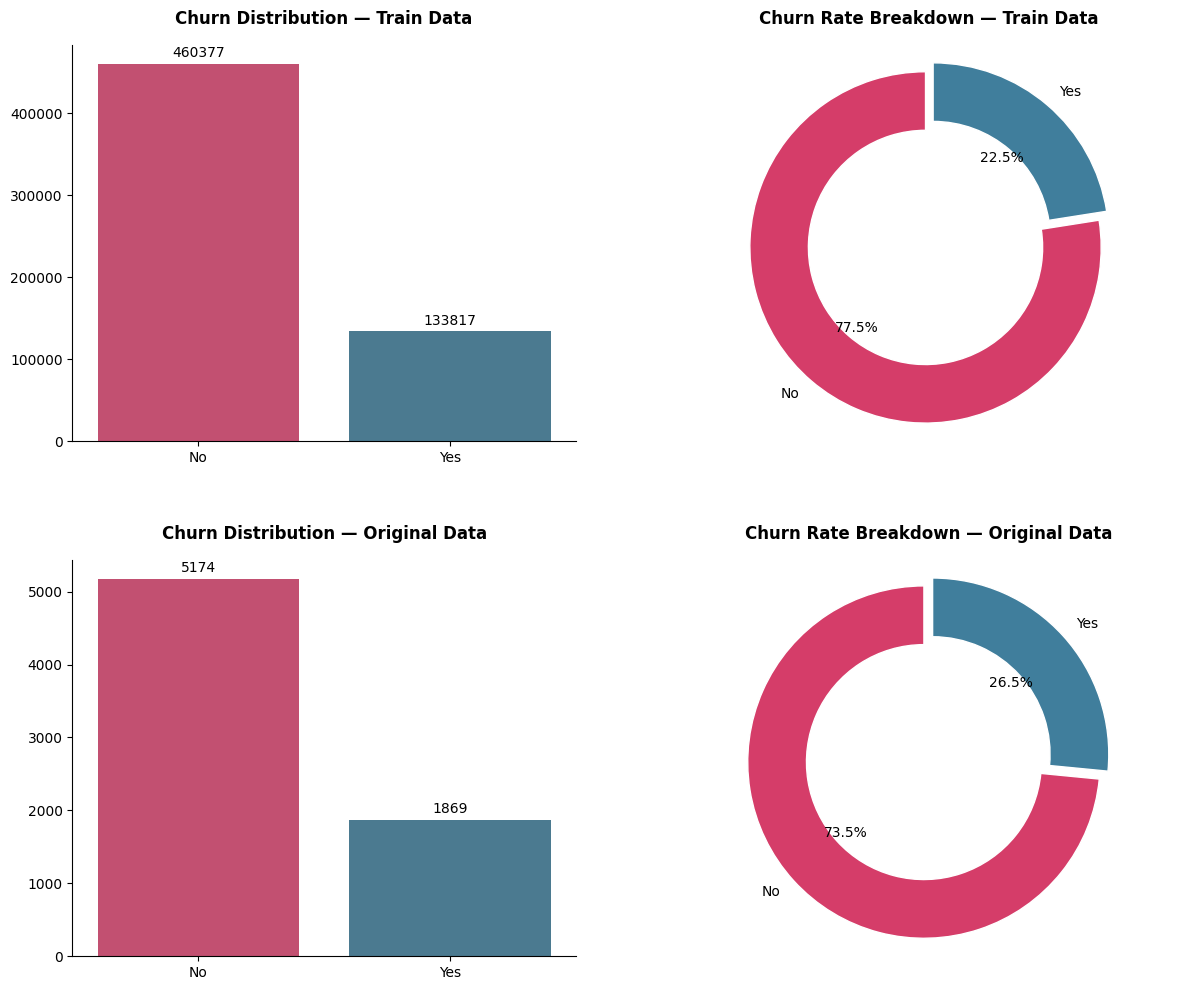

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
dataset_train = [("Train Data", df_train), ("Original Data", df_original)]

for i, (title, data) in enumerate(dataset_train):
    ax = axes[i, 0]

    # Vertical barplot
    sns.countplot(x=config.target_feature, data=data, ax=ax, palette=color(n_colors=2))
    ax.set_title(f"Churn Distribution — {title}", pad=15, weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No", "Yes"])
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # Add count labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x() + p.get_width() / 2
        ax.text(x, height + max(data[config.target_feature].value_counts()) * 0.01,
                f"{int(height)}",
                ha="center", va="bottom", fontsize=10, color="black")

    # Pie chart
    y_counts = data[config.target_feature].value_counts().sort_index()
    wedges, texts, autotexts = axes[i, 1].pie(
        y_counts,
        labels=["No", "Yes"],
        autopct="%1.1f%%",
        startangle=90,
        colors=color(n_colors=2),
        wedgeprops=dict(width=0.4, edgecolor="w"),
        radius=1.2,
        explode=(0, 0.08)
    )

    for text in texts + autotexts:
        text.set_fontsize(10)

    centre_circle = plt.Circle((0, 0), 0.70, fc="white")
    axes[i, 1].add_artist(centre_circle)
    axes[i, 1].set_title(f"Churn Rate Breakdown — {title}", pad=15, weight="bold", fontsize=12)
    axes[i, 1].axis("equal")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.show()

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Target Distribution
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    margin-bottom: 20px;
    font-size: 15px;
">
<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Dataset</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">No (0)</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Yes (1)</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">Yes Rate</th>
</tr>
</thead>
<tbody>
<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Train</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">460,377</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">133,817</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>22.5%</b></td>
</tr>
<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Original</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">5,174</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;">1,869</td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:right;"><b>26.5%</b></td>
</tr>
</tbody>
</table>

<ul style="line-height:1.8; padding-left:20px;">
<li><b>Majority class:</b> "No" (customers who did <b>not</b> churn)</li>
<li><b>Minority class:</b> "Yes" (churned customers)</li>
<li>Both datasets exhibit a <b>highly imbalanced target variable</b>.</li>
</ul>

</div>

## Numerical Feature Distributions

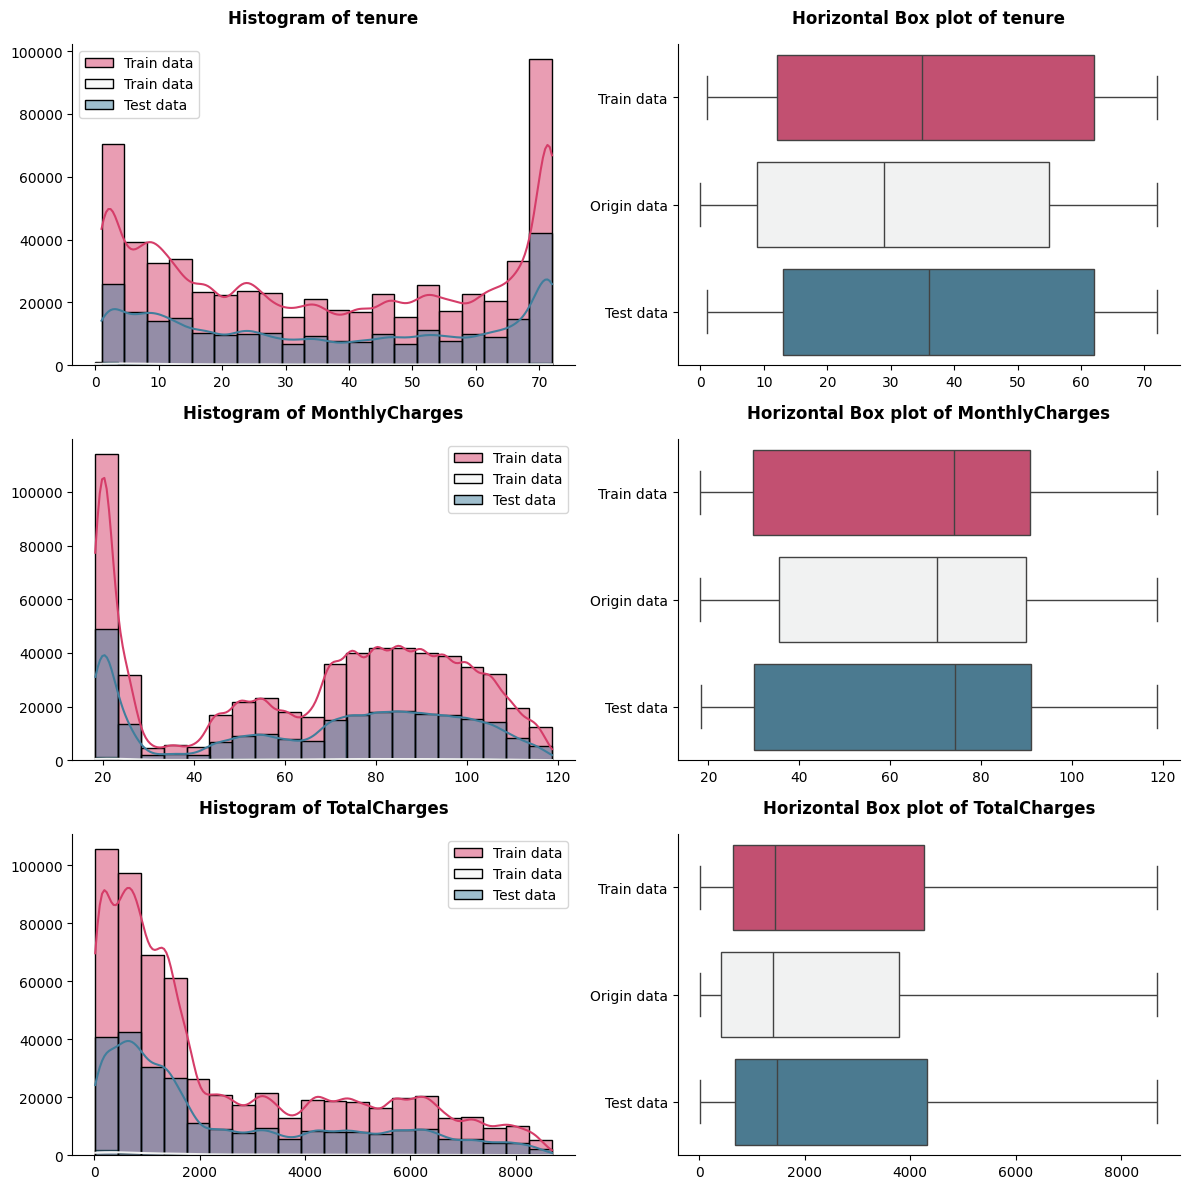

In [15]:
def plot_numerical_features(df_train: pd.DataFrame, df_test: pd.DataFrame, df_origin: pd.DataFrame, num_features: List[str]):
    """
    Plot histogram and boxplot for each numerical feature.

    - Histogram shows distribution and skewness.
    - Boxplot highlights median and potential outliers.
    """

    # Generate color palette for 3 datasets
    colors = color(n_colors=3)
    n = len(num_features)

    # Create subplot grid: each feature has 1 row, 2 columns (hist + boxplot)
    fig, ax = plt.subplots(n, 2, figsize=(12, n * 4))
    ax = np.array(ax).reshape(n, 2)

    for i, feature in enumerate(num_features):
        # Histogram + KDE Plot
        sns.histplot(data=df_train[feature], color=colors[0], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_origin[feature], color=colors[1], bins=20, kde=True, ax=ax[i, 0], label="Train data")
        sns.histplot(data=df_test[feature], color=colors[2], bins=20, kde=True, ax=ax[i, 0], label="Test data")
        # Format histogram
        ax[i, 0].set_title(f"Histogram of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 0].legend()
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 0])

        df_plot = pd.concat([
            pd.DataFrame({"Dataset": "Train data", feature: df_train[feature]}),
            pd.DataFrame({"Dataset": "Origin data", feature: df_origin[feature]}),
            pd.DataFrame({"Dataset": "Test data", feature: df_test[feature]})
        ]).reset_index(drop=True)

        # Prepare Data for Boxplot
        sns.boxplot(
            data=df_plot,
            x=feature,
            y="Dataset",
            palette=colors,
            orient="h",
            ax=ax[i, 1]
        )
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", pad=15, weight="bold", fontsize=12)
        ax[i, 1].set_xlabel("")
        ax[i, 1].set_ylabel("")
        sns.despine(left=False, bottom=False, ax=ax[i, 1])

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

plot_numerical_features(df_train = df_train, df_test = df_test, df_origin = df_original, num_features=num_features)

In [16]:
def check_skewness(data: pd.DataFrame, dataset_name: str, numerical_features: List[str] =num_features, 
                   sort=True, logger: logging.Logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature = check_skewness(df_train, "Heart Disease")
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-03-02 09:18:09 | INFO     | Skewness analysis for Heart Disease
2026-03-02 09:18:09 | INFO     | Total numerical features checked: 3
2026-03-02 09:18:09 | DEBUG    | ----------------------------------------------------------------------
2026-03-02 09:18:09 | DEBUG    | Feature                        | Skewness  | Remark
2026-03-02 09:18:09 | DEBUG    | ----------------------------------------------------------------------
2026-03-02 09:18:09 | DEBUG    | TotalCharges                   |   +0.9092 | Moderately skewed
2026-03-02 09:18:09 | DEBUG    | MonthlyCharges                 |   -0.2895 | Approximately symmetric
2026-03-02 09:18:09 | DEBUG    | tenure                         |   +0.0631 | Approximately symmetric
2026-03-02 09:18:09 | DEBUG    | ----------------------------------------------------------------------
2026-03-02 09:18:09 | INFO     | No highly skewed features detected.
2026-03-02 09:18:09 | INFO     | ---------------------------------------------------------------

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><b>Numerical distributions are highly consistent across Train, Test, and Original datasets</b>, indicating no noticeable data drift.</li>

<li><code>tenure</code> and <code>MonthlyCharges</code> are <b>approximately symmetric</b>, suggesting stable customer behavior patterns.</li>

<li><code>TotalCharges</code> shows <b>moderate right skewness</b>, reflecting customers with longer tenure accumulating higher total spending.</li>

<li>No highly skewed features were detected, meaning <b>no immediate transformation (log / Box-Cox) is required</b> before modeling.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Highlight:</b> The datasets exhibit <b>stable and well-aligned numerical distributions</b>, supporting reliable model training and strong generalization performance.
</div>

</div>

## Correlation Analysis of Numerical Features

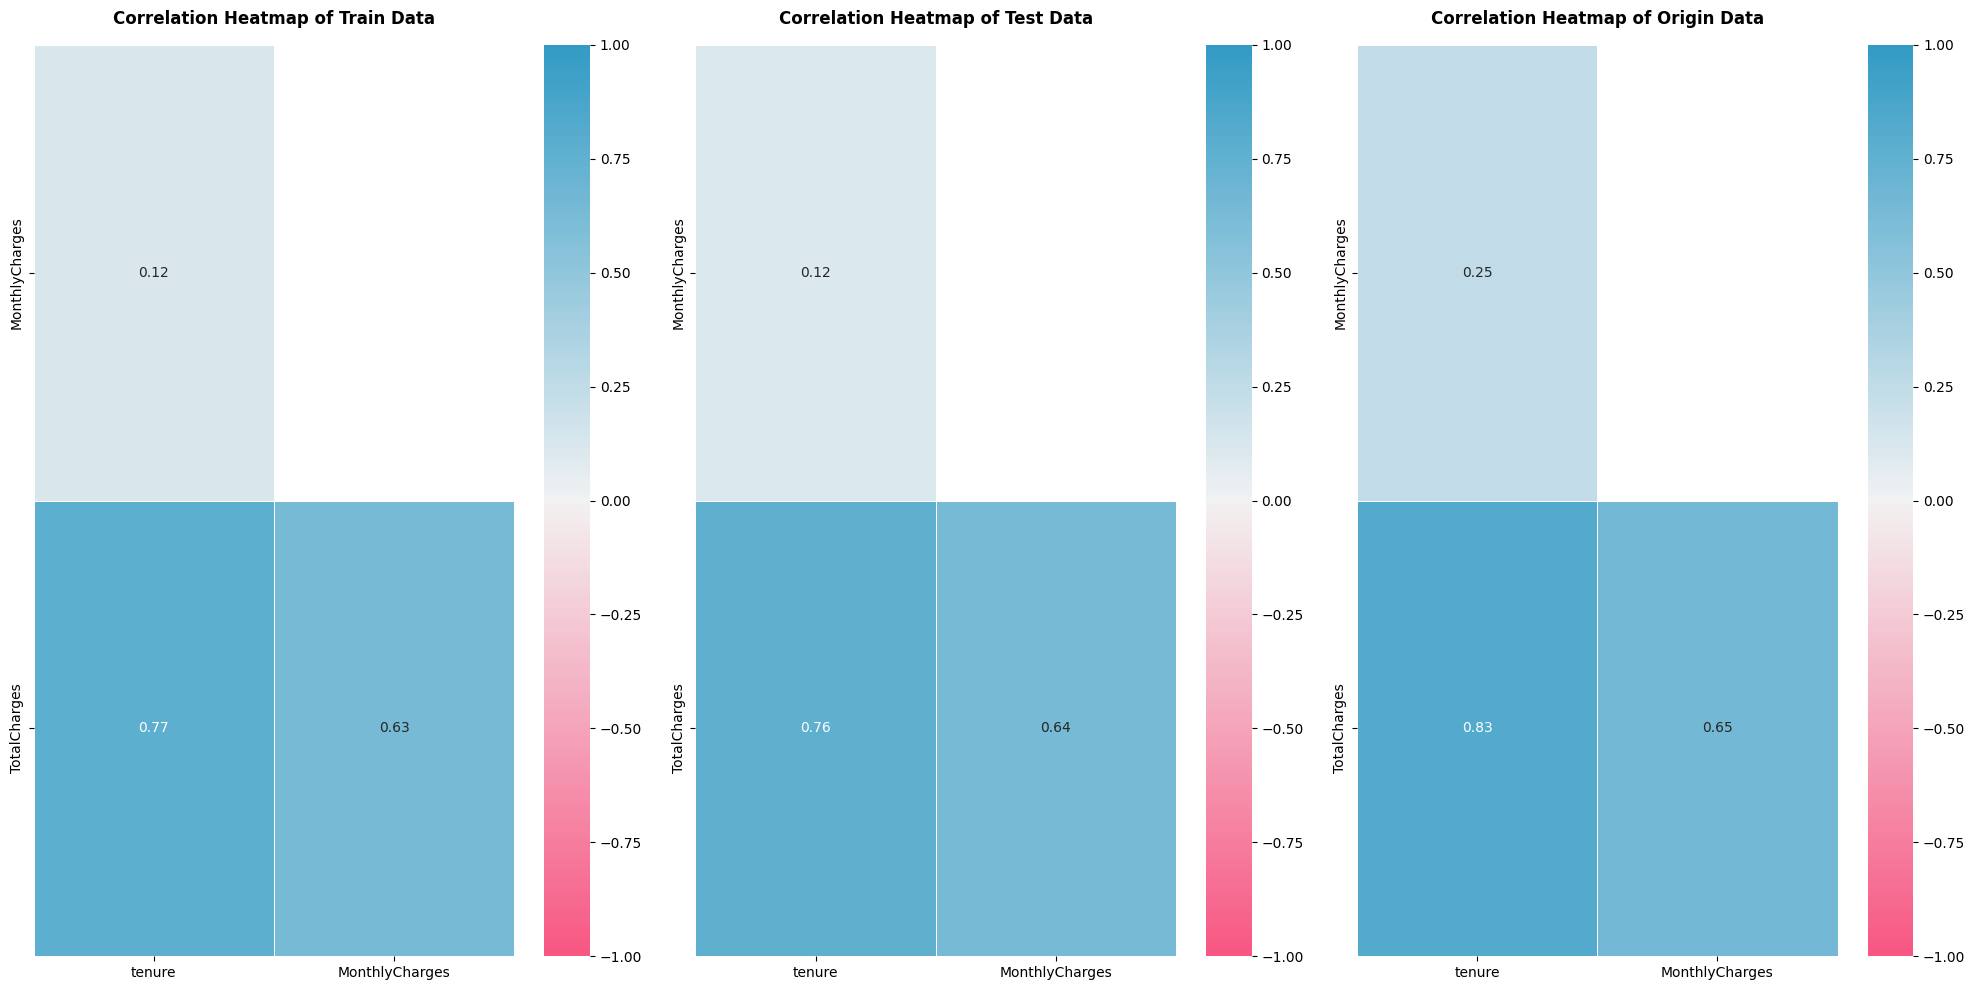

In [17]:
def plot_correlation(df_train, df_origin, df_test, origin_name="Origin Data", train_name="Train Data", test_name="Test Data"):
    """
    Plot side-by-side correlation heatmaps for training and test datasets.

    This function computes Pearson correlation matrices for numerical features
    in both training and test datasets, applies a triangular mask to avoid
    duplicated information, and visualizes the results using seaborn heatmaps.

    Parameters
    ----------
    df_train : pandas.DataFrame
        Training dataset (features only, target column should be removed).

    df_test : pandas.DataFrame
        Test dataset (features only).

    train_name : str, default="Train Data"
        Title name for the training heatmap.

    test_name : str, default="Test Data"
        Title name for the test heatmap.

    Returns
    -------
    None
        Displays correlation heatmaps for train and test datasets.
    """

    corr_train = df_train.corr(numeric_only=True)
    corr_origin = df_origin.corr(numeric_only=True)
    corr_test = df_test.corr(numeric_only=True)

    mask_train = np.triu(np.ones_like(corr_train, dtype=bool))
    adjusted_mask_train = mask_train[1:, :-1]
    adjusted_cereal_corr_train = corr_train.iloc[1:, :-1]

    mask_origin = np.triu(np.ones_like(corr_origin, dtype=bool))
    adjusted_mask_origin = mask_origin[1:, :-1]
    adjusted_cereal_corr_origin = corr_origin.iloc[1:, :-1]

    mask_test = np.triu(np.ones_like(corr_test, dtype=bool))
    adjusted_mask_test = mask_test[1:, :-1]
    adjusted_cereal_corr_test = corr_test.iloc[1:, :-1]

    cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
    fig, ax = plt.subplots(1, 3, figsize=(20, 10))

    sns.heatmap(data=adjusted_cereal_corr_train, mask=adjusted_mask_train,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[0])
    ax[0].set_title(f"Correlation Heatmap of {train_name}", fontsize=12, weight="bold", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_test, mask=adjusted_mask_test,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[1])
    ax[1].set_title(f"Correlation Heatmap of {test_name}", fontsize=12, weight="bold", pad=15)

    sns.heatmap(data=adjusted_cereal_corr_origin, mask=adjusted_mask_origin,
                annot=True, fmt=".2f", cmap=cmap,
                vmin=-1, vmax=1, linecolor="white", linewidths=0.5, ax=ax[2])
    ax[2].set_title(f"Correlation Heatmap of {origin_name}", fontsize=12, weight="bold", pad=15)

    plt.tight_layout()
    plt.show()

plot_correlation(df_train=df_train.drop(columns=config.target_feature),
                 df_origin=df_original.drop(columns=config.target_feature),
                 df_test=df_test)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Correlation Analysis (Numerical Features)
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>Pearson correlation was computed for numerical features: 
<code>tenure</code>, <code>MonthlyCharges</code>, and <code>TotalCharges</code> across 
<b>Train</b>, <b>Test</b>, and <b>Original</b> datasets.</li>

<li>Overall correlations are <b>low to moderate</b>, indicating limited multicollinearity.</li>

</ul>

<h3 style="margin-top:15px;">Notable Relationships</h3>

<ul style="line-height: 1.8; padding-left: 20px;">

<li><code>TotalCharges</code> vs <code>tenure</code>: 
<b>strong positive correlation (~0.76–0.83)</b> → longer tenure leads to higher accumulated charges.</li>

<li><code>TotalCharges</code> vs <code>MonthlyCharges</code>: 
<b>moderate positive correlation (~0.63–0.65)</b> → higher monthly fees contribute to higher total spending.</li>

<li><code>MonthlyCharges</code> vs <code>tenure</code>: 
<b>very weak correlation (~0.12–0.25)</b> → monthly pricing is largely independent of customer lifetime.</li>

</ul>

<h3>Train–Test Consistency</h3>

<ul style="line-height: 1.8; padding-left: 20px;">
<li>Correlation structures are <b>highly consistent across datasets</b>.</li>
<li>No structural shifts or relationship drift observed.</li>
</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Modeling Implications:</b>
<ul style="margin-top:8px; padding-left:18px; line-height:1.7;">
<li>Strong correlation between <code>TotalCharges</code> and <code>tenure</code> is <b>logically expected</b> and not problematic.</li>
<li>Moderate multicollinearity exists due to their cumulative relationship, but <b>no severe multicollinearity</b> is detected.</li>
<li>Numerical features can be safely retained for both <b>linear</b> and <b>tree-based models</b>.</li>
</ul>
</div>

</div>

## Categorical Feature Distributions

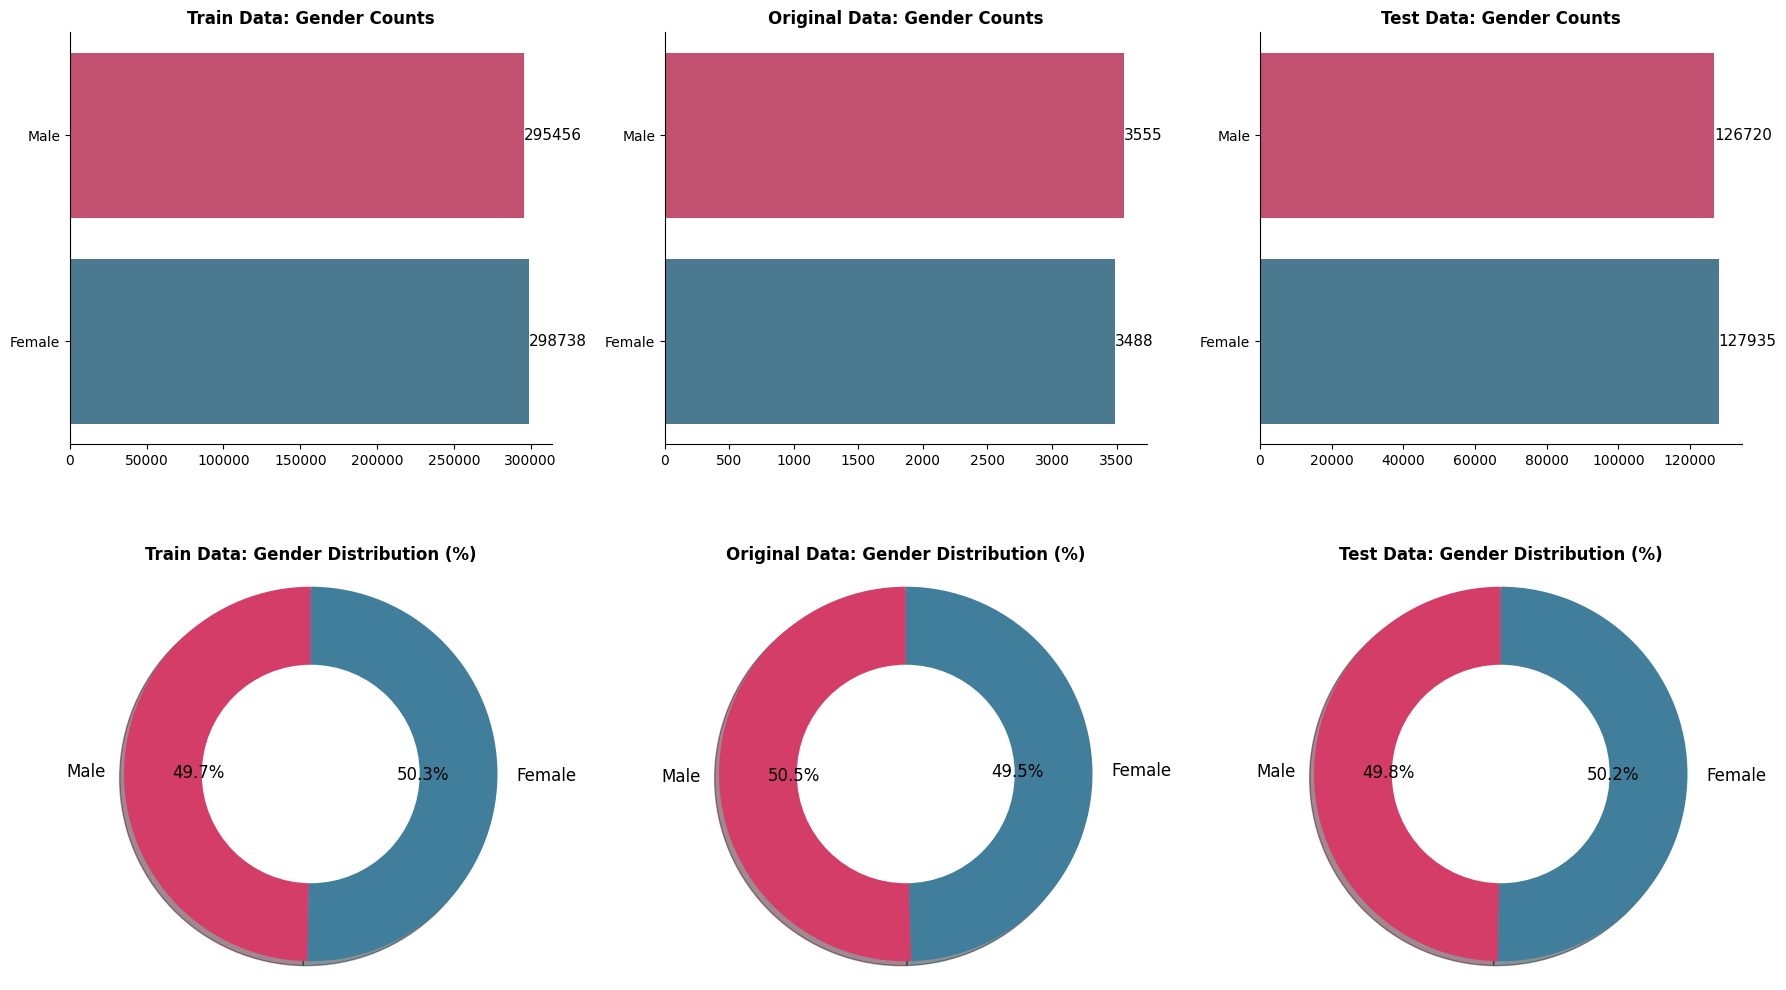

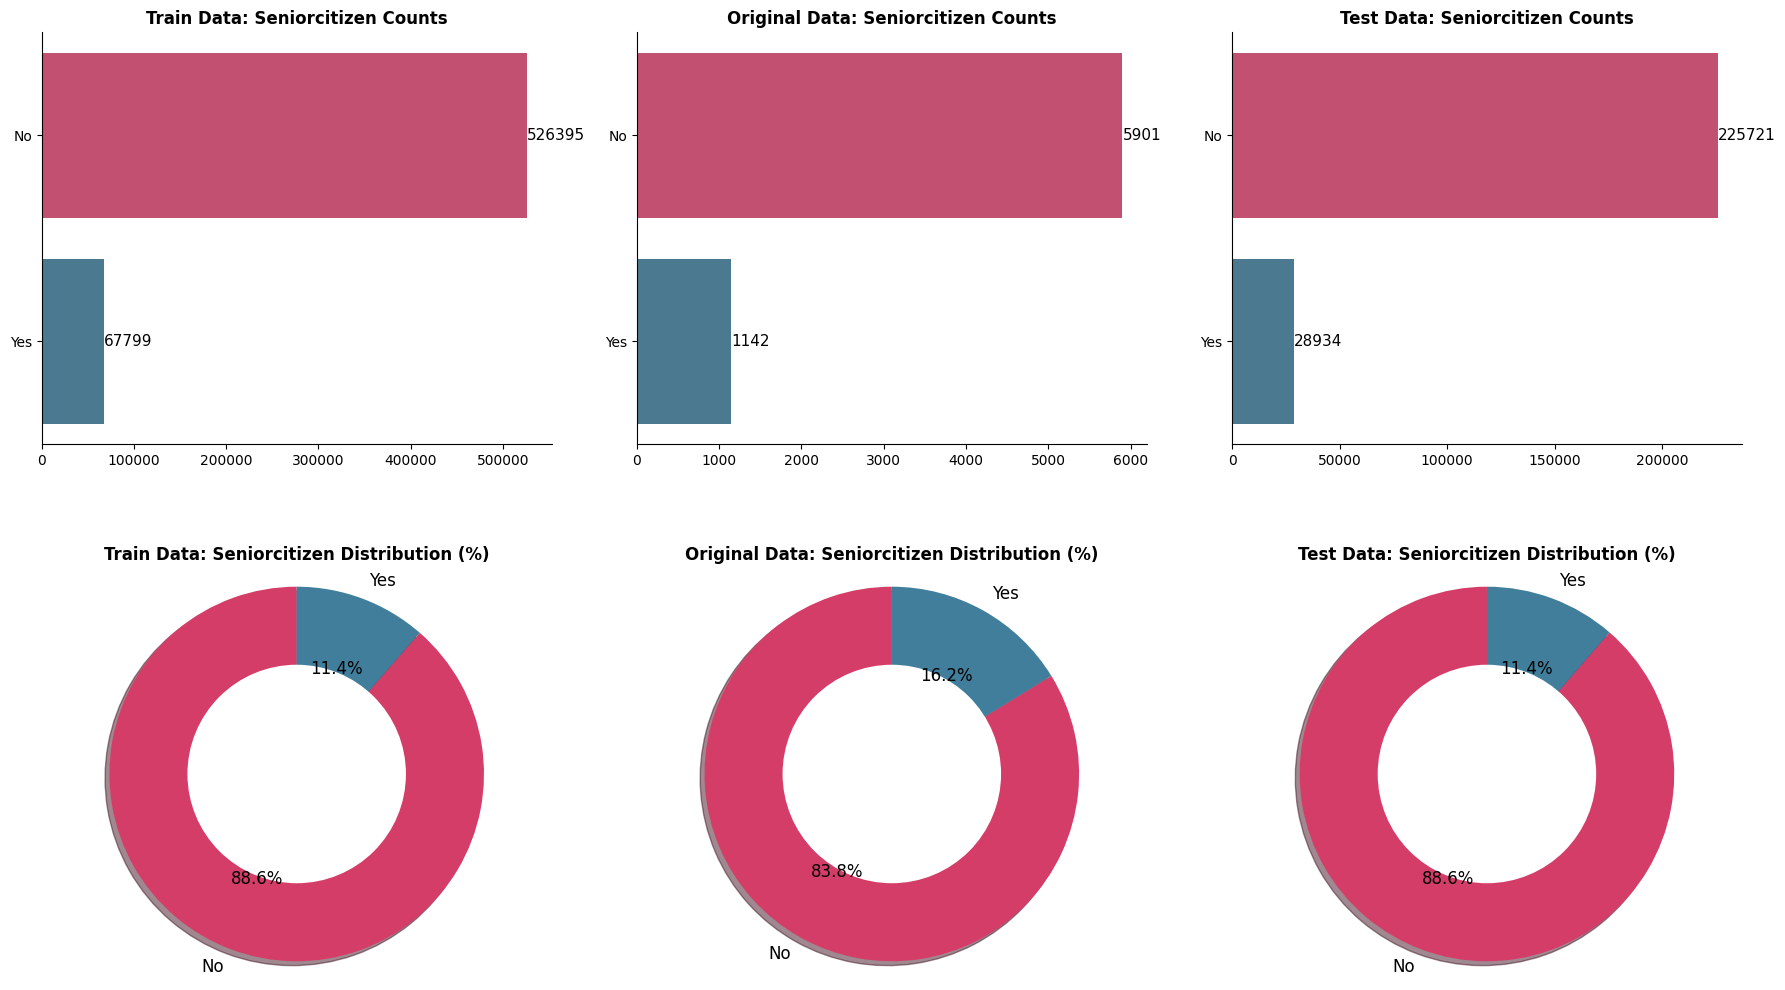

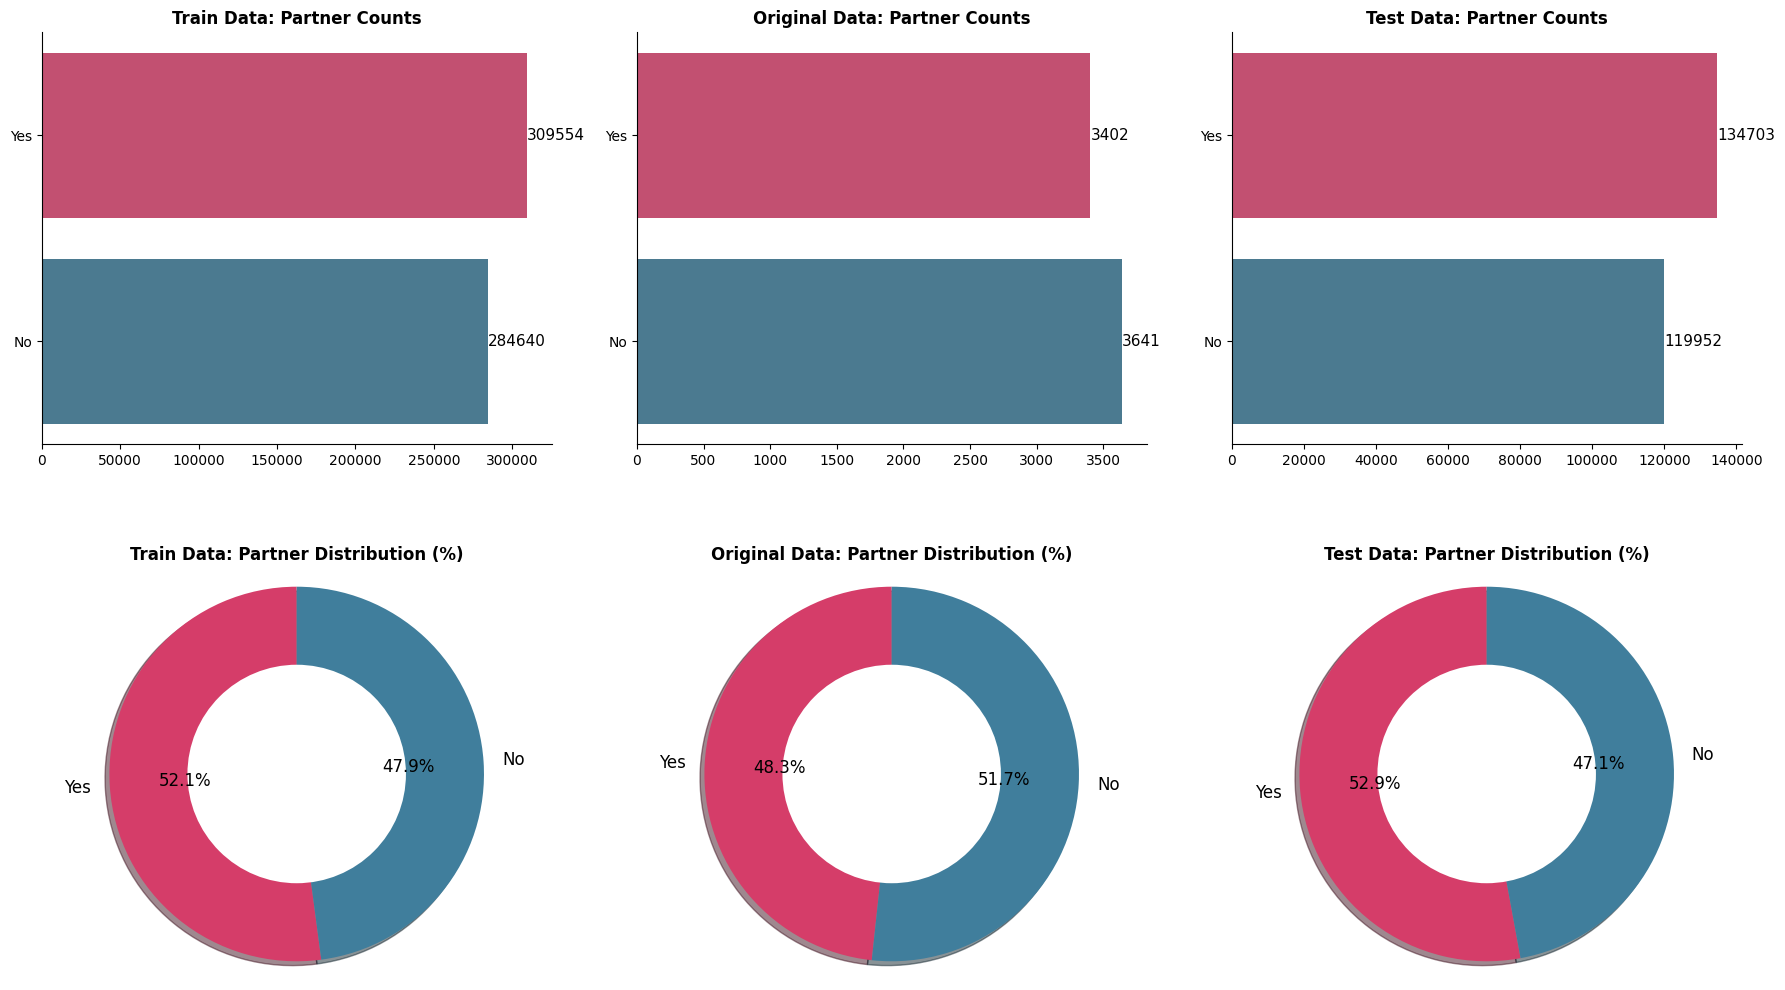

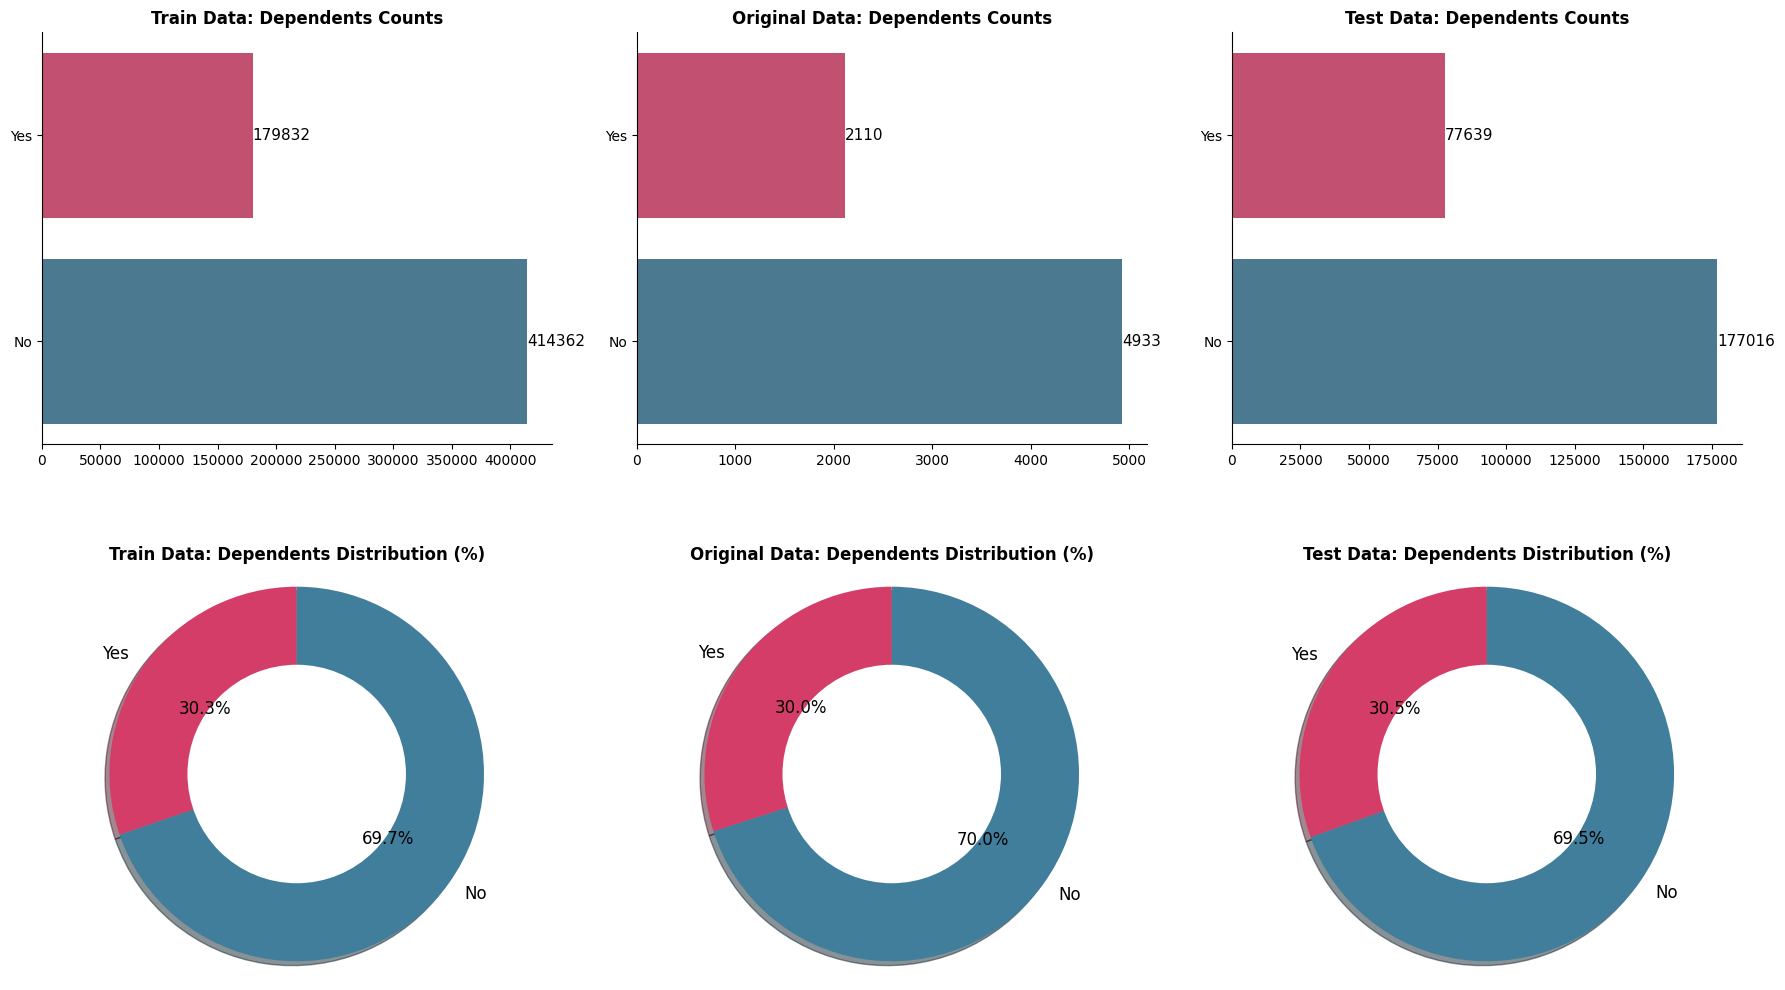

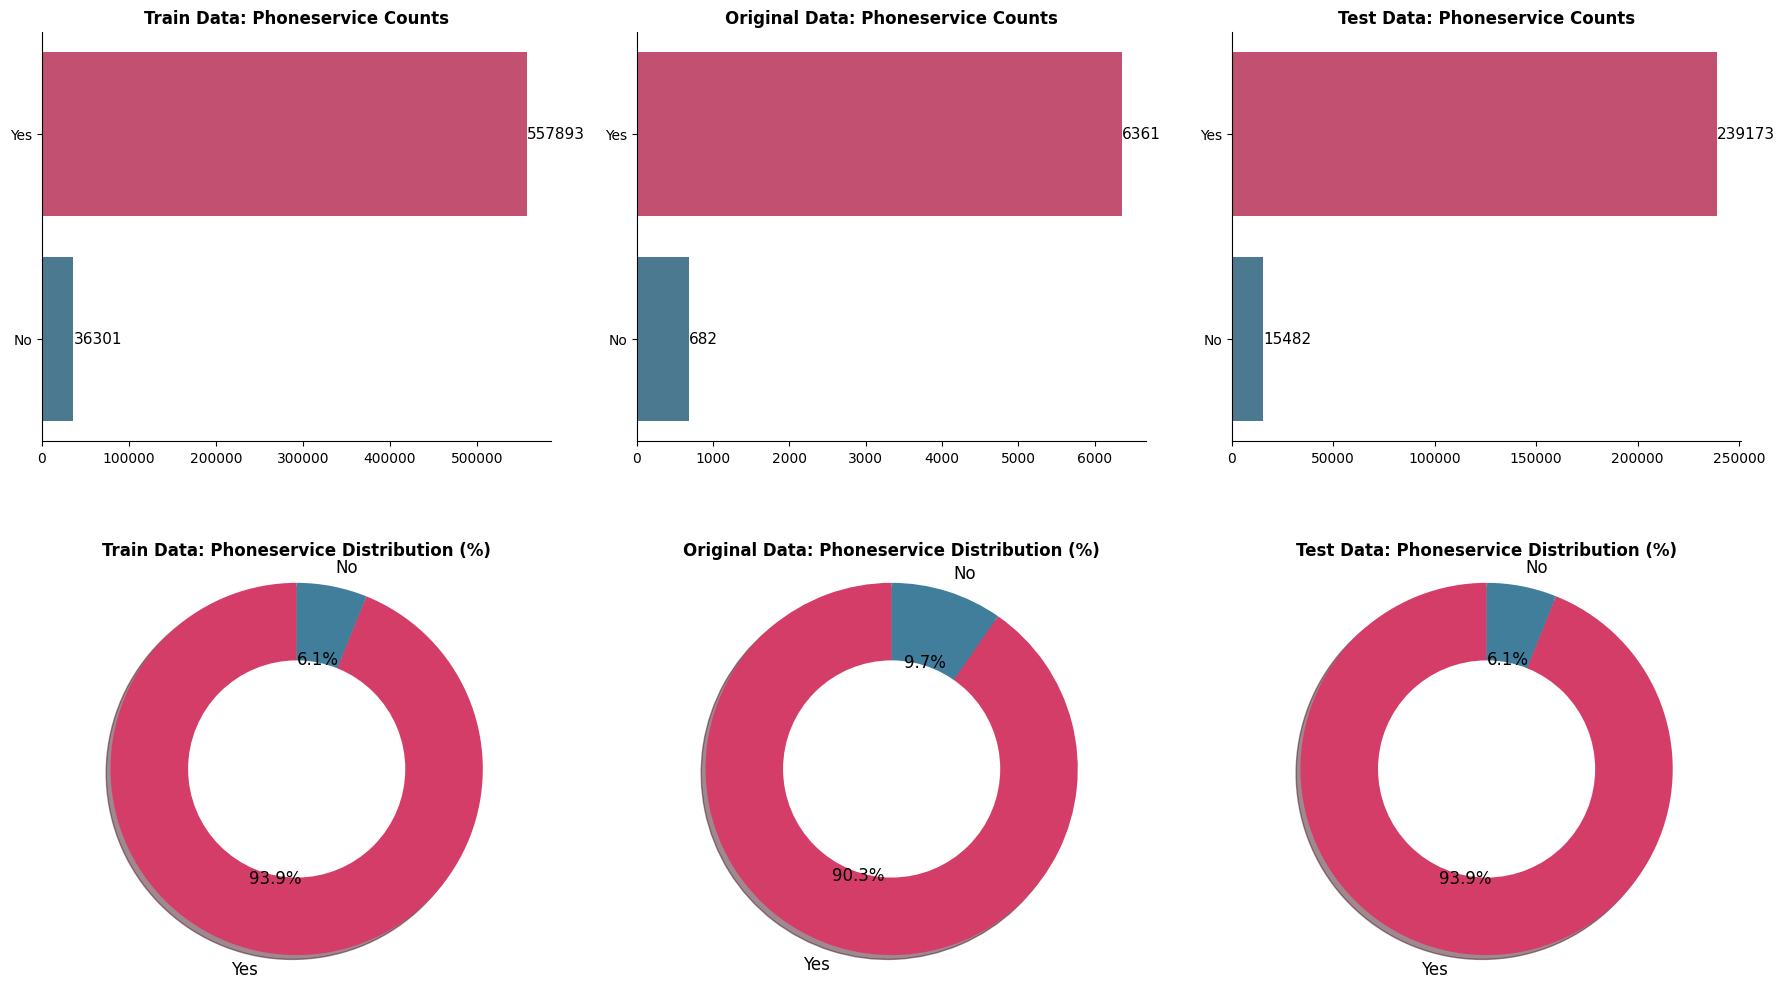

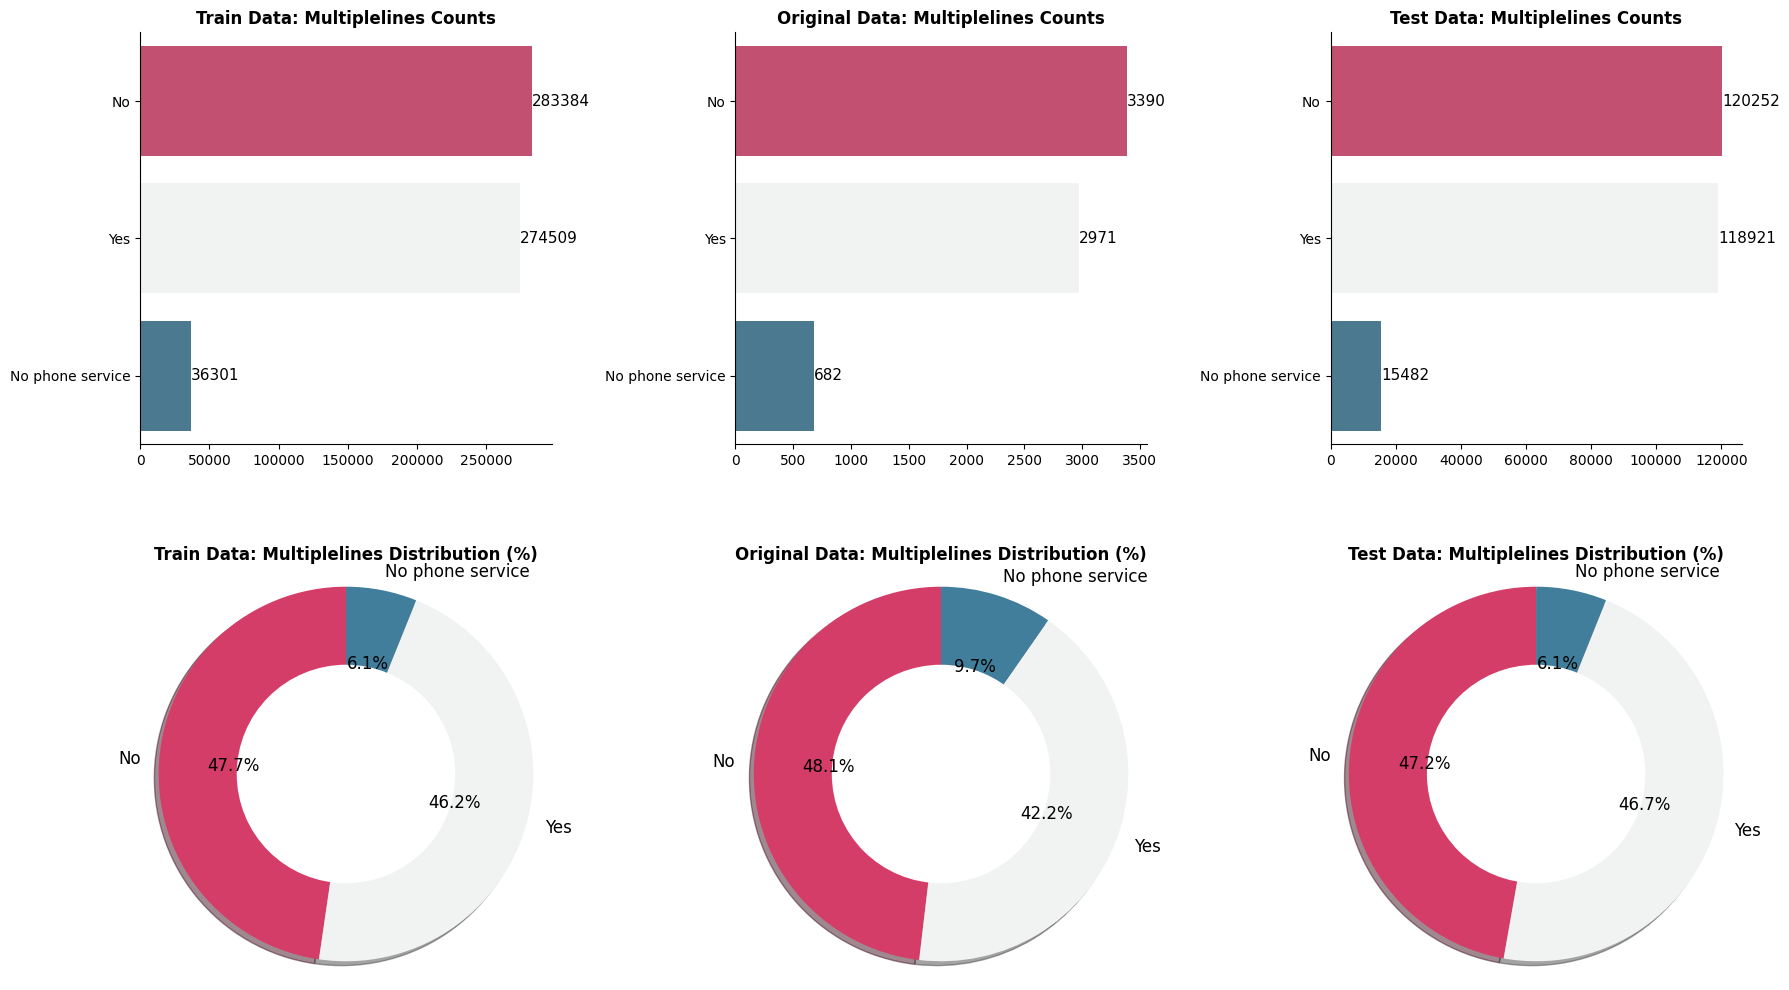

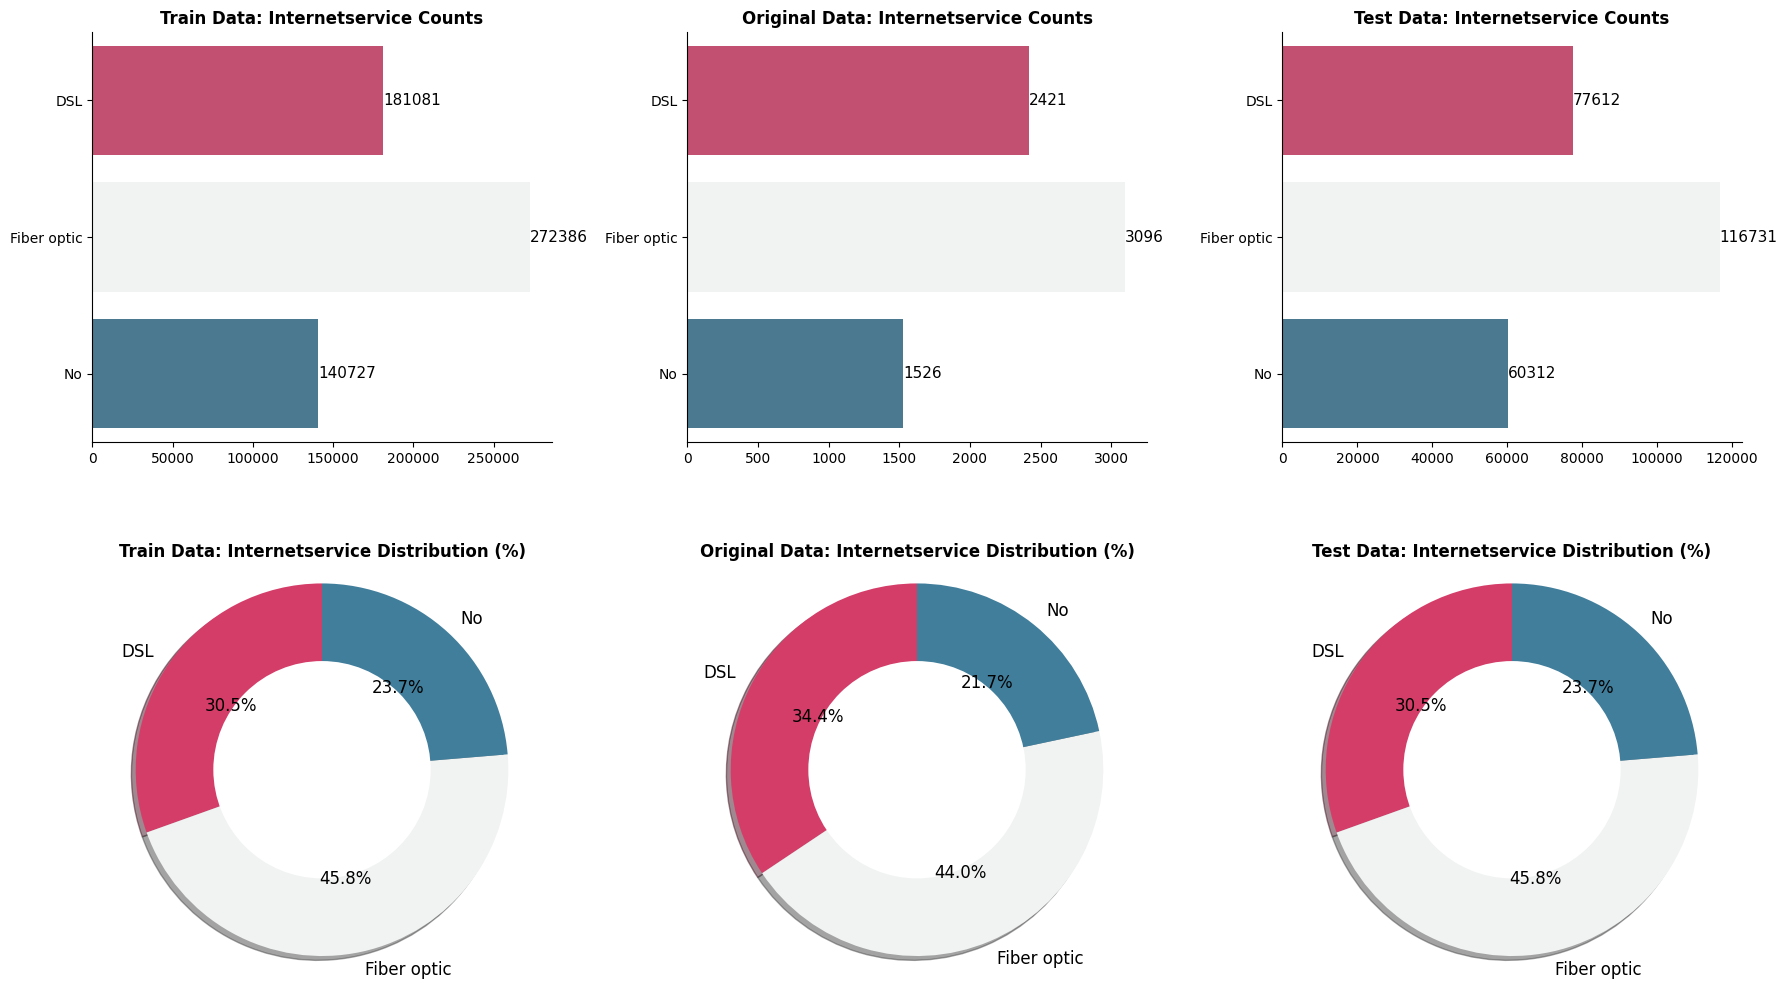

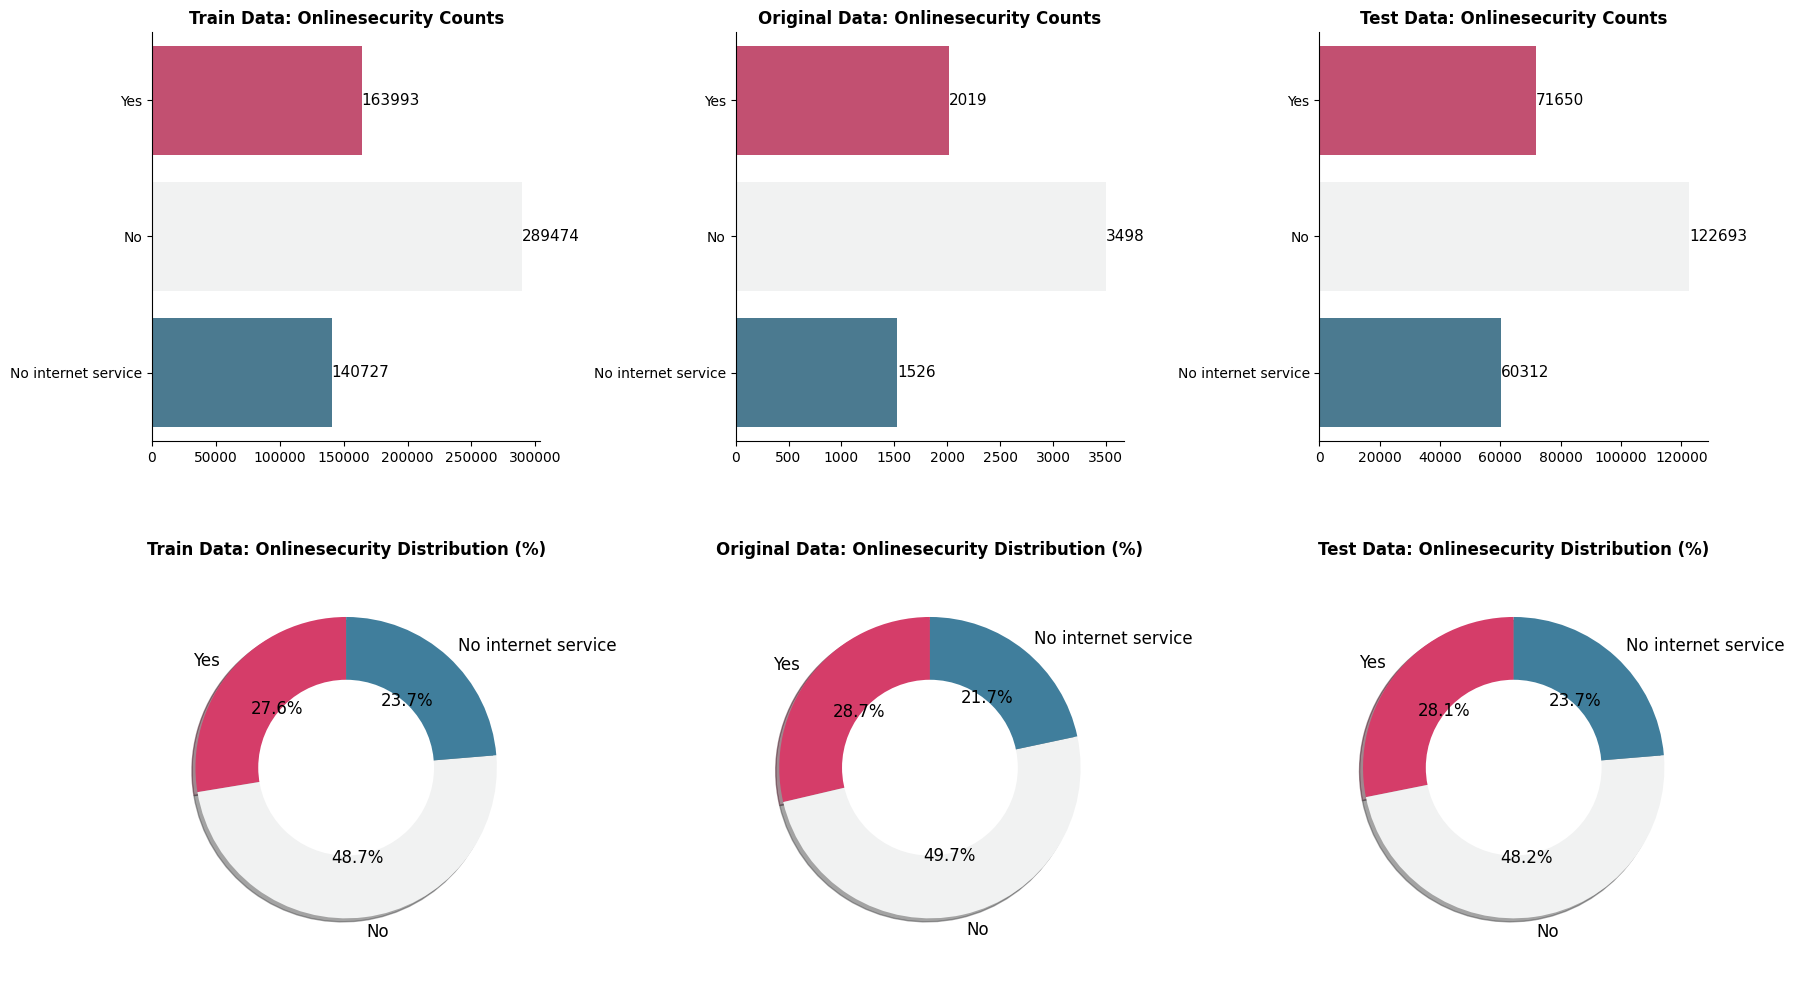

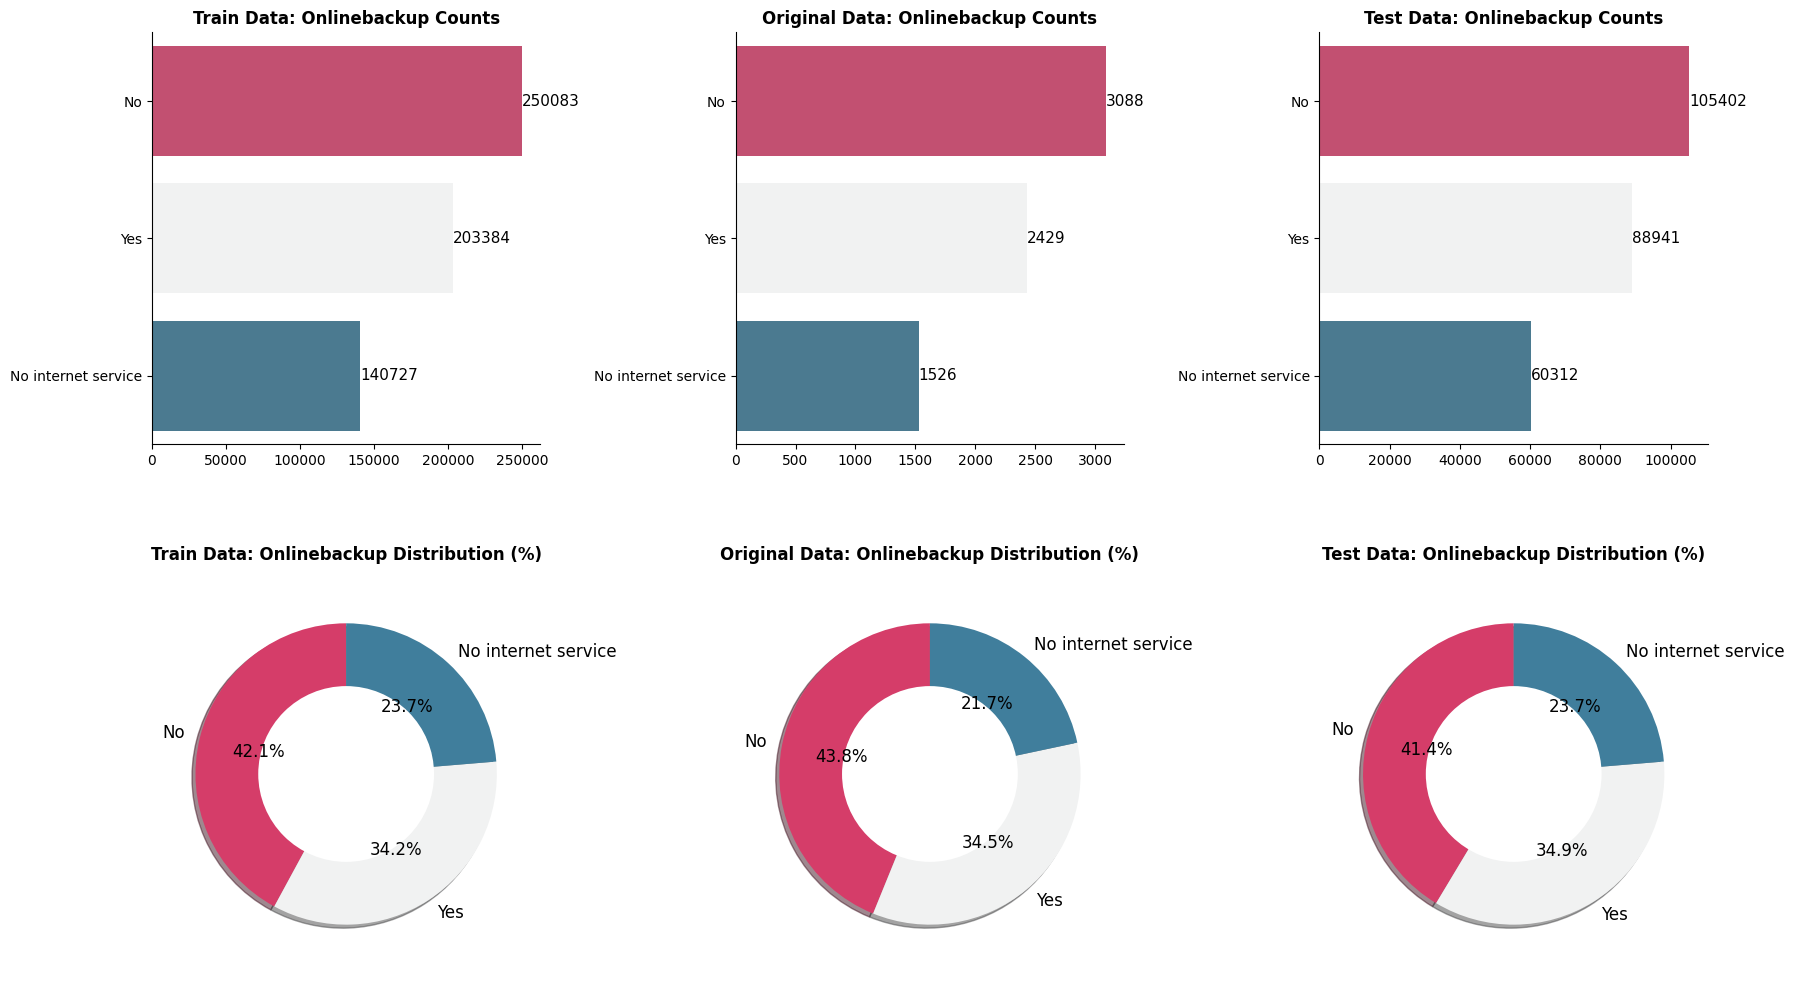

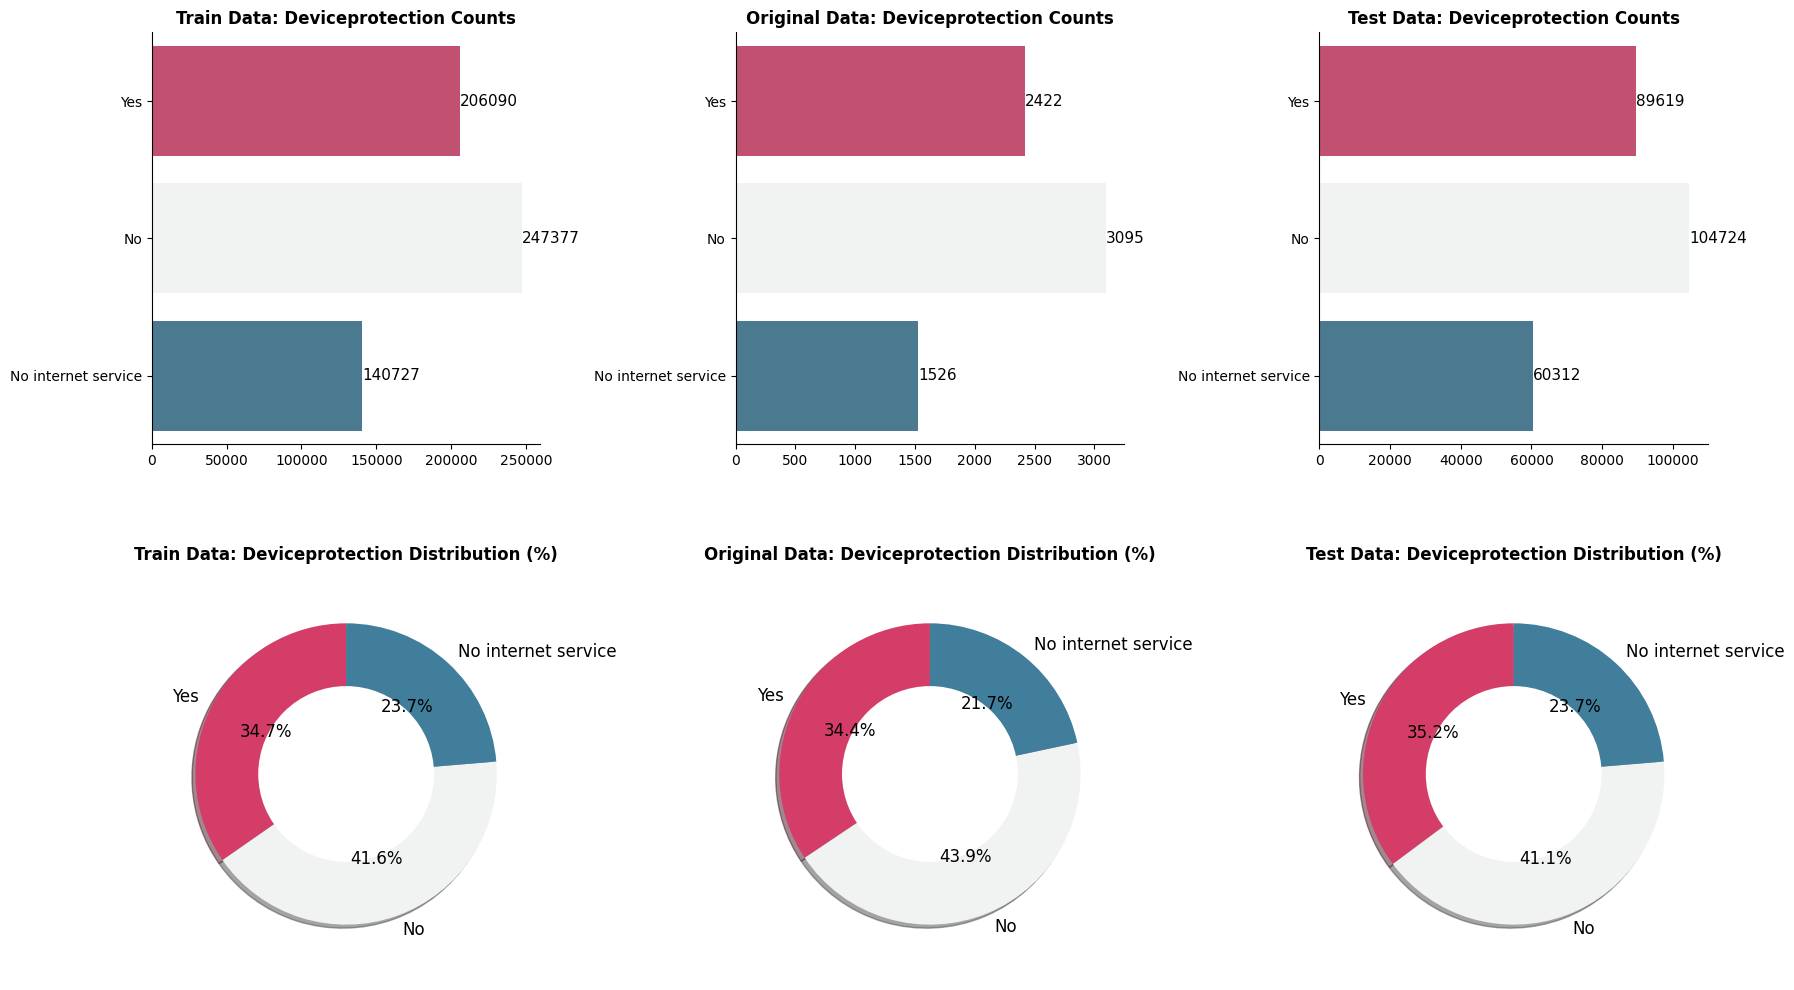

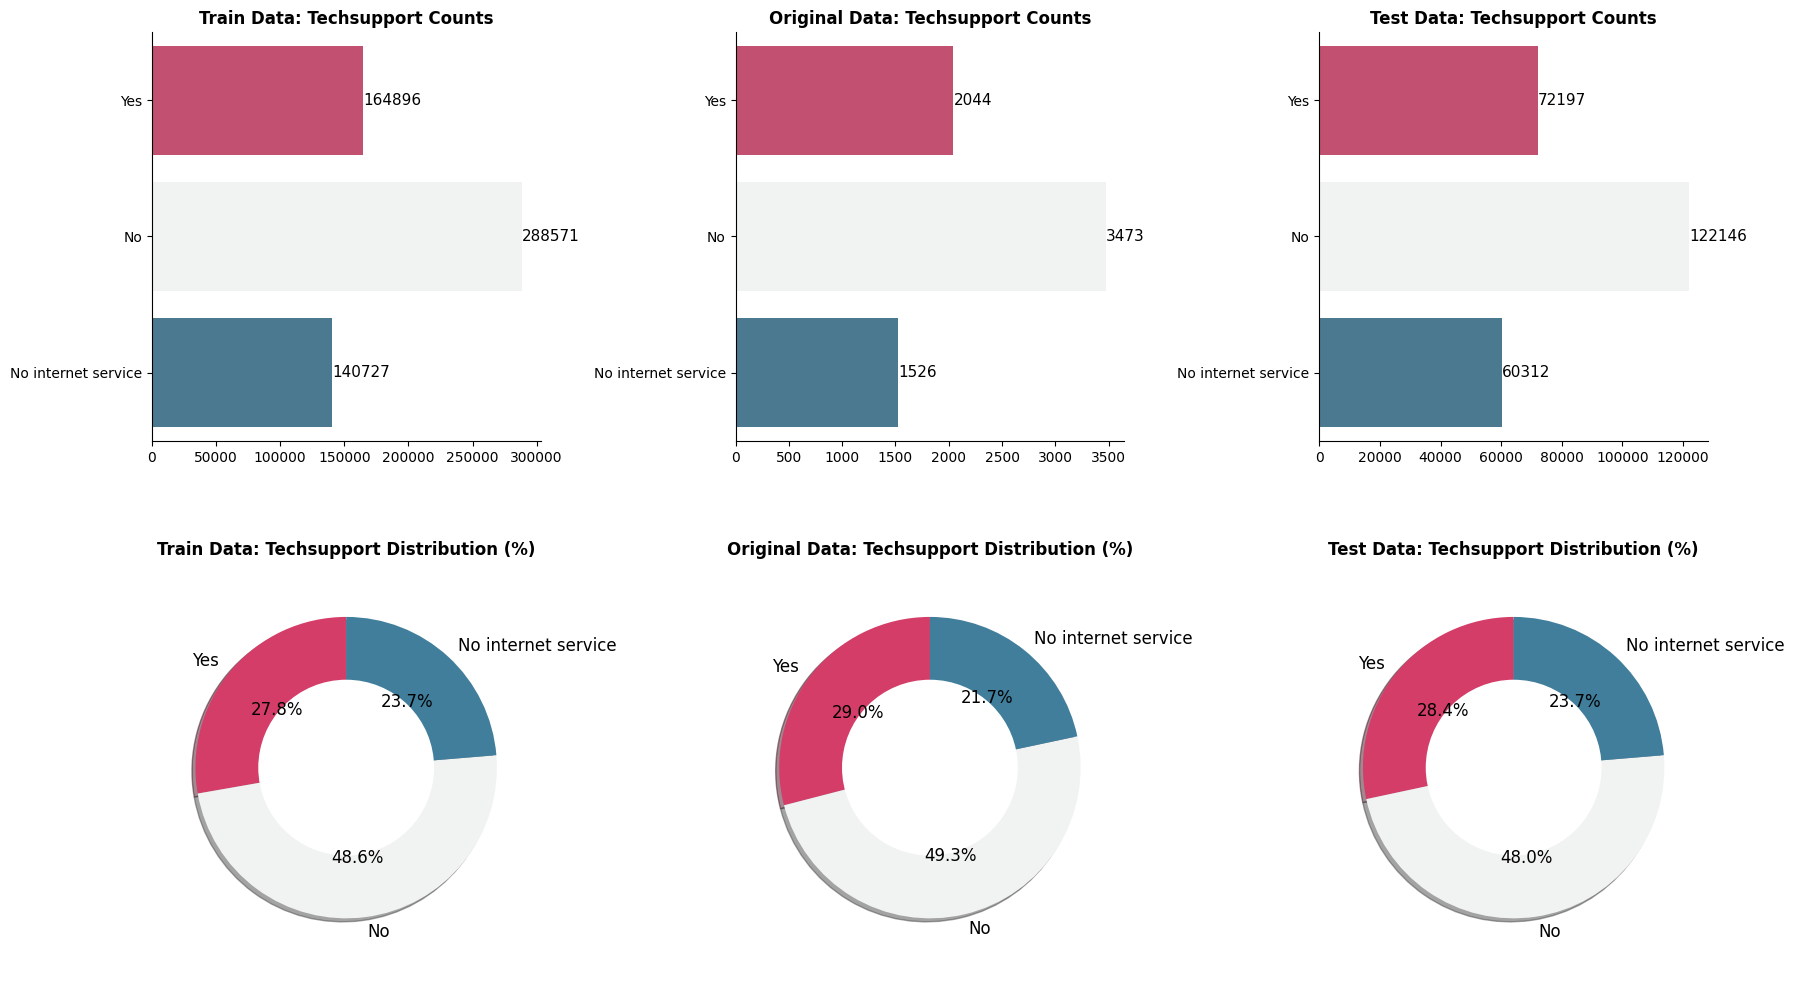

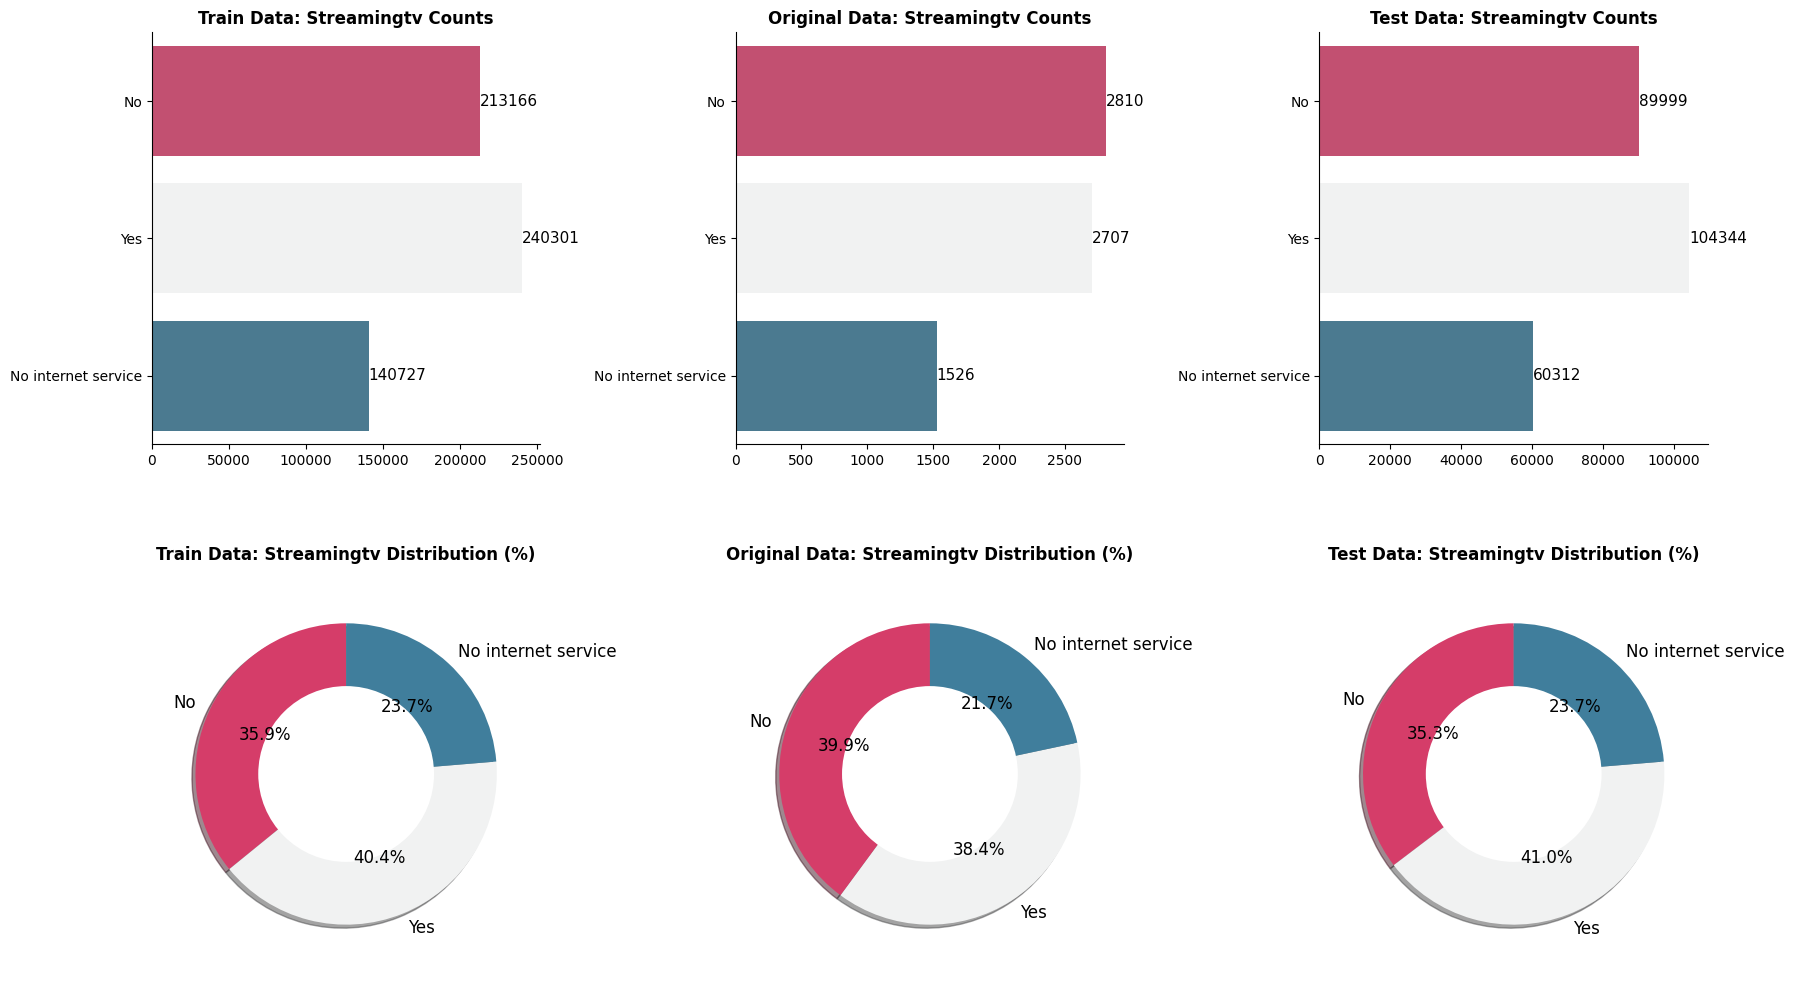

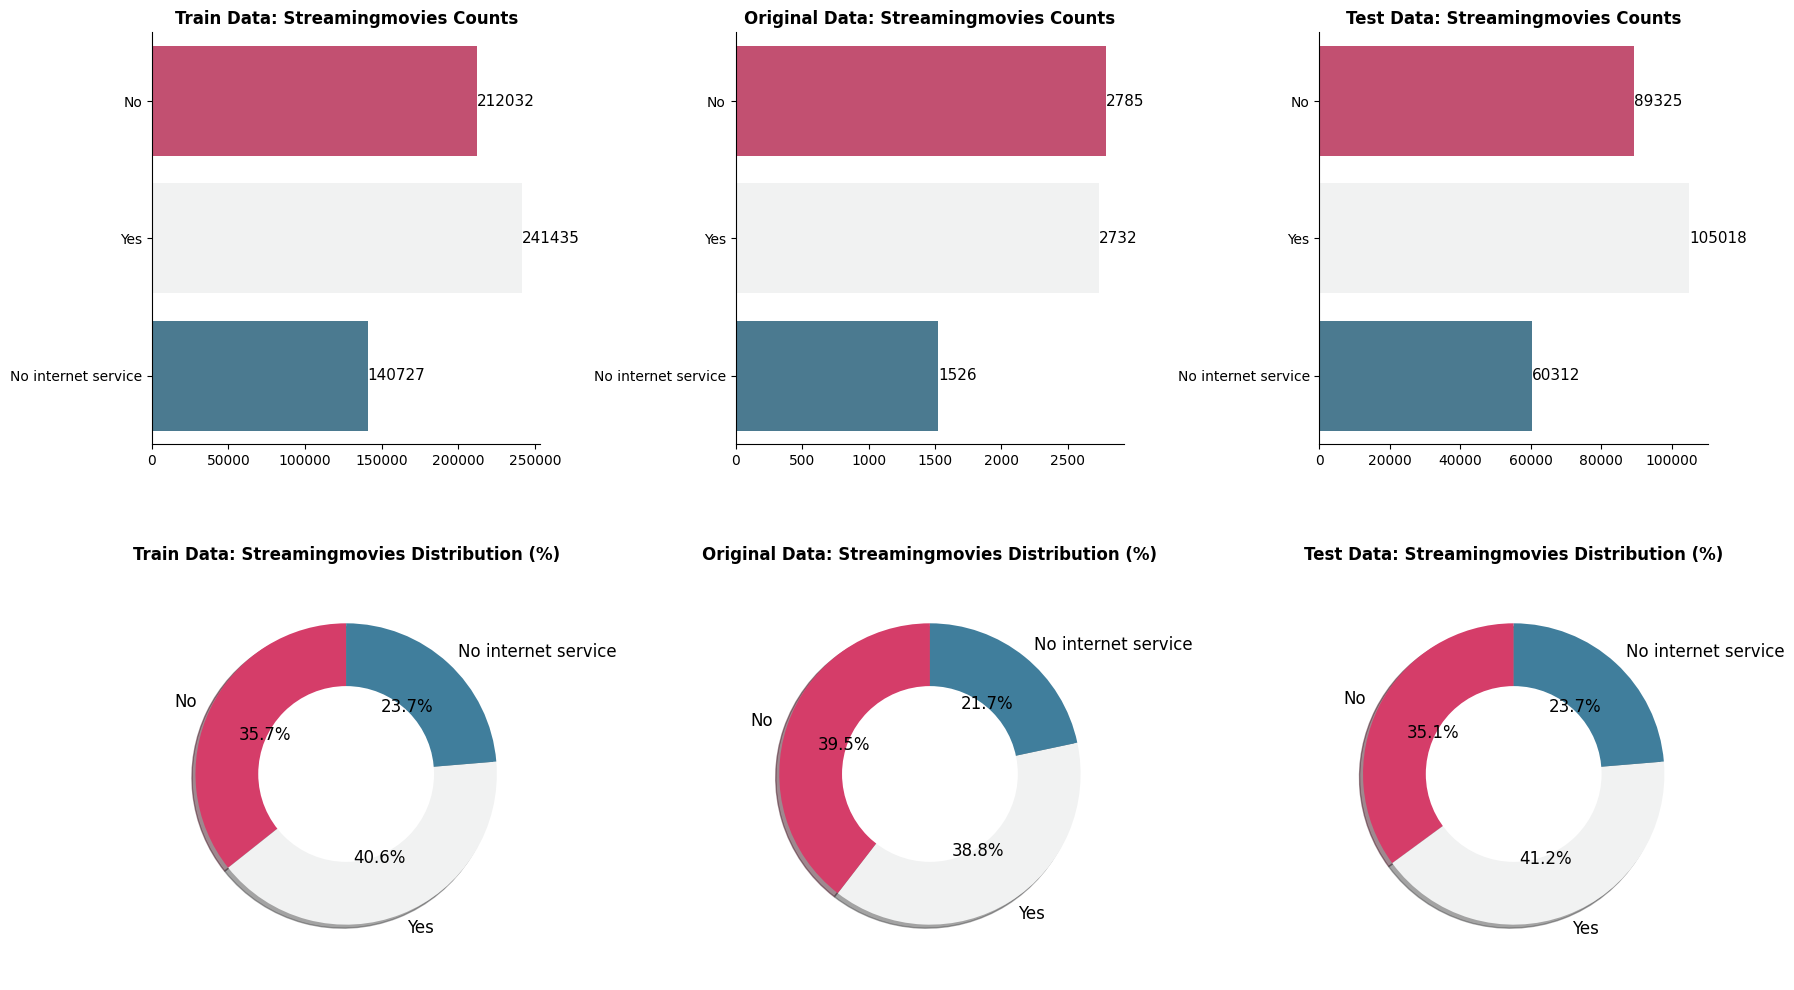

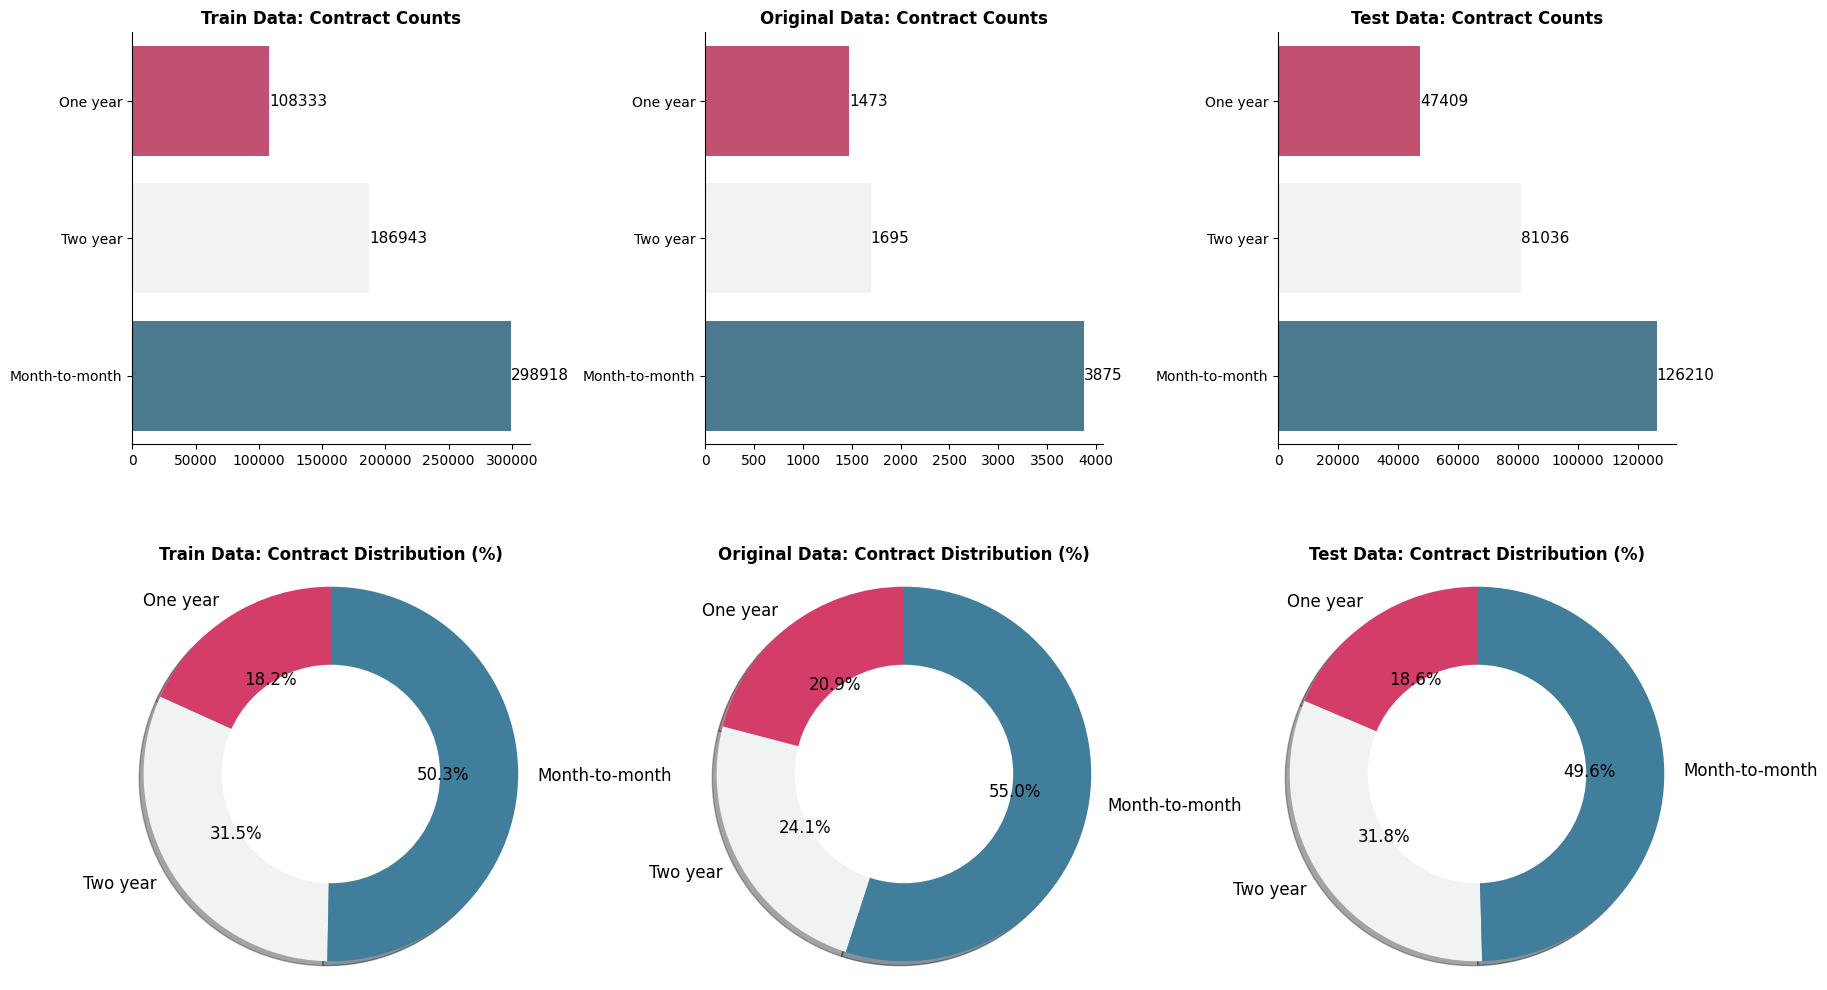

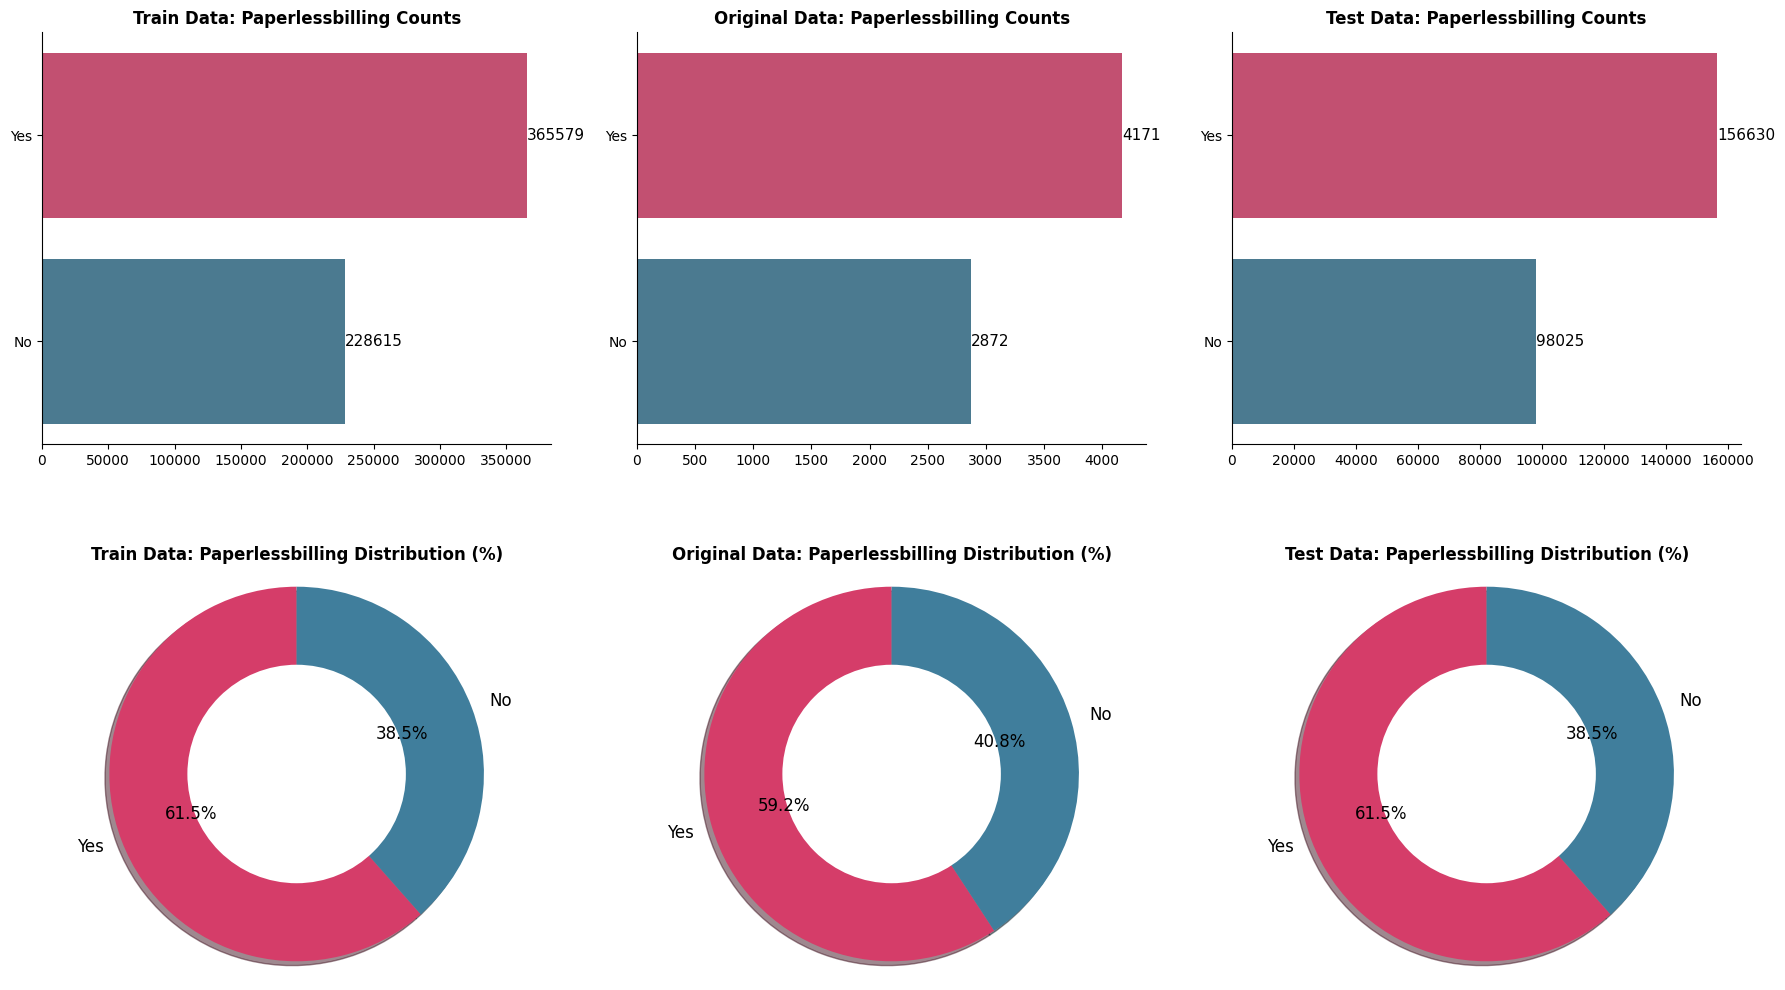

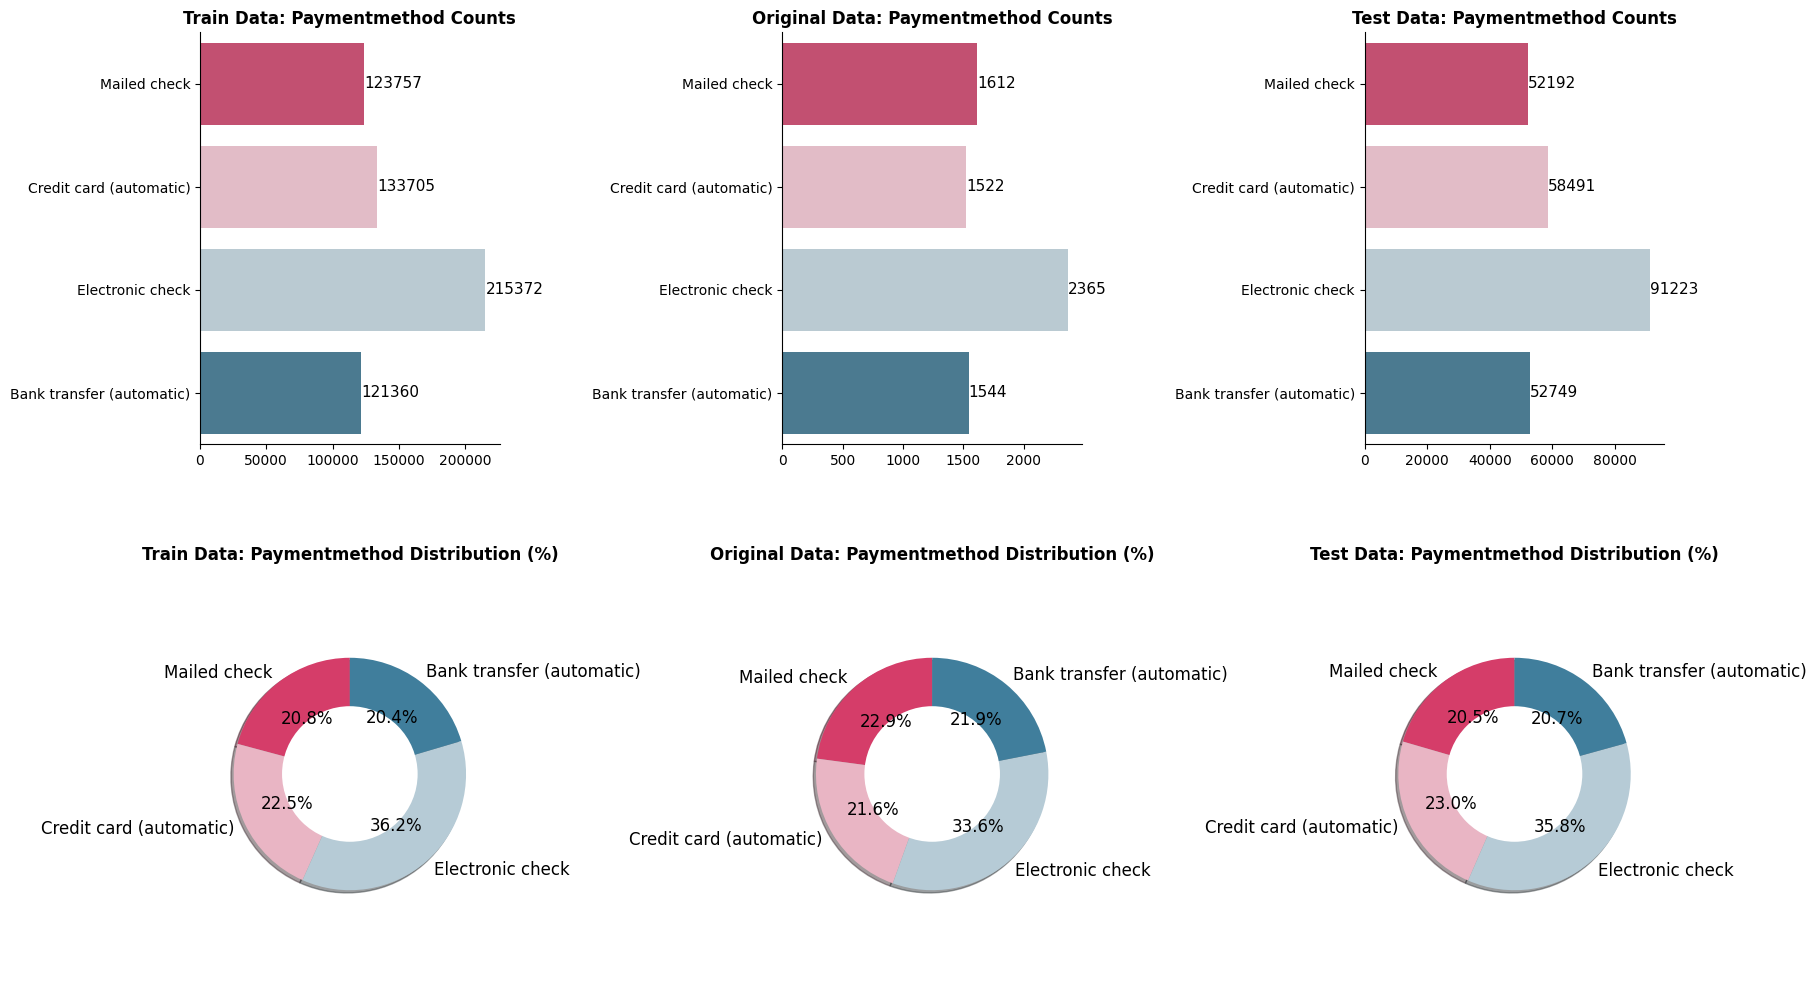

In [18]:
def plot_categorical_distribution_across_datasets(train_data: pd.DataFrame, original_data: pd.DataFrame, 
                                                  test_data: pd.DataFrame, feature: str):
    """
    Plot categorical feature distribution across Train, Original, and Test datasets.

    This function generates:
    1. Count plots (absolute frequency)
    2. Donut pie charts (percentage distribution)

    Parameters
    ----------
    train_data : pd.DataFrame
        Training dataset.
    original_data : pd.DataFrame
        Original/raw dataset.
    test_data : pd.DataFrame
        Test dataset.
    feature : str
        Categorical column name to analyze.

    Notes
    -----
    - Category order is fixed based on the Train dataset to ensure consistency.
    - Pie chart percentages are aligned with the same category order.
    - Useful for checking distribution drift across datasets.
    """

    # Define consistent color palette based on number of categories
    colors = color(n_colors=df_train[feature].nunique())

    # Dataset labels and list
    dataset_names = ["Train", "Original", "Test"]
    datasets = [train_data, original_data, test_data]

    # Fix category order using Train data to ensure consistent plotting
    order = df_train[feature].unique().tolist()

    # Create 2x3 subplot grid:
    # Row 1 → Count plots
    # Row 2 → Percentage donut charts
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))

    # Row 1: Count Plots
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        sns.countplot(y=feature, data=data, ax=ax[0, i], palette=colors, order=order)
        ax[0, i].set_title(f"{name} Data: {feature.title()} Counts", fontsize=12, weight="bold")
        ax[0, i].set_xlabel("")
        ax[0, i].set_ylabel("")
        
        for p in ax[0, i].patches:
            ax[0, i].annotate(f"{int(p.get_width())}", 
                               (p.get_width(), p.get_y() + p.get_height() / 2), 
                               ha="left", va="center", 
                               color="black", fontsize=11)
        ax[0, i].set_axisbelow(True)
        sns.despine(ax=ax[0, i])

    # Row 2: Donut Pie Charts
    for i, (data, name) in enumerate(zip(datasets, dataset_names)):
        counts = data[feature].value_counts().reindex(order)
        wedges, texts, autotexts = ax[1, i].pie(
            counts, labels=order, autopct="%1.1f%%", startangle=90, colors=colors,
            textprops={"fontsize": 12}, radius=1.2,  shadow=True)

        # Create donut hole
        centre_circle = plt.Circle((0, 0), 0.70, fc="white")
        ax[1, i].add_artist(centre_circle)
        ax[1, i].set_title(f"{name} Data: {feature.title()} Distribution (%)", fontsize=12, weight="bold")
        ax[1, i].axis("equal")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)  
    plt.show()

# Apply function to all categorical features
for feature in cat_features:
    plot_categorical_distribution_across_datasets(df_train, df_original, df_test, feature)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Overall Consistency in Categorical Feature Distributions
</div>

<ul style="line-height: 1.8; padding-left: 20px;">

<li>The <b>count plots and percentage distribution charts</b> of categorical variables across the 
<b>Train</b>, <b>Test</b>, and <b>Original</b> datasets demonstrate a <b>high degree of consistency</b>.</li>

<li>No noticeable signs of <b>distributional shift</b> or <b>sampling bias</b> are observed across datasets.</li>

</ul>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Conclusion:</b> The categorical feature distributions are well-aligned across datasets, reinforcing the reliability of downstream modeling and validation processes.
</div>

</div>

## Bivariate Analysis

,Churn,Count,Mean,Median,Std
0,No,460377,42.231313,46.000000,23.987158
1,Yes,133817,17.125343,10.000000,17.919396


2026-03-02 09:18:41 | INFO     | Checking normality of feature 'tenure' by groups of 'Churn'...
2026-03-02 09:18:41 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-02 09:18:41 | DEBUG    | Number of groups detected: 2
2026-03-02 09:18:41 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-02 09:18:41 | DEBUG    | [Churn=No] skew=-0.2447, kurtosis=-1.3729 → Approximately symmetric, Normal tails
2026-03-02 09:18:41 | DEBUG    | [Churn=Yes] skew=1.3774, kurtosis=1.0818 → Highly skewed, Normal tails
2026-03-02 09:18:41 | INFO     | Generating Q–Q plots for visual assessment...


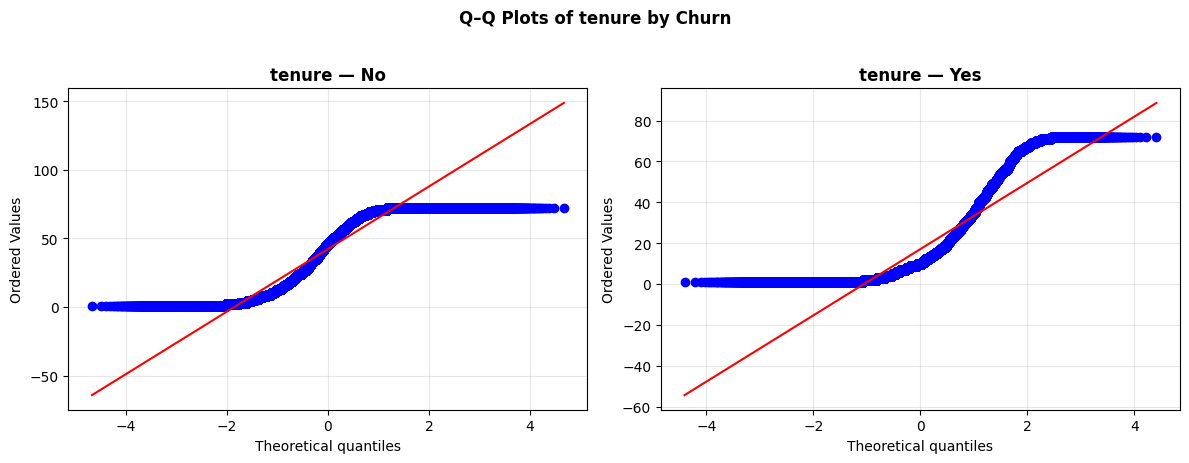

,Feature,Group,Skewness,Kurtosis,Remark
0,tenure,No,-0.2447,-1.3729,"Approximately symmetric, Normal tails"
1,tenure,Yes,1.3774,1.0818,"Highly skewed, Normal tails"


2026-03-02 09:18:43 | WARNING  | Normality assumption violated in at least one group.
2026-03-02 09:18:43 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-02 09:18:43 | INFO     | Running Mann–Whitney U Test: 'tenure' by 'Churn'...
2026-03-02 09:18:43 | DEBUG    | Number of groups detected: 2
2026-03-02 09:18:43 | INFO     | U statistic: 48895442535.0
2026-03-02 09:18:43 | INFO     | p-value    : 0.000000
2026-03-02 09:18:43 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-02 09:18:43 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-02 09:18:43 | INFO     | Effect size interpretation: Medium


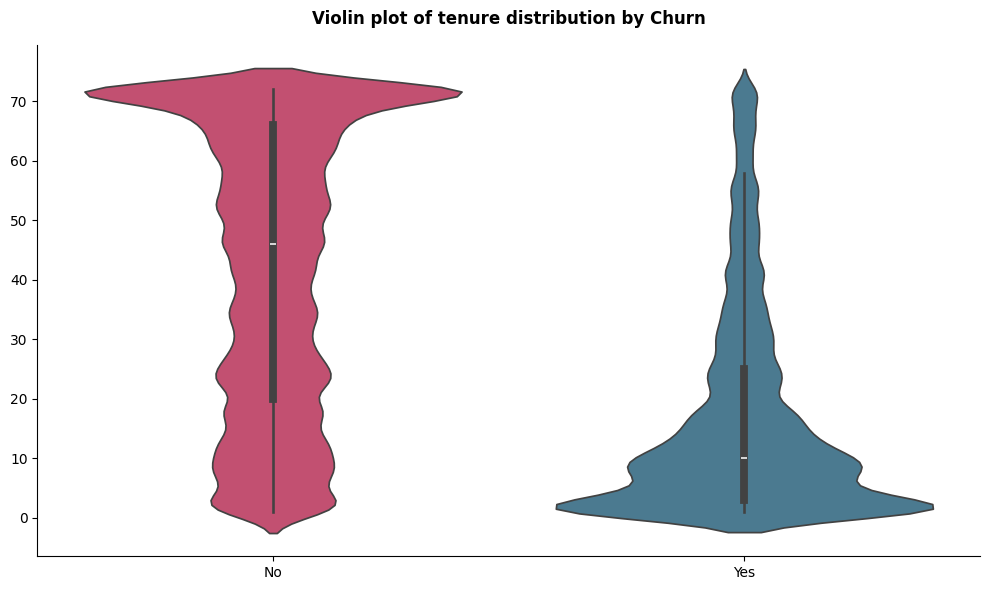

,Churn,Count,Mean,Median,Std
0,Yes,133817,81.597525,85.050000,19.490306
1,No,460377,61.293633,65.400000,32.287427


2026-03-02 09:18:46 | INFO     | Checking normality of feature 'MonthlyCharges' by groups of 'Churn'...
2026-03-02 09:18:46 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-02 09:18:46 | DEBUG    | Number of groups detected: 2
2026-03-02 09:18:46 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-02 09:18:46 | DEBUG    | [Churn=No] skew=-0.0189, kurtosis=-1.4100 → Approximately symmetric, Normal tails
2026-03-02 09:18:46 | DEBUG    | [Churn=Yes] skew=-1.1686, kurtosis=1.2030 → Highly skewed, Normal tails
2026-03-02 09:18:46 | INFO     | Generating Q–Q plots for visual assessment...


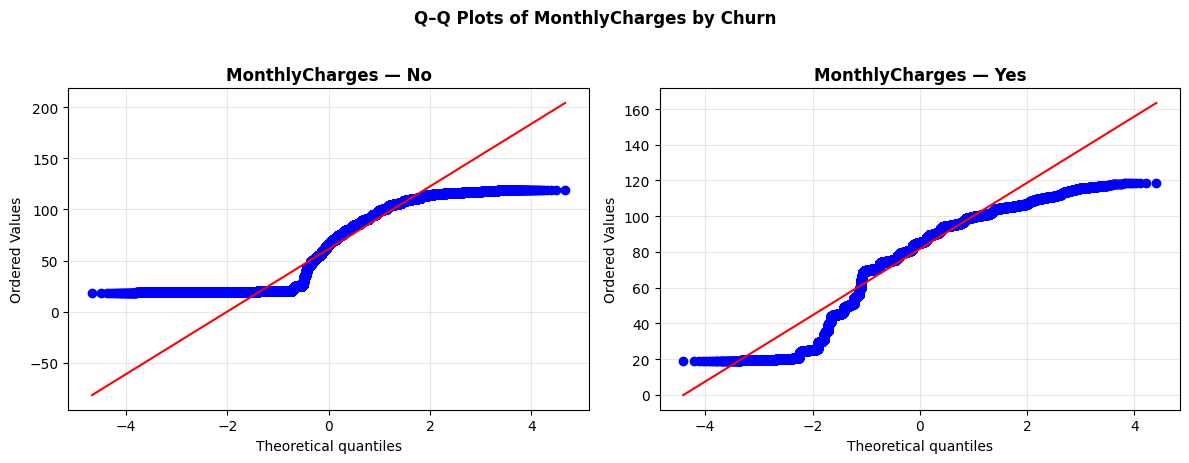

,Feature,Group,Skewness,Kurtosis,Remark
0,MonthlyCharges,No,-0.0189,-1.4100,"Approximately symmetric, Normal tails"
1,MonthlyCharges,Yes,-1.1686,1.2030,"Highly skewed, Normal tails"


2026-03-02 09:18:48 | WARNING  | Normality assumption violated in at least one group.
2026-03-02 09:18:48 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-02 09:18:48 | INFO     | Running Mann–Whitney U Test: 'MonthlyCharges' by 'Churn'...
2026-03-02 09:18:48 | DEBUG    | Number of groups detected: 2
2026-03-02 09:18:48 | INFO     | U statistic: 19775223354.0
2026-03-02 09:18:48 | INFO     | p-value    : 0.000000
2026-03-02 09:18:48 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-02 09:18:48 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-02 09:18:48 | INFO     | Effect size interpretation: Small


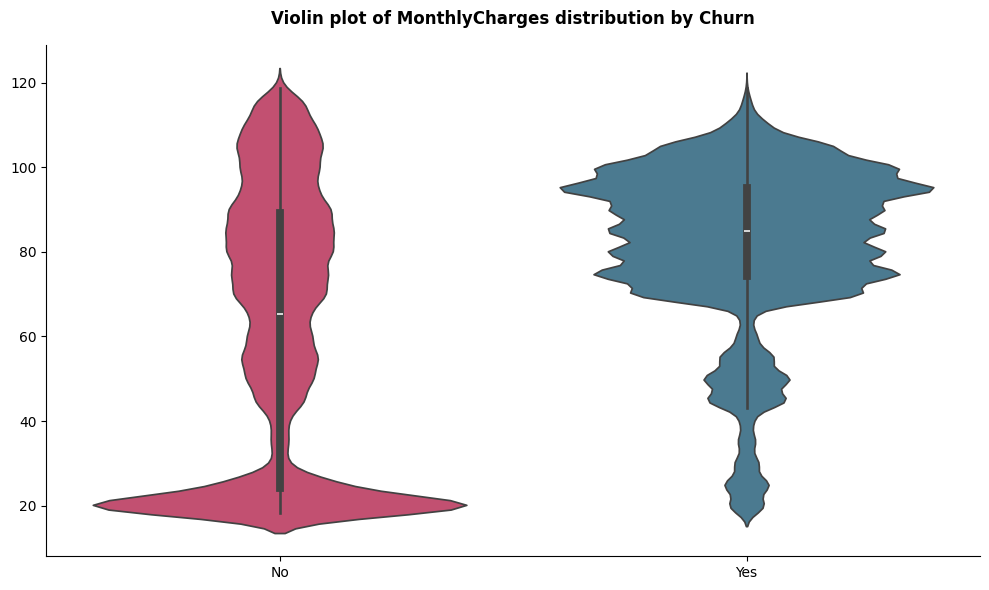

,Churn,Count,Mean,Median,Std
0,No,460377,2771.500515,1688.750000,2423.054655
1,Yes,133817,1540.976020,829.550000,1797.643905


2026-03-02 09:18:51 | INFO     | Checking normality of feature 'TotalCharges' by groups of 'Churn'...
2026-03-02 09:18:51 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-03-02 09:18:51 | DEBUG    | Number of groups detected: 2
2026-03-02 09:18:51 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-03-02 09:18:52 | DEBUG    | [Churn=No] skew=0.7399, kurtosis=-0.7818 → Moderately skewed, Normal tails
2026-03-02 09:18:52 | DEBUG    | [Churn=Yes] skew=1.6673, kurtosis=2.1808 → Highly skewed, Heavy/light tails
2026-03-02 09:18:52 | INFO     | Generating Q–Q plots for visual assessment...


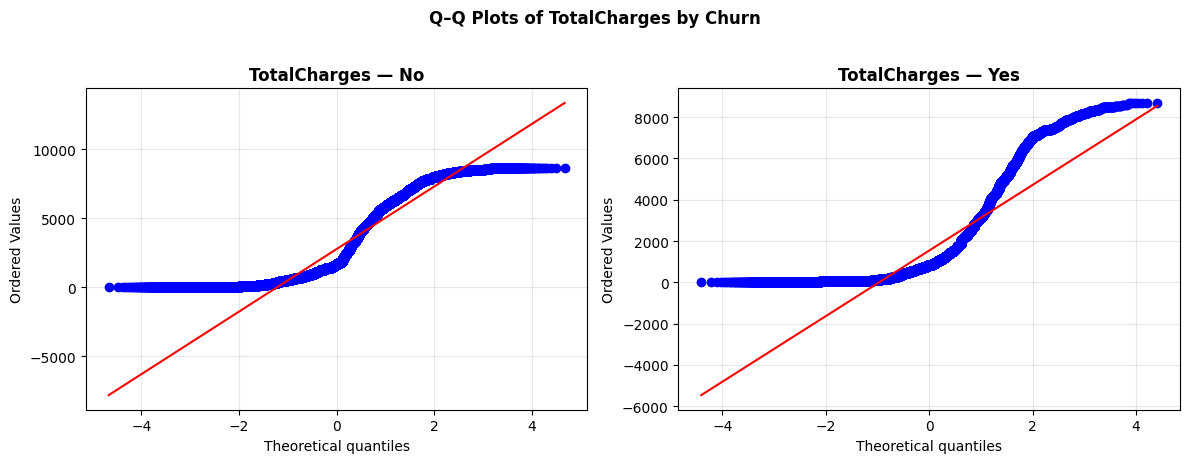

,Feature,Group,Skewness,Kurtosis,Remark
0,TotalCharges,No,0.7399,-0.7818,"Moderately skewed, Normal tails"
1,TotalCharges,Yes,1.6673,2.1808,"Highly skewed, Heavy/light tails"


2026-03-02 09:18:53 | WARNING  | Normality assumption violated in at least one group.
2026-03-02 09:18:53 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-03-02 09:18:53 | INFO     | Running Mann–Whitney U Test: 'TotalCharges' by 'Churn'...
2026-03-02 09:18:53 | DEBUG    | Number of groups detected: 2
2026-03-02 09:18:54 | INFO     | U statistic: 41143968224.0
2026-03-02 09:18:54 | INFO     | p-value    : 0.000000
2026-03-02 09:18:54 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-03-02 09:18:54 | INFO     | Conclusion: Significant difference between the two groups.
2026-03-02 09:18:54 | INFO     | Effect size interpretation: Small


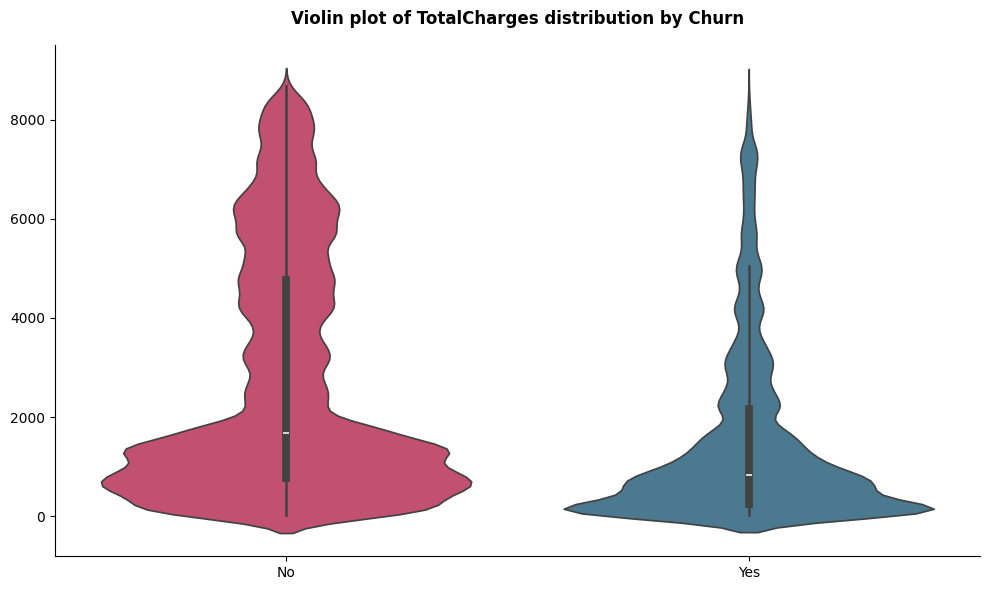

In [19]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df_train,  target_feature: str = config.target_feature) -> None:
    """
    Automatically select and perform appropriate statistical tests
    for comparing a numerical feature across categorical groups.

    This function implements a decision-based statistical testing pipeline
    that selects parametric or non-parametric tests based on:

    - Distribution normality (via skewness, kurtosis, and Q–Q plots)
    - Homogeneity of variances
    - Number of categorical groups

    The procedure follows standard statistical analysis guidelines:

    1. Check normality of the numerical feature within each group.
    2. Determine the number of comparison groups.
    3. Evaluate homogeneity of variance when parametric tests are applicable.
    4. Select and execute the most appropriate hypothesis test.

    Decision Logic
    --------------
    For more than two groups:

    - Non-normal distribution → Kruskal–Wallis test
    - Normal + equal variances → One-way ANOVA + Tukey HSD
    - Normal + unequal variances → Welch’s ANOVA
    - Otherwise → Kruskal–Wallis test

    For two groups:

    - Non-normal distribution → Mann–Whitney U test
    - Normal + equal variances → Independent t-test (with Cohen’s d)
    - Normal + unequal variances → Welch’s t-test (with Cohen’s d)
    - Otherwise → Mann–Whitney U test

    The function also reports effect sizes and post-hoc comparisons
    where applicable.

    Parameters
    ----------
    feature : str
        Name of the numerical feature to be analyzed.

    df : pandas.DataFrame, default=df_train
        Dataset containing the numerical feature and categorical target.

    target_feature : str, default=config.target_feature
        Categorical variable defining comparison groups.

    Returns
    -------
    None
        Executes statistical tests and logs/prints results.
        No value is returned.

    Notes
    -----
    - This function is designed for exploratory and confirmatory
      statistical analysis in machine learning and research workflows.
    - Assumption checks (normality and homoscedasticity) are performed
      automatically prior to testing.
    - For small sample sizes, non-parametric tests are generally preferred.

    Examples
    --------
    >>> perform_statical_testing(
    ...     feature="cholesterol",
    ...     df=df_train,
    ...     target_feature="heart_disease"
    ... )
    """

    # Step 1: Check normality of the feature in each group
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    # Count number of categories in target feature
    total_categories = df[target_feature].nunique()
    # Case 1: More than two groups (Multi-class comparison)
    if total_categories > 2:
        # If data is not normally distributed → use Kruskal–Wallis
        if non_normal_detected:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → One-way ANOVA + Tukey test
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            # Normal + unequal variance → Welch ANOVA
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            # Otherwise → fallback to Kruskal–Wallis
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    # Case 2: Two groups (Binary comparison)
    else:
        # If data is not normal → use Mann–Whitney U test
        if non_normal_detected:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        # If data is approximately normal → check variance homogeneity
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            # Normal + equal variance → Independent t-test + Cohen's d
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            # Normal + unequal variance → Welch t-test + Cohen's d
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            # Otherwise → fallback to Mann–Whitney U
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df_train,
                                target_feature: str = config.target_feature, order: list = None) -> None:
    """
    Analyze and visualize the distribution of a numerical feature
    across categories of a target variable.

    This function performs:
    - Descriptive statistics (mean, median, std) by group
    - Overall summary statistics
    - Automated statistical hypothesis testing
    - Violin plot visualization

    Parameters
    ----------
    feature : str
        Numerical feature to be analyzed.

    df : pandas.DataFrame
        Input dataset containing the feature and target variable.

    target_feature : str
        Categorical variable used for grouping.

    order : list, optional
        Custom order of categories for plotting.

    Returns
    -------
    None
        Displays summary tables, test results, and plots.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False).reset_index(drop=True)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))
    
    plt.title(f"Violin plot of {feature} distribution by {target_feature}", pad=15, weight="bold", fontsize=12)
    plt.xlabel("")
    plt.ylabel("")
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Diagnosed Diabetes</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight: Numerical Features vs Churn
</div>

<div style="line-height:1.8;">

<p><b><code>tenure</code></b><br>
Customers who churn exhibit significantly lower tenure compared to retained customers, 
indicating that churn risk is highest during the early customer lifecycle.</p>

<p><b><code>MonthlyCharges</code></b><br>
Customers who churn tend to have slightly higher monthly charges than retained customers; 
however, the effect size is small, suggesting limited practical impact.</p>

<p><b><code>TotalCharges</code></b><br>
Customers who churn show significantly lower total charges than retained customers, 
primarily reflecting their shorter tenure. The observed effect size remains small.</p>

</div>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Early-lifecycle customers represent the highest churn risk segment, 
while pricing differences alone appear insufficient to explain churn behavior.
</div>

</div>

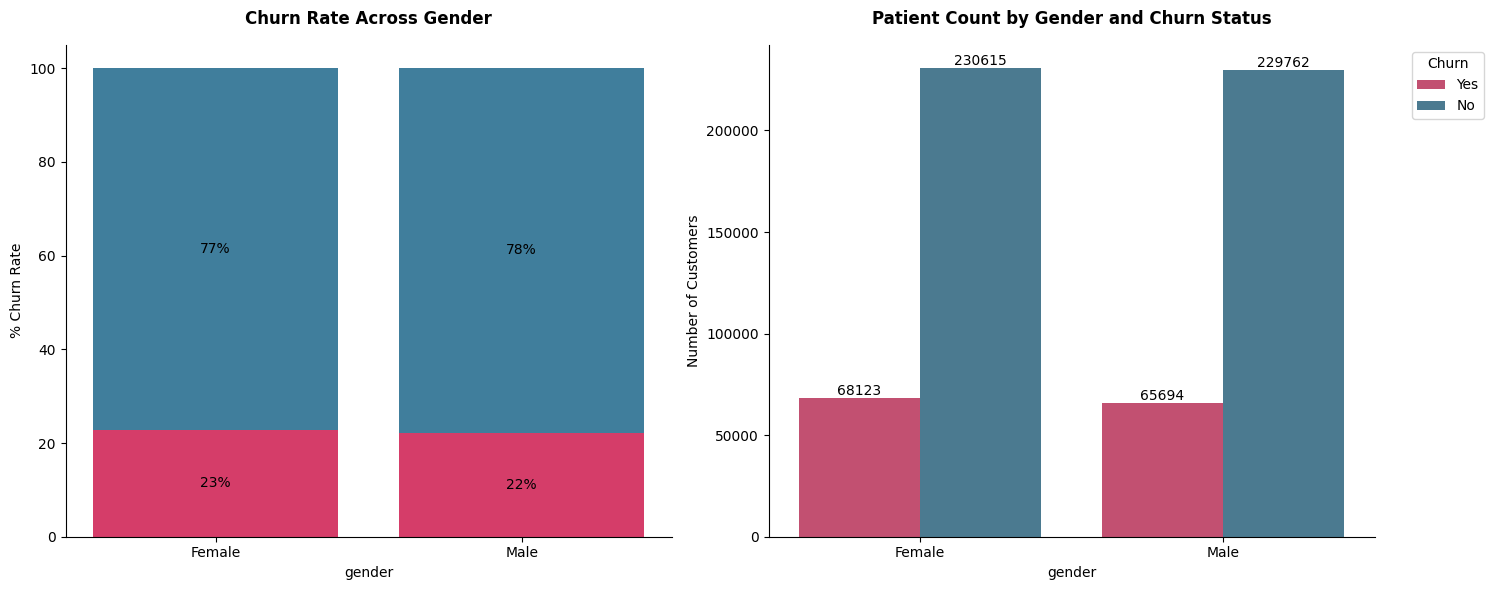

2026-03-02 09:18:58 | INFO     | Chi-Square Test of Independence: 'gender' vs. 'Churn'...
2026-03-02 09:18:58 | INFO     | Chi-squared statistic: 27.511
2026-03-02 09:18:58 | INFO     | Degrees of freedom: 1
2026-03-02 09:18:58 | INFO     | p-value: 0.000000
2026-03-02 09:18:58 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:18:58 | INFO     | Variables 'gender' and 'Churn' are statistically associated.
2026-03-02 09:18:58 | DEBUG    | Displaying standardized residuals heatmap.


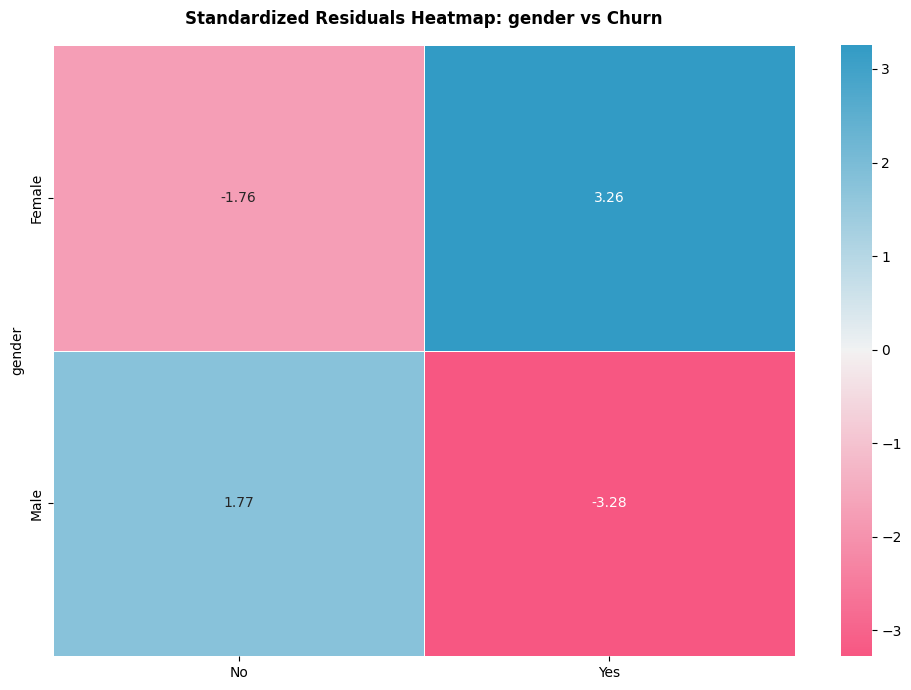

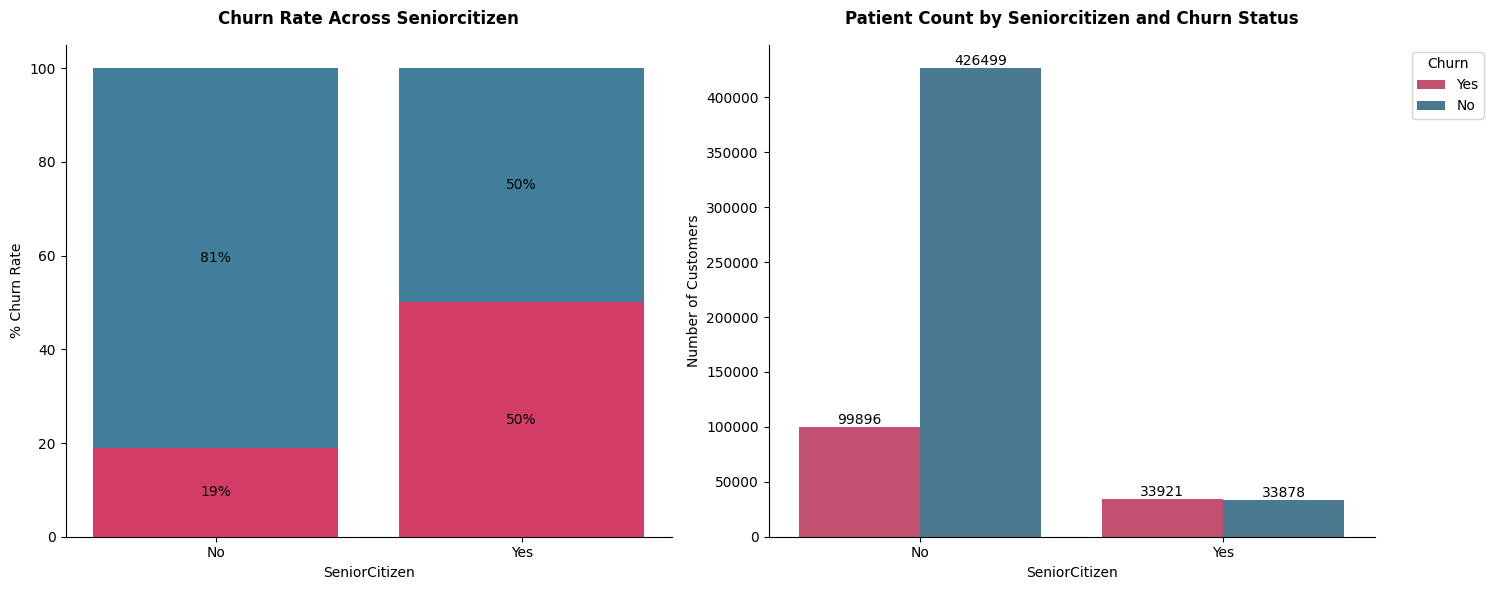

2026-03-02 09:19:00 | INFO     | Chi-Square Test of Independence: 'SeniorCitizen' vs. 'Churn'...
2026-03-02 09:19:00 | INFO     | Chi-squared statistic: 33193.983
2026-03-02 09:19:00 | INFO     | Degrees of freedom: 1
2026-03-02 09:19:00 | INFO     | p-value: 0.000000
2026-03-02 09:19:00 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:00 | INFO     | Variables 'SeniorCitizen' and 'Churn' are statistically associated.
2026-03-02 09:19:00 | DEBUG    | Displaying standardized residuals heatmap.


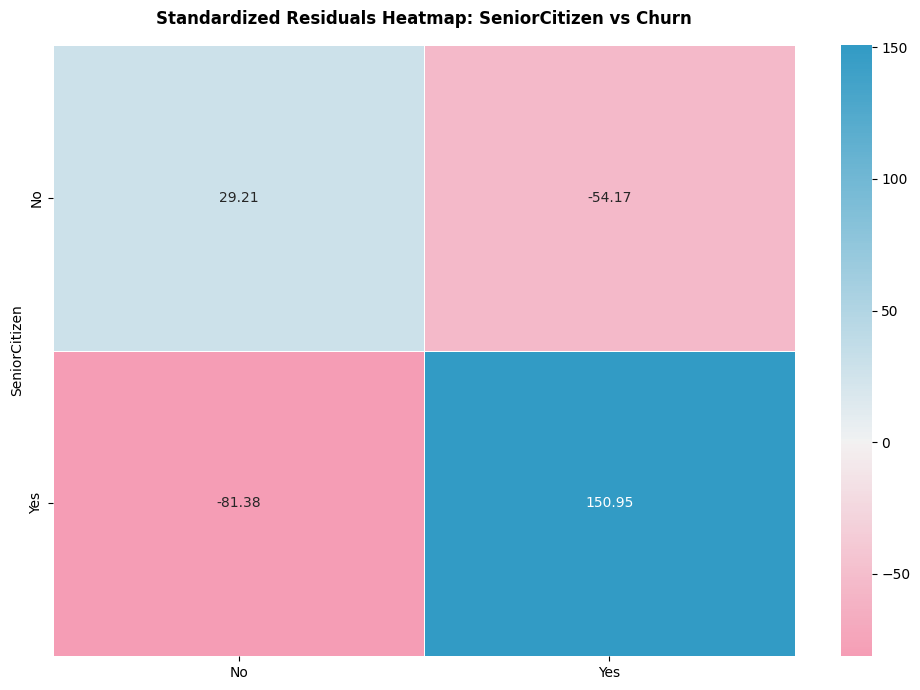

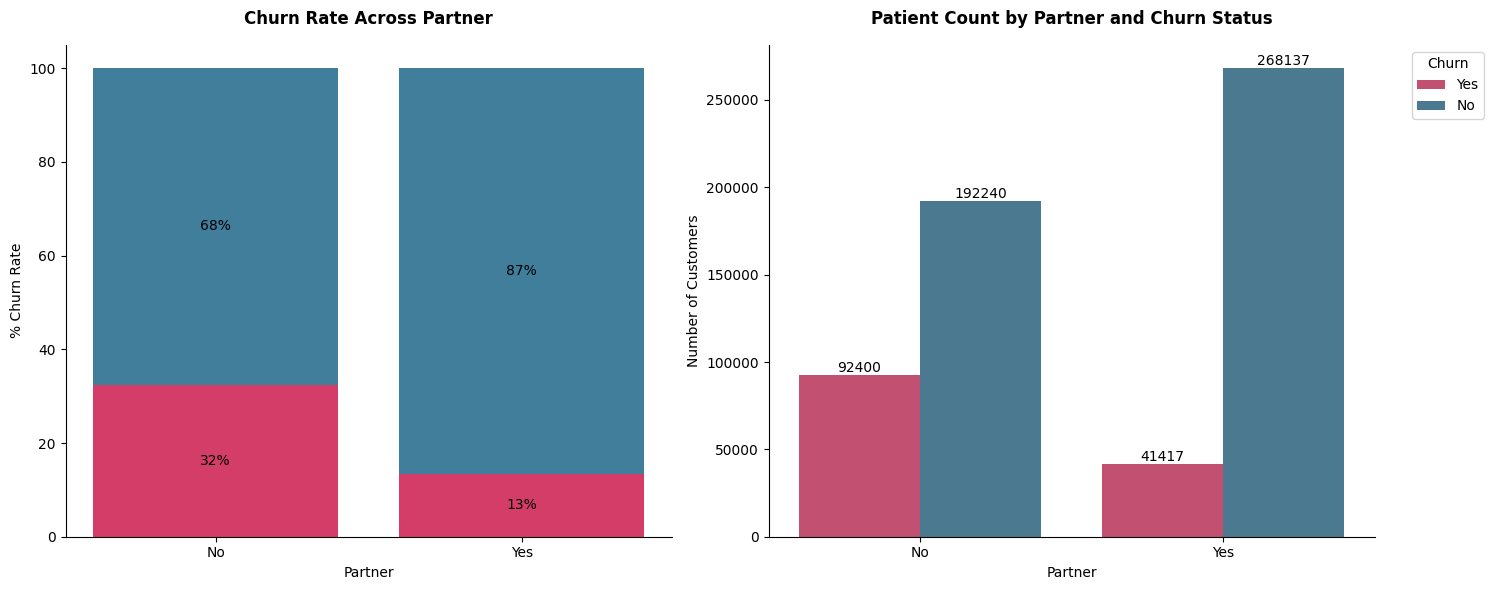

2026-03-02 09:19:02 | INFO     | Chi-Square Test of Independence: 'Partner' vs. 'Churn'...
2026-03-02 09:19:02 | INFO     | Chi-squared statistic: 30944.982
2026-03-02 09:19:02 | INFO     | Degrees of freedom: 1
2026-03-02 09:19:02 | INFO     | p-value: 0.000000
2026-03-02 09:19:02 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:02 | INFO     | Variables 'Partner' and 'Churn' are statistically associated.
2026-03-02 09:19:02 | DEBUG    | Displaying standardized residuals heatmap.


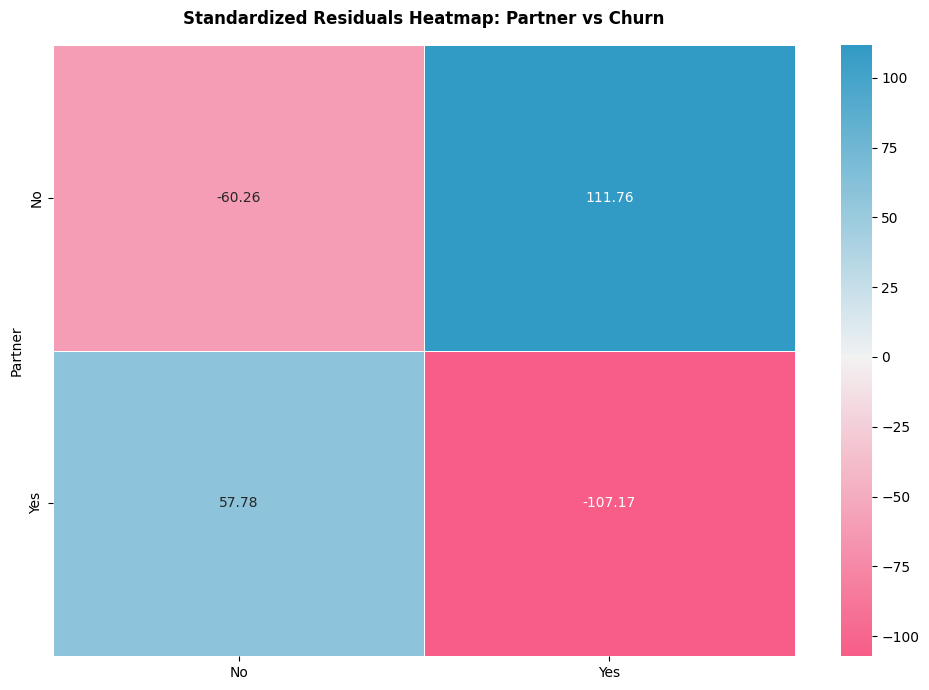

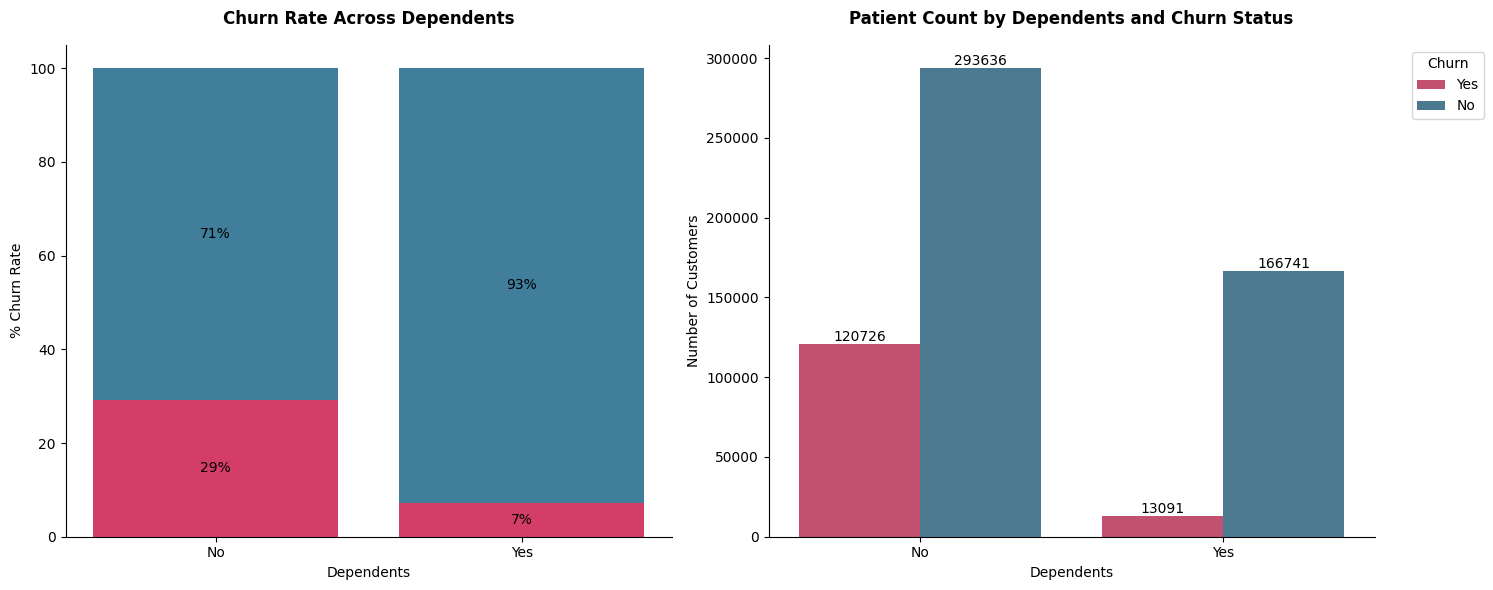

2026-03-02 09:19:03 | INFO     | Chi-Square Test of Independence: 'Dependents' vs. 'Churn'...
2026-03-02 09:19:03 | INFO     | Chi-squared statistic: 34329.595
2026-03-02 09:19:03 | INFO     | Degrees of freedom: 1
2026-03-02 09:19:03 | INFO     | p-value: 0.000000
2026-03-02 09:19:03 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:03 | INFO     | Variables 'Dependents' and 'Churn' are statistically associated.
2026-03-02 09:19:03 | DEBUG    | Displaying standardized residuals heatmap.


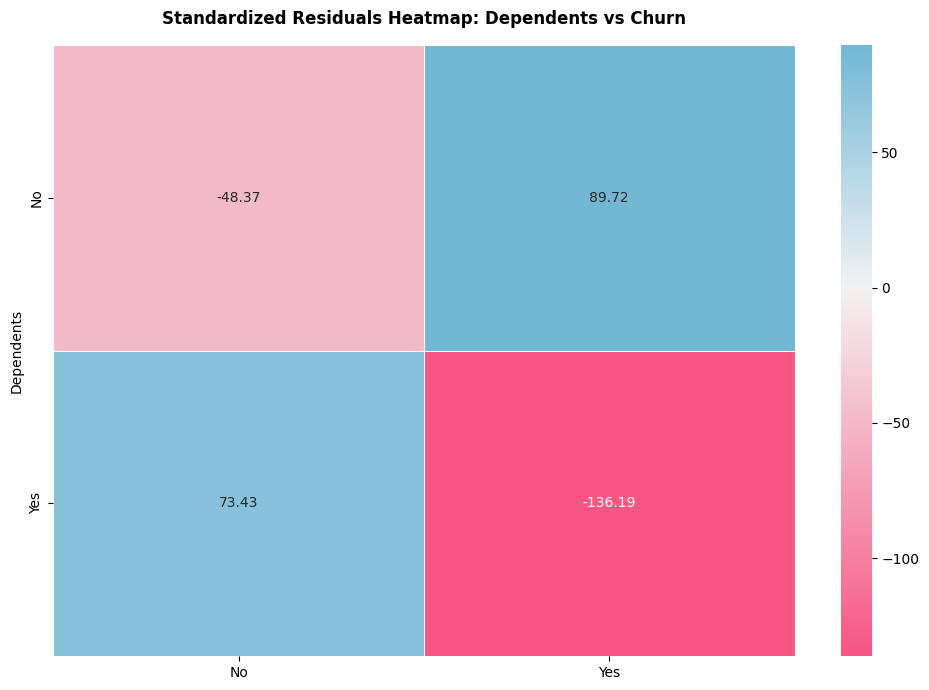

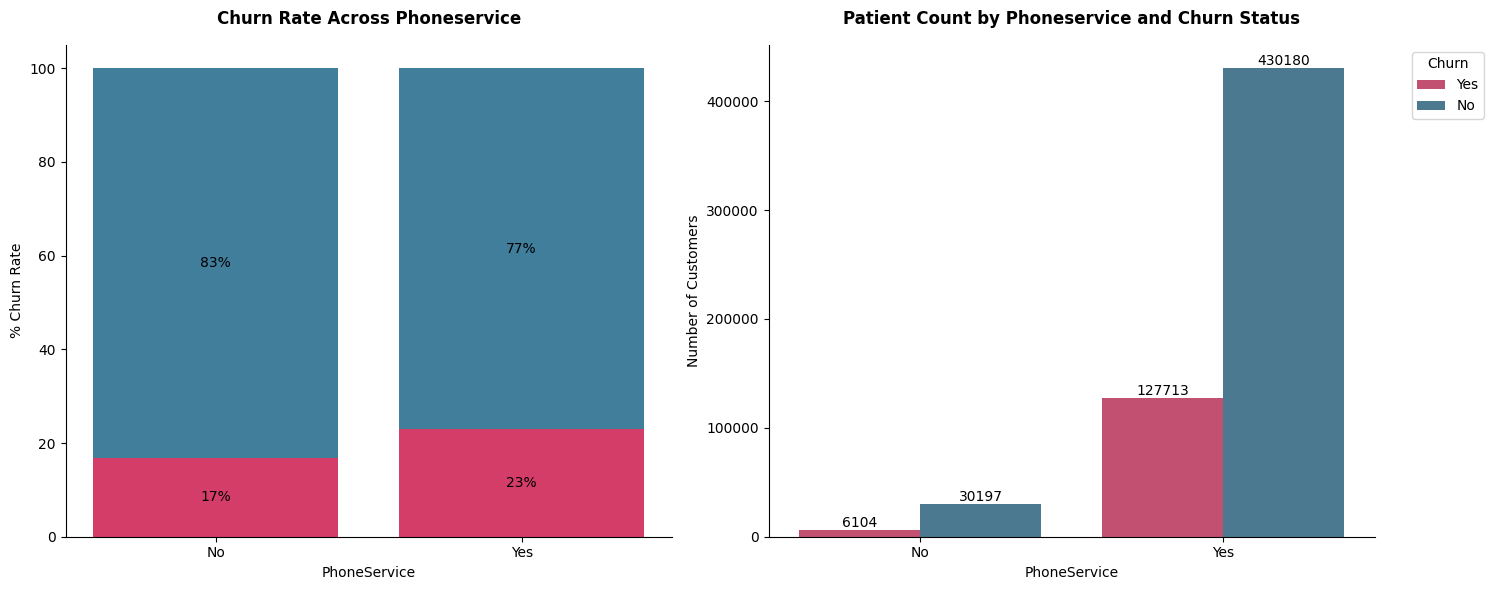

2026-03-02 09:19:05 | INFO     | Chi-Square Test of Independence: 'PhoneService' vs. 'Churn'...
2026-03-02 09:19:05 | INFO     | Chi-squared statistic: 721.025
2026-03-02 09:19:05 | INFO     | Degrees of freedom: 1
2026-03-02 09:19:05 | INFO     | p-value: 0.000000
2026-03-02 09:19:05 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:05 | INFO     | Variables 'PhoneService' and 'Churn' are statistically associated.
2026-03-02 09:19:05 | DEBUG    | Displaying standardized residuals heatmap.


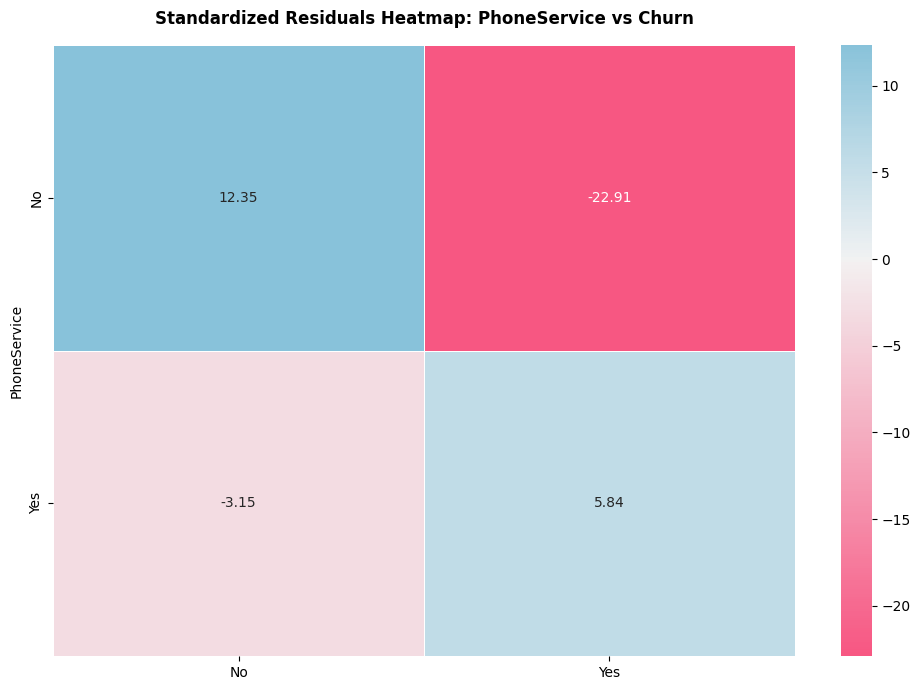

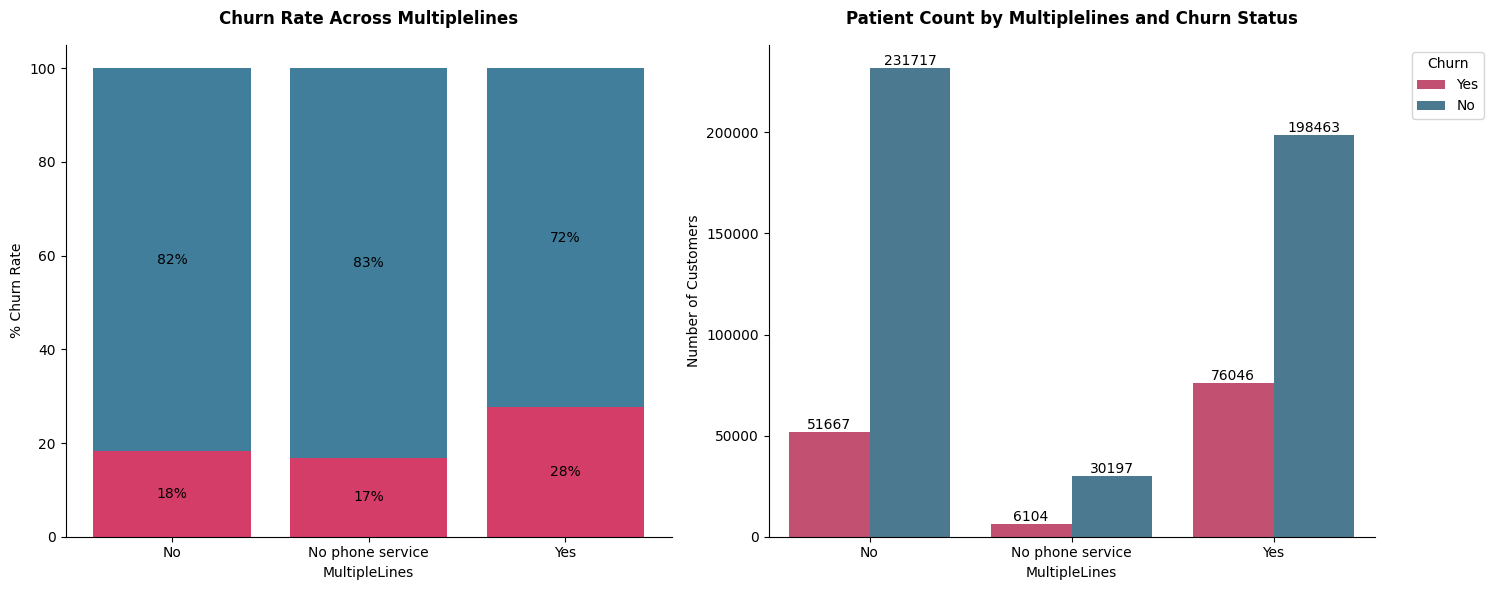

2026-03-02 09:19:07 | INFO     | Chi-Square Test of Independence: 'MultipleLines' vs. 'Churn'...
2026-03-02 09:19:07 | INFO     | Chi-squared statistic: 7888.571
2026-03-02 09:19:07 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:07 | INFO     | p-value: 0.000000
2026-03-02 09:19:07 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:07 | INFO     | Variables 'MultipleLines' and 'Churn' are statistically associated.
2026-03-02 09:19:07 | DEBUG    | Displaying standardized residuals heatmap.


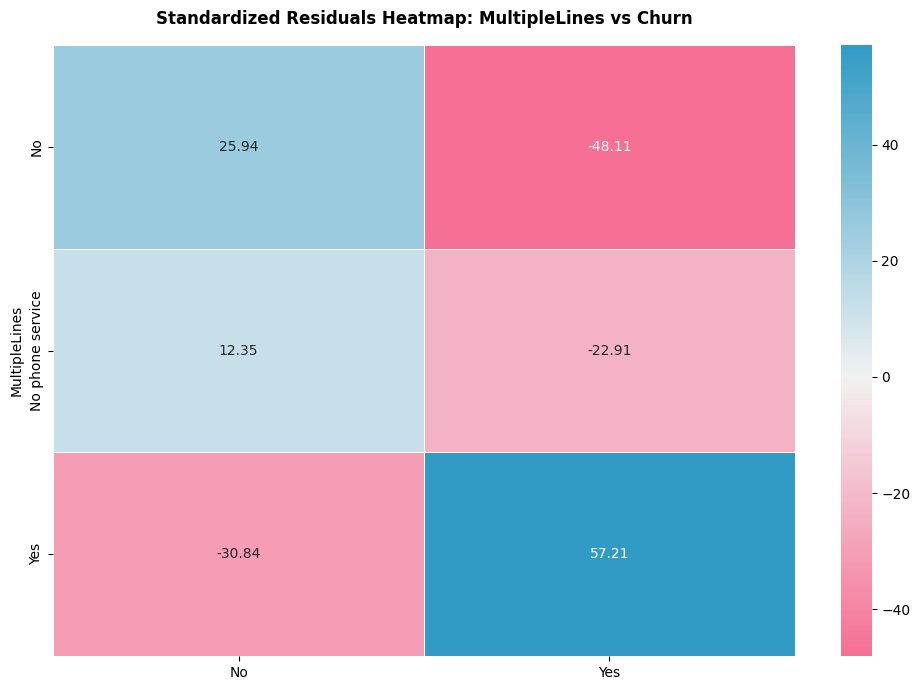

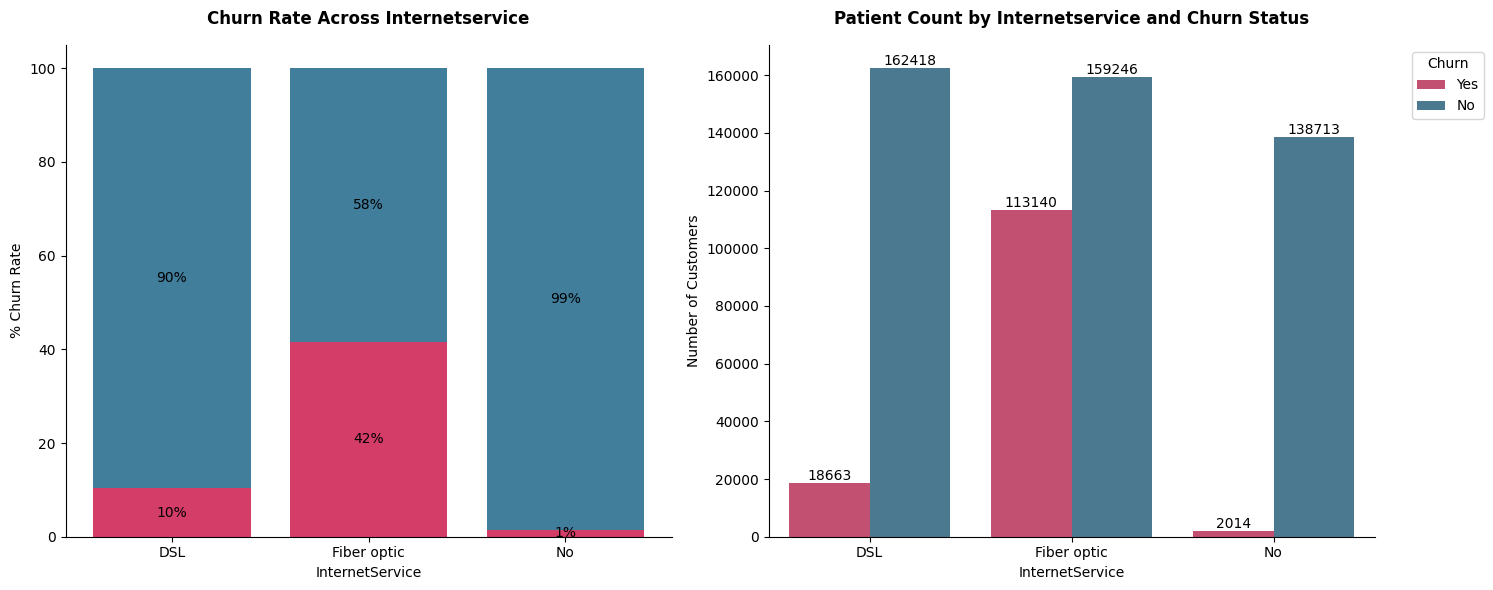

2026-03-02 09:19:09 | INFO     | Chi-Square Test of Independence: 'InternetService' vs. 'Churn'...
2026-03-02 09:19:09 | INFO     | Chi-squared statistic: 107801.940
2026-03-02 09:19:09 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:09 | INFO     | p-value: 0.000000
2026-03-02 09:19:09 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:09 | INFO     | Variables 'InternetService' and 'Churn' are statistically associated.
2026-03-02 09:19:09 | DEBUG    | Displaying standardized residuals heatmap.


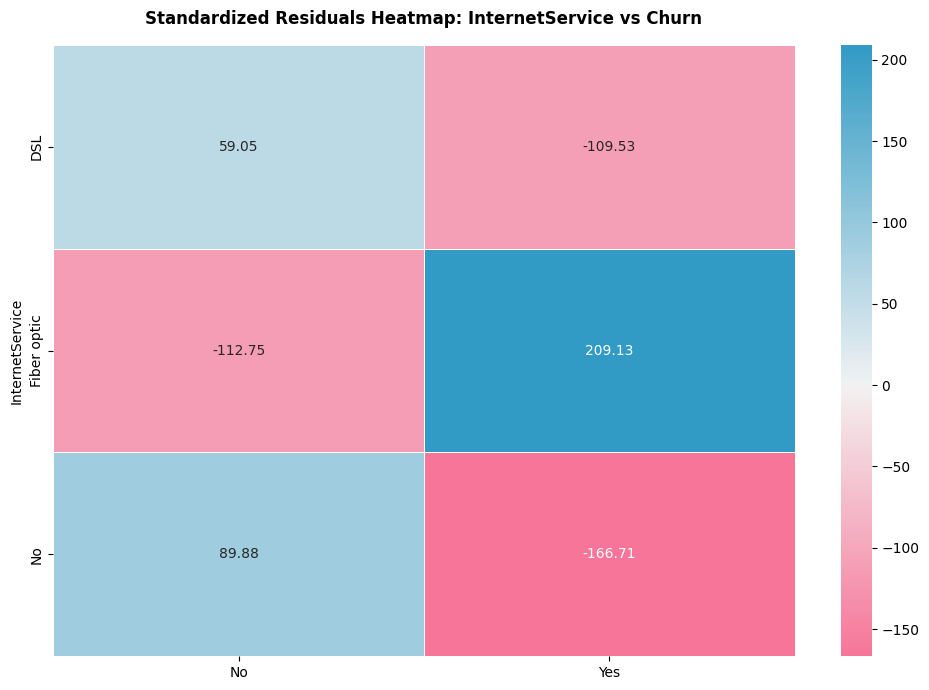

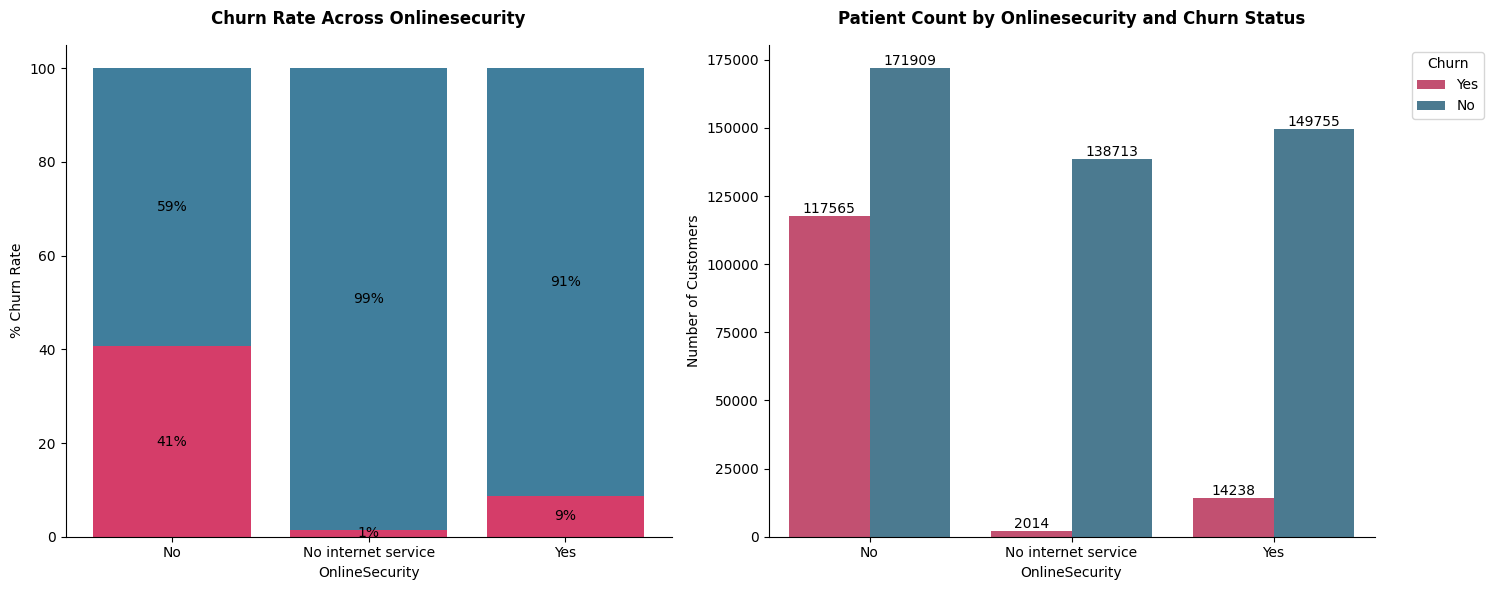

2026-03-02 09:19:11 | INFO     | Chi-Square Test of Independence: 'OnlineSecurity' vs. 'Churn'...
2026-03-02 09:19:11 | INFO     | Chi-squared statistic: 108175.344
2026-03-02 09:19:11 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:11 | INFO     | p-value: 0.000000
2026-03-02 09:19:11 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:11 | INFO     | Variables 'OnlineSecurity' and 'Churn' are statistically associated.
2026-03-02 09:19:11 | DEBUG    | Displaying standardized residuals heatmap.


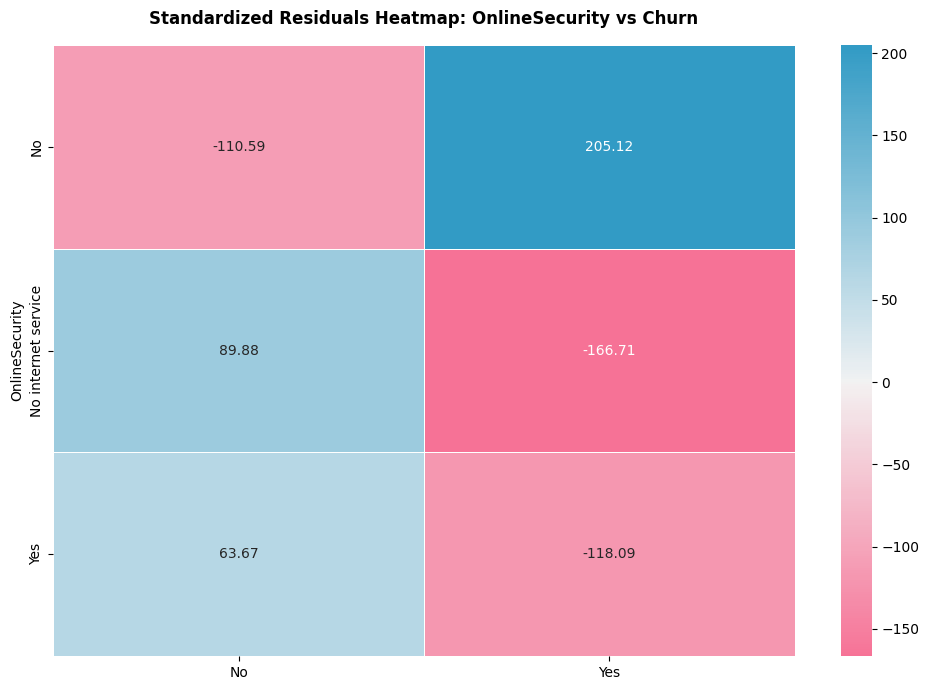

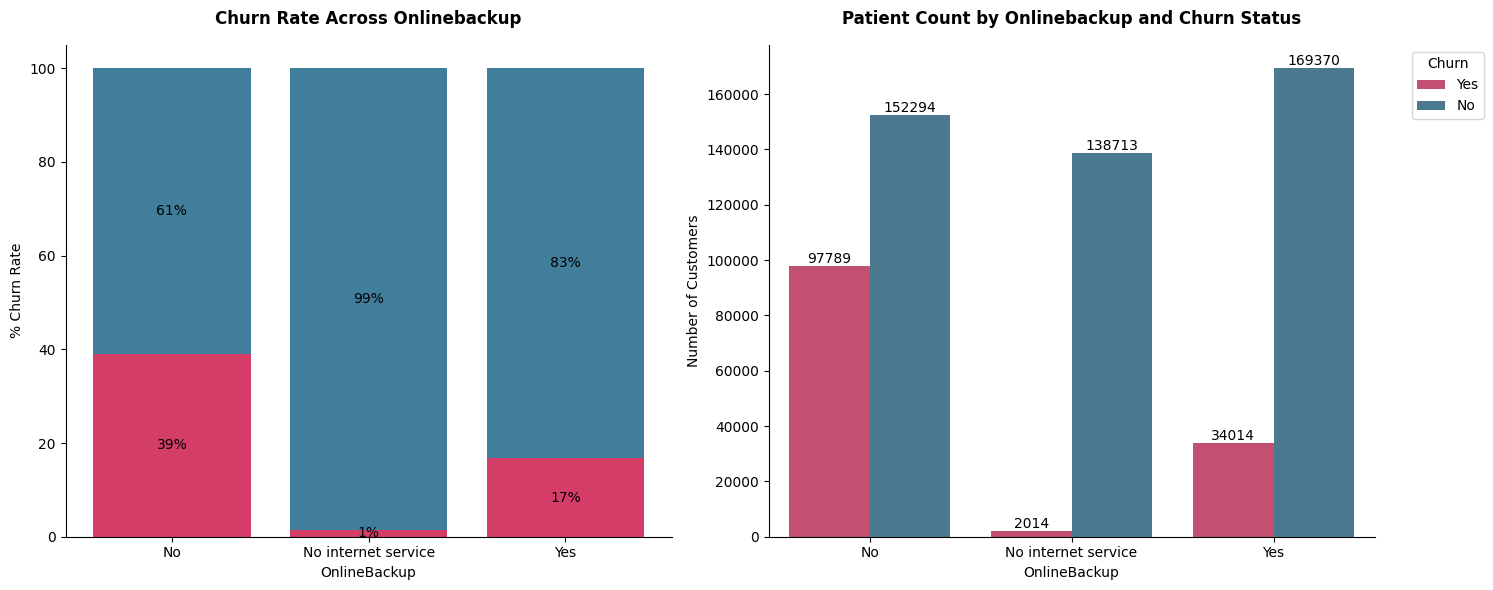

2026-03-02 09:19:13 | INFO     | Chi-Square Test of Independence: 'OnlineBackup' vs. 'Churn'...
2026-03-02 09:19:13 | INFO     | Chi-squared statistic: 79195.701
2026-03-02 09:19:13 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:13 | INFO     | p-value: 0.000000
2026-03-02 09:19:13 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:13 | INFO     | Variables 'OnlineBackup' and 'Churn' are statistically associated.
2026-03-02 09:19:13 | DEBUG    | Displaying standardized residuals heatmap.


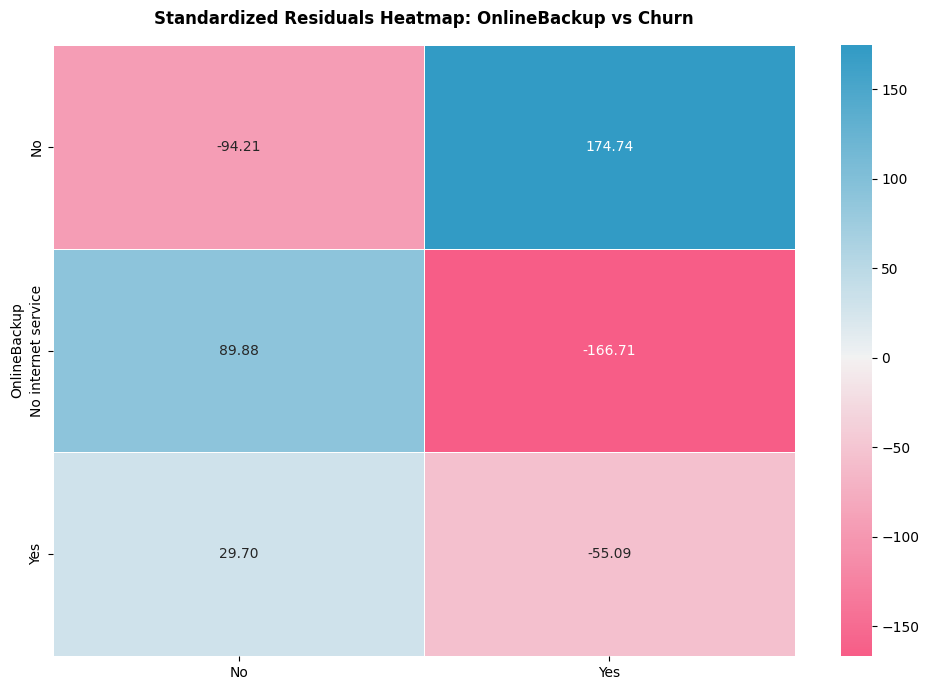

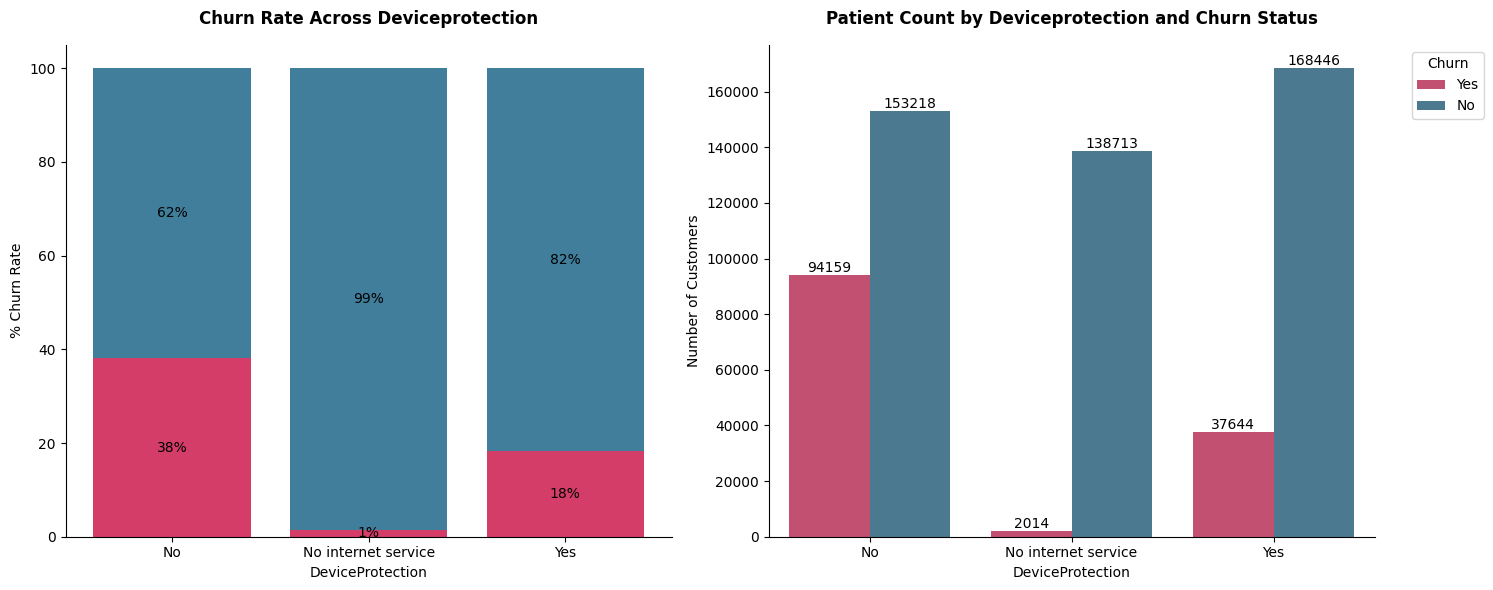

2026-03-02 09:19:15 | INFO     | Chi-Square Test of Independence: 'DeviceProtection' vs. 'Churn'...
2026-03-02 09:19:15 | INFO     | Chi-squared statistic: 72256.065
2026-03-02 09:19:15 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:15 | INFO     | p-value: 0.000000
2026-03-02 09:19:15 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:15 | INFO     | Variables 'DeviceProtection' and 'Churn' are statistically associated.
2026-03-02 09:19:15 | DEBUG    | Displaying standardized residuals heatmap.


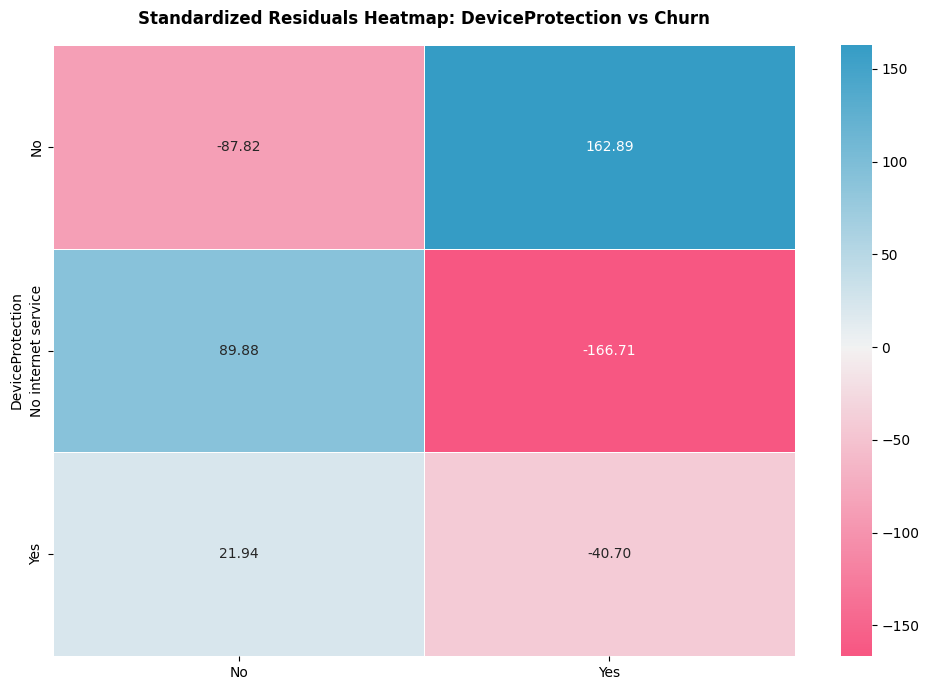

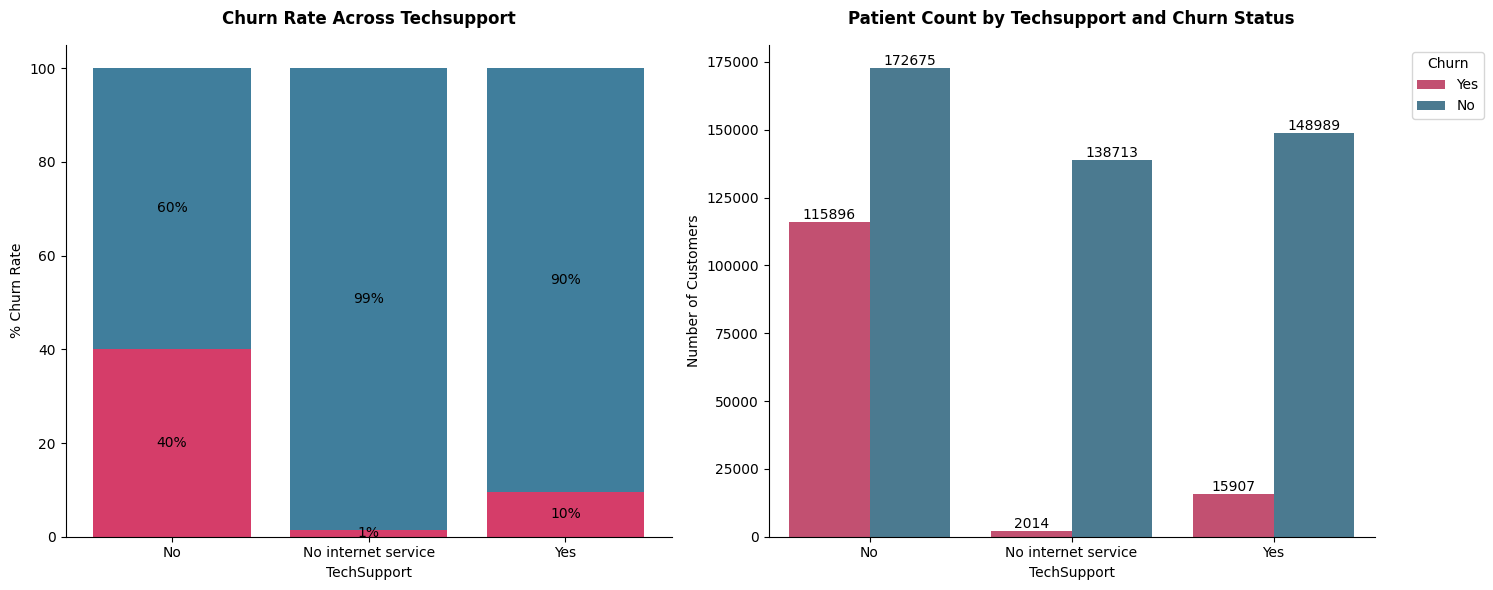

2026-03-02 09:19:17 | INFO     | Chi-Square Test of Independence: 'TechSupport' vs. 'Churn'...
2026-03-02 09:19:17 | INFO     | Chi-squared statistic: 103003.062
2026-03-02 09:19:17 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:17 | INFO     | p-value: 0.000000
2026-03-02 09:19:17 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:17 | INFO     | Variables 'TechSupport' and 'Churn' are statistically associated.
2026-03-02 09:19:17 | DEBUG    | Displaying standardized residuals heatmap.


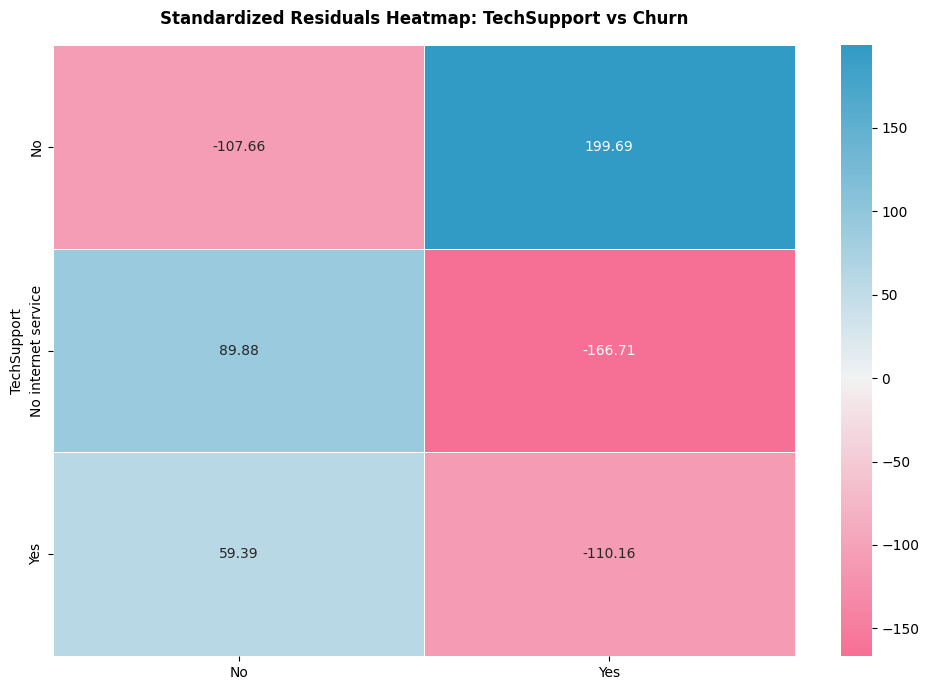

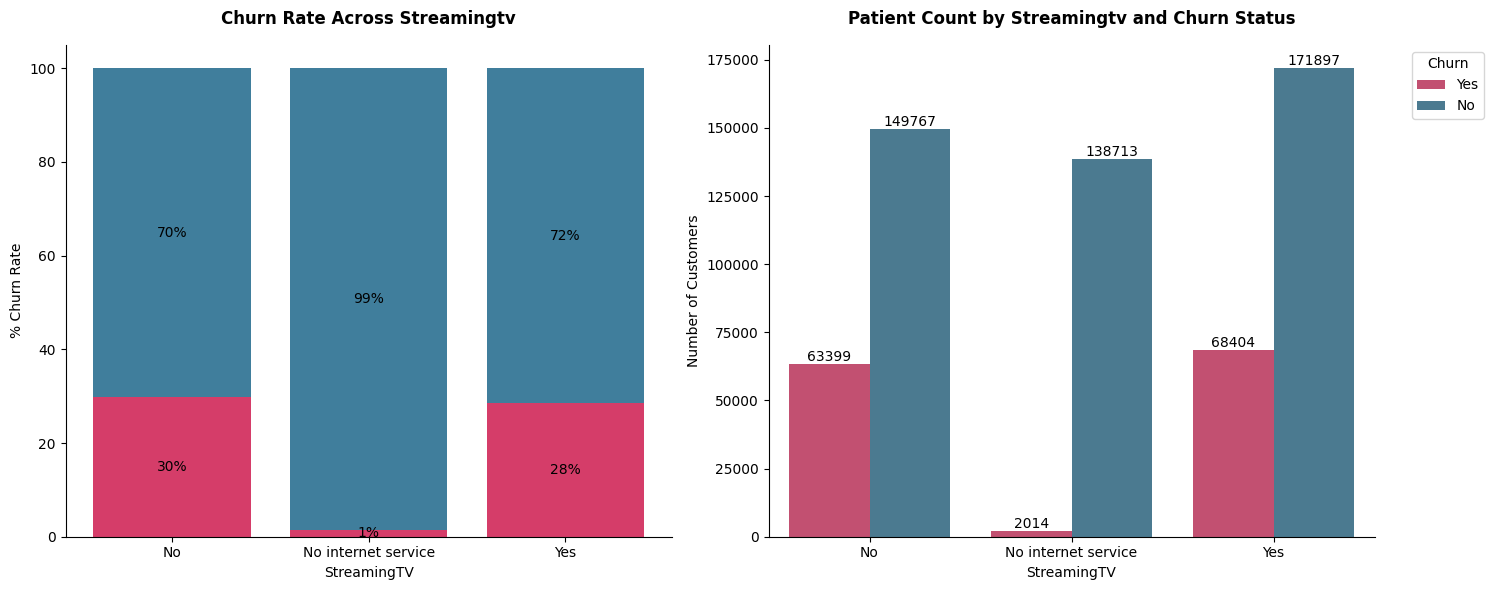

2026-03-02 09:19:18 | INFO     | Chi-Square Test of Independence: 'StreamingTV' vs. 'Churn'...
2026-03-02 09:19:19 | INFO     | Chi-squared statistic: 47108.728
2026-03-02 09:19:19 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:19 | INFO     | p-value: 0.000000
2026-03-02 09:19:19 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:19 | INFO     | Variables 'StreamingTV' and 'Churn' are statistically associated.
2026-03-02 09:19:19 | DEBUG    | Displaying standardized residuals heatmap.


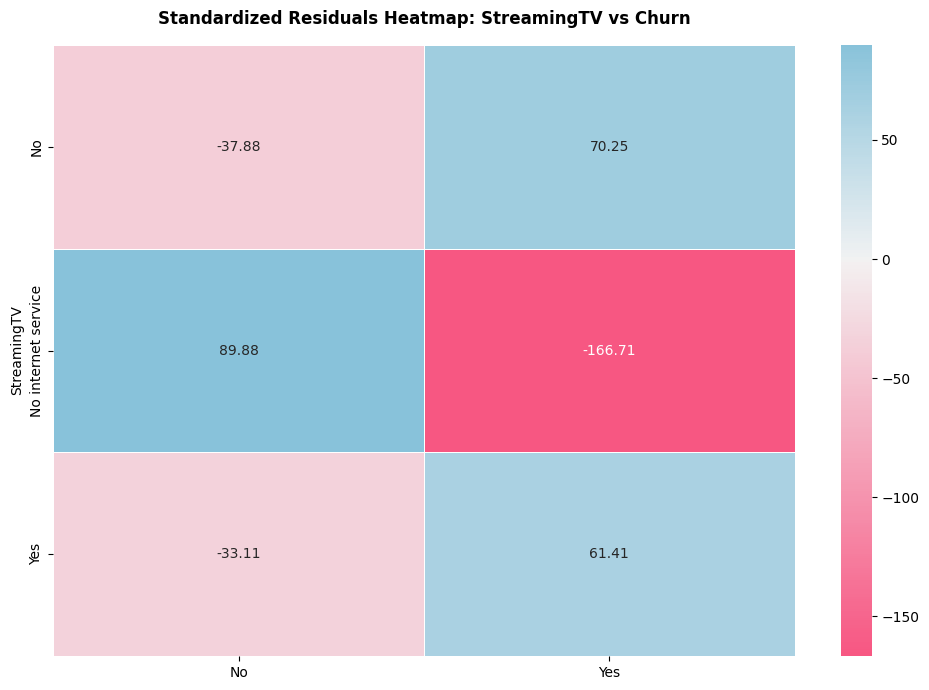

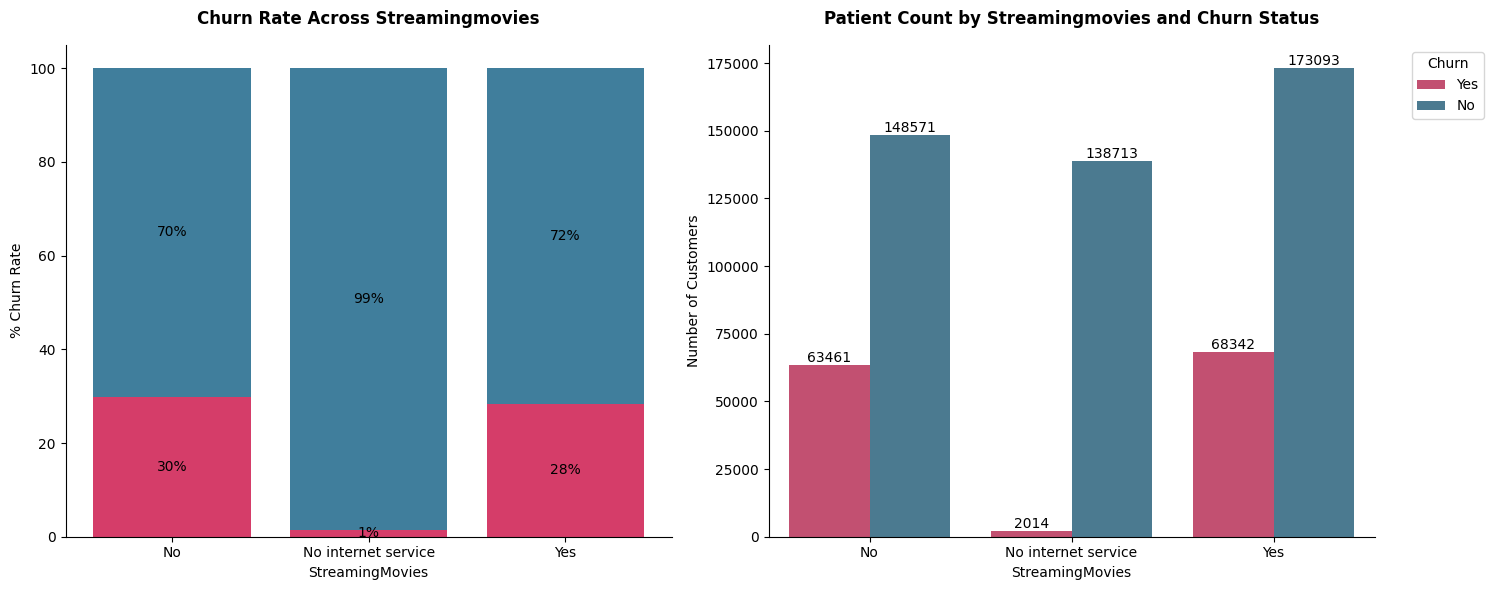

2026-03-02 09:19:20 | INFO     | Chi-Square Test of Independence: 'StreamingMovies' vs. 'Churn'...
2026-03-02 09:19:20 | INFO     | Chi-squared statistic: 47173.874
2026-03-02 09:19:20 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:20 | INFO     | p-value: 0.000000
2026-03-02 09:19:20 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:20 | INFO     | Variables 'StreamingMovies' and 'Churn' are statistically associated.
2026-03-02 09:19:20 | DEBUG    | Displaying standardized residuals heatmap.


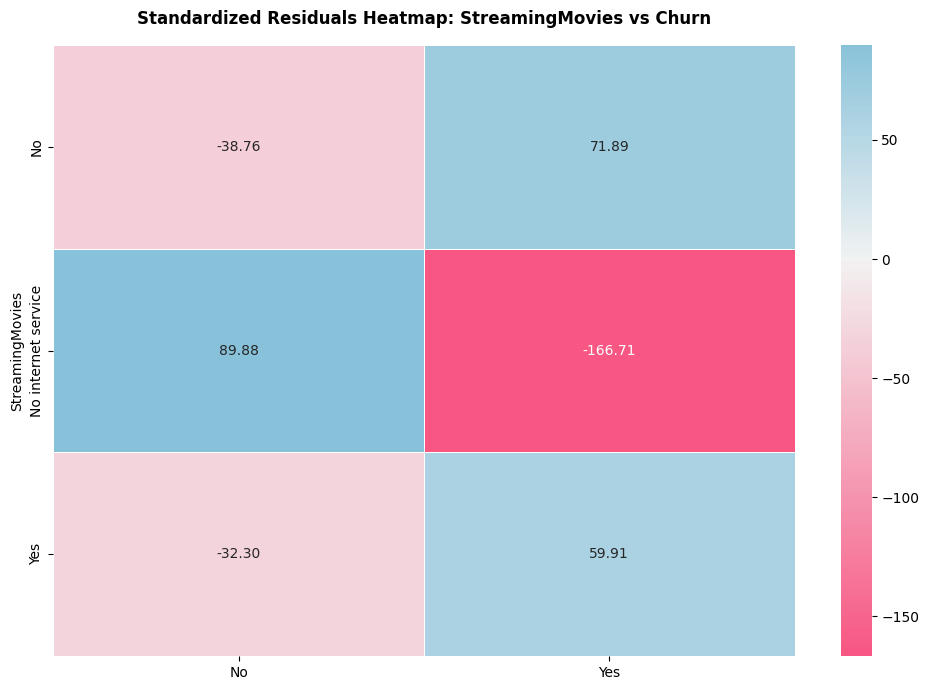

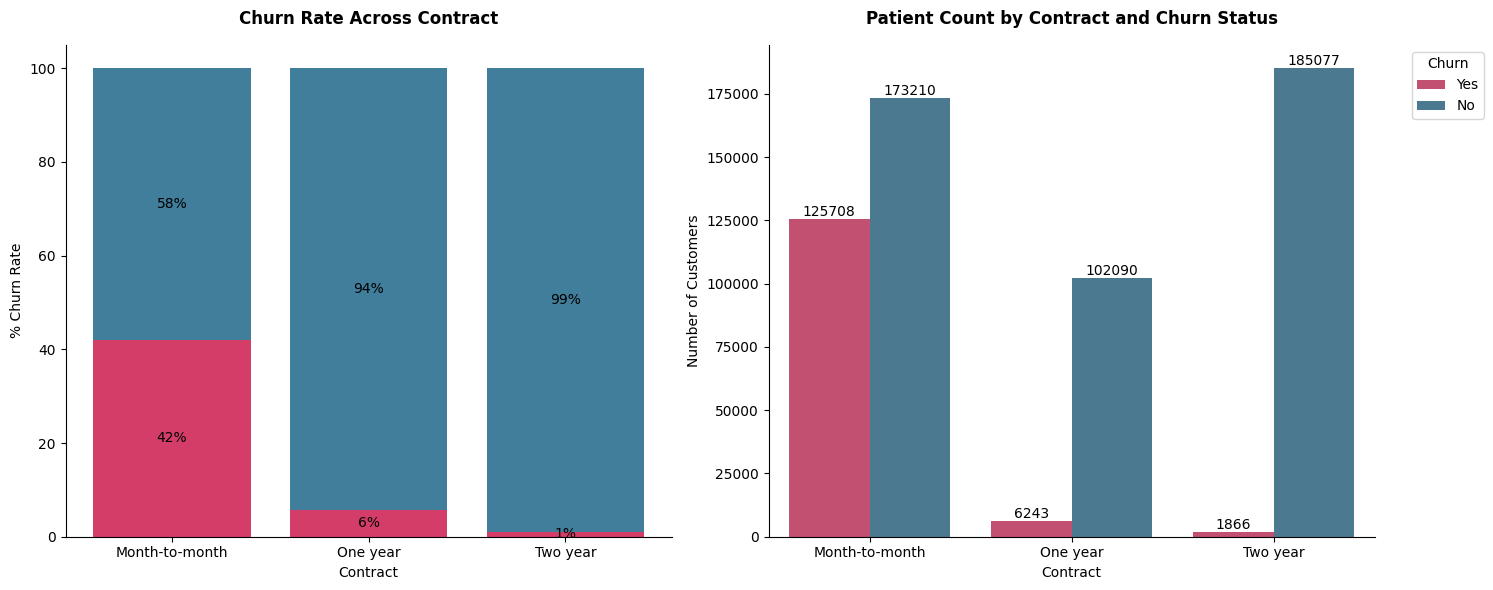

2026-03-02 09:19:22 | INFO     | Chi-Square Test of Independence: 'Contract' vs. 'Churn'...
2026-03-02 09:19:22 | INFO     | Chi-squared statistic: 132429.252
2026-03-02 09:19:22 | INFO     | Degrees of freedom: 2
2026-03-02 09:19:22 | INFO     | p-value: 0.000000
2026-03-02 09:19:22 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:22 | INFO     | Variables 'Contract' and 'Churn' are statistically associated.
2026-03-02 09:19:22 | DEBUG    | Displaying standardized residuals heatmap.


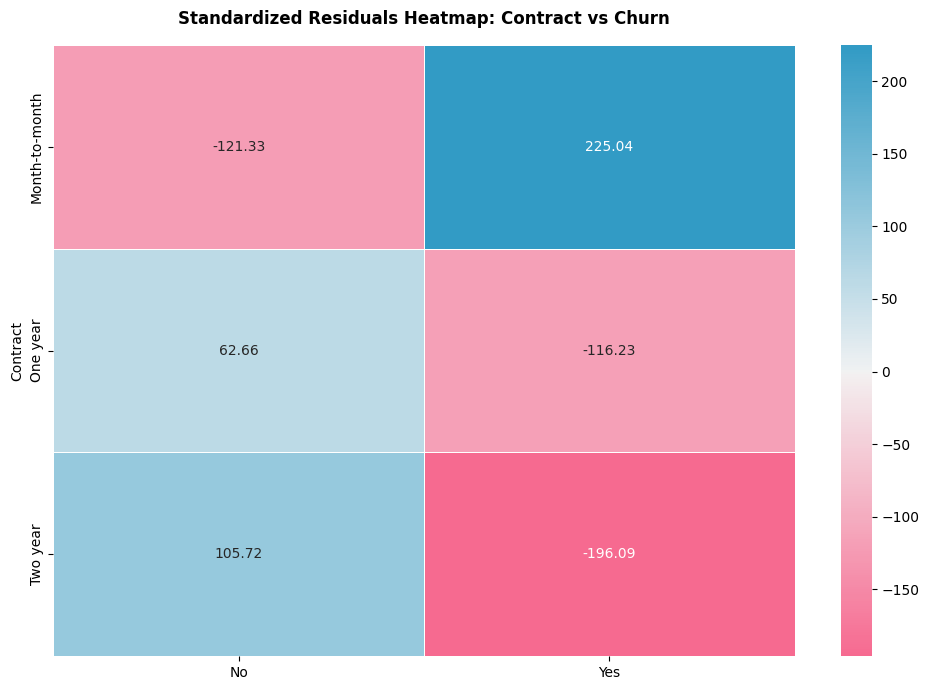

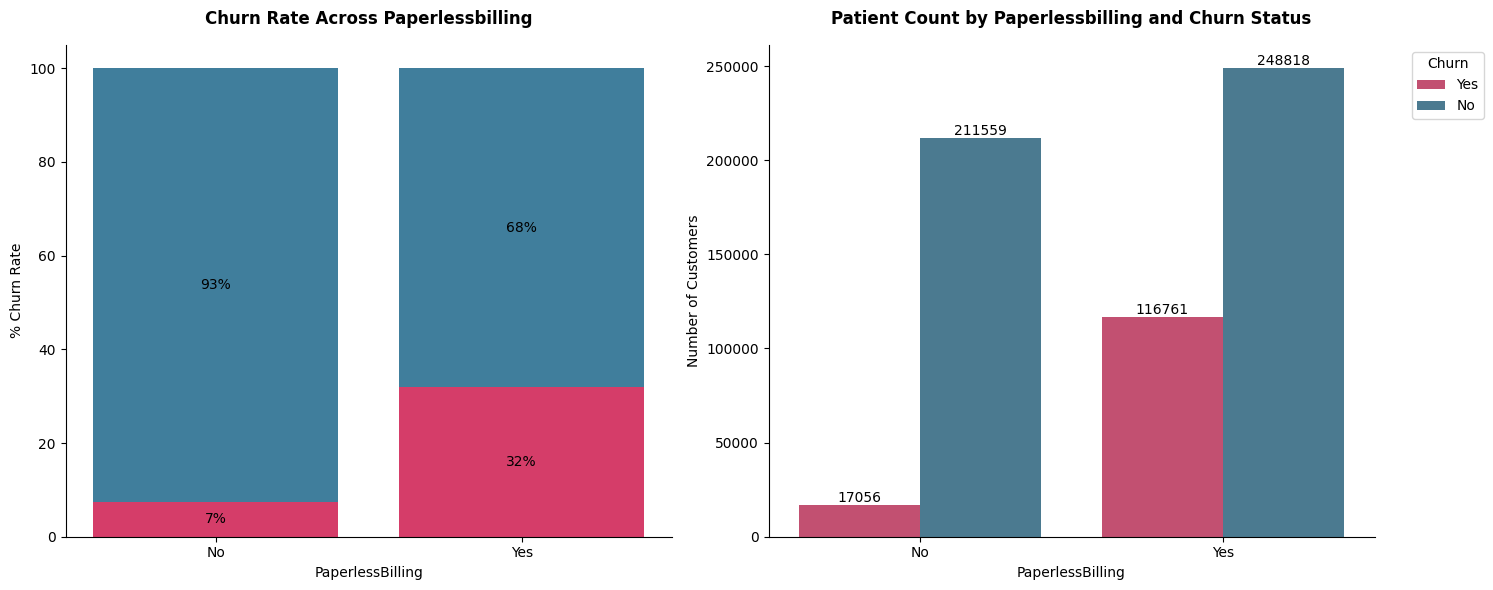

2026-03-02 09:19:24 | INFO     | Chi-Square Test of Independence: 'PaperlessBilling' vs. 'Churn'...
2026-03-02 09:19:24 | INFO     | Chi-squared statistic: 48298.223
2026-03-02 09:19:24 | INFO     | Degrees of freedom: 1
2026-03-02 09:19:24 | INFO     | p-value: 0.000000
2026-03-02 09:19:24 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:24 | INFO     | Variables 'PaperlessBilling' and 'Churn' are statistically associated.
2026-03-02 09:19:24 | DEBUG    | Displaying standardized residuals heatmap.


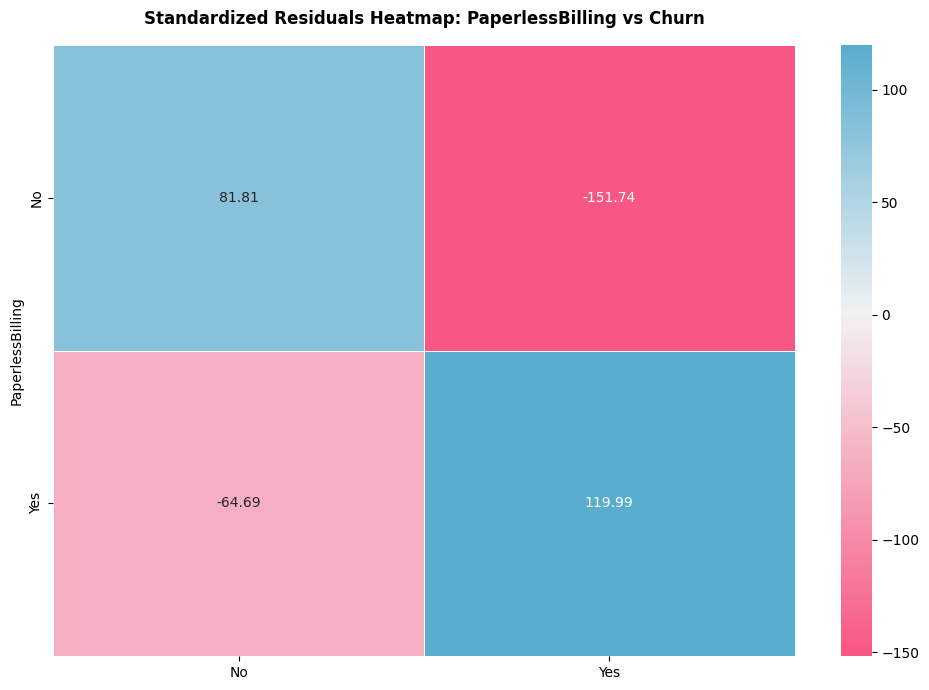

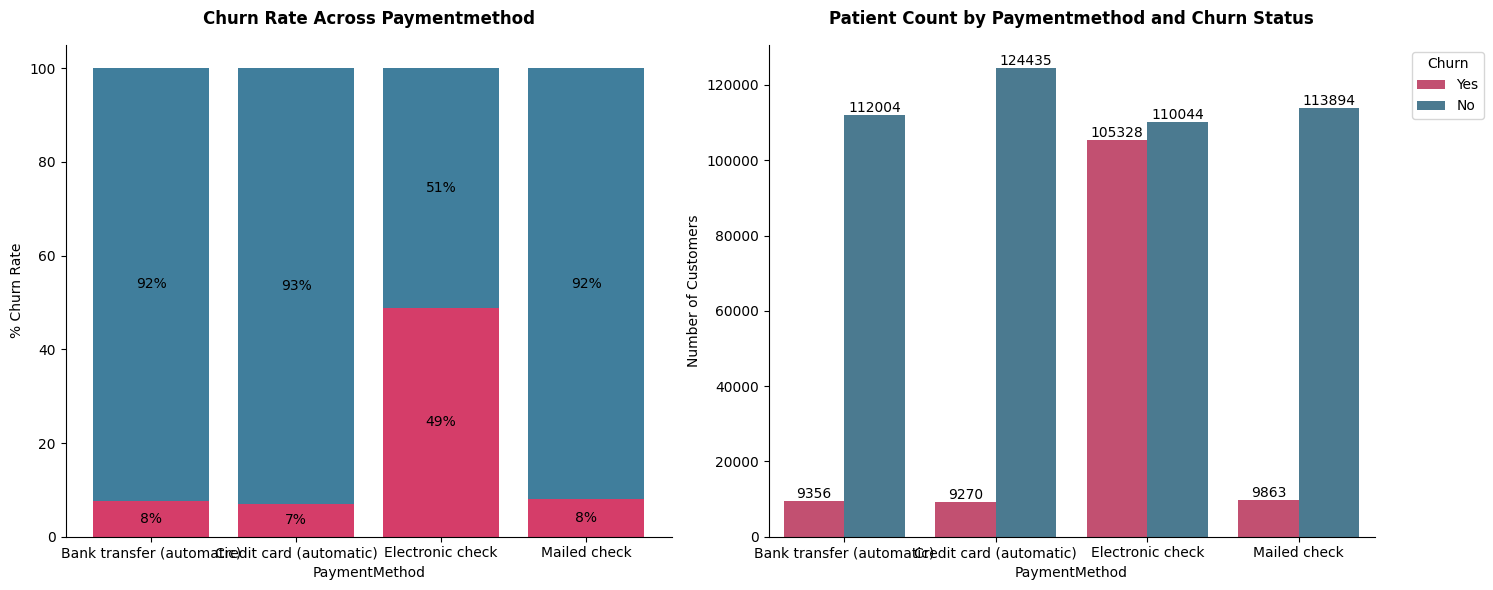

2026-03-02 09:19:26 | INFO     | Chi-Square Test of Independence: 'PaymentMethod' vs. 'Churn'...
2026-03-02 09:19:26 | INFO     | Chi-squared statistic: 134817.827
2026-03-02 09:19:26 | INFO     | Degrees of freedom: 3
2026-03-02 09:19:26 | INFO     | p-value: 0.000000
2026-03-02 09:19:26 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-03-02 09:19:26 | INFO     | Variables 'PaymentMethod' and 'Churn' are statistically associated.
2026-03-02 09:19:26 | DEBUG    | Displaying standardized residuals heatmap.


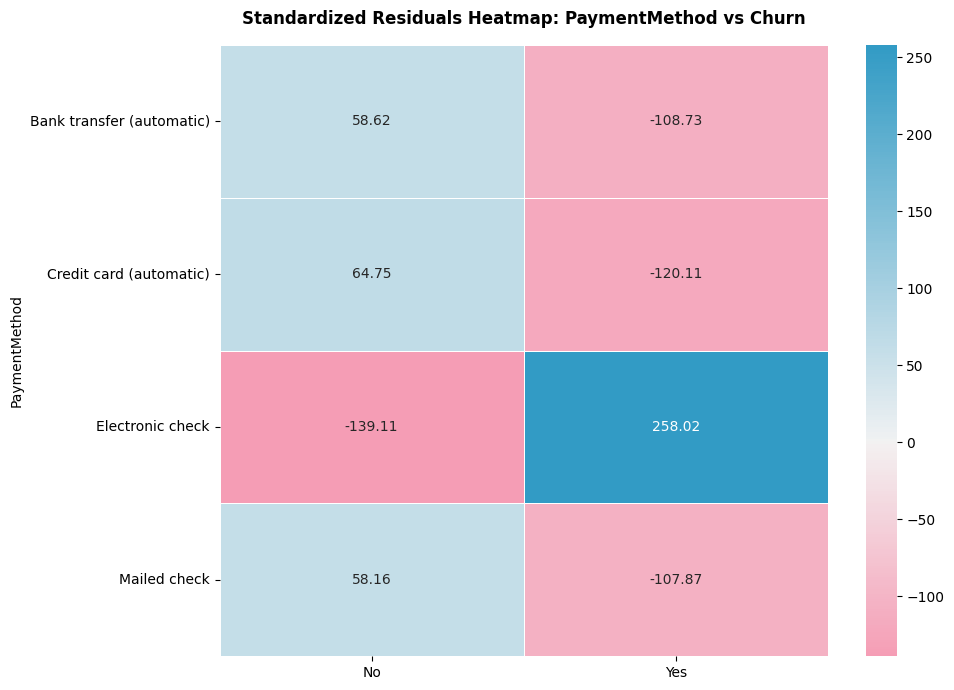

In [20]:
def bivariate_percent_plot(cat: str, target_feature: str,
                           df: pd.DataFrame, figsize=(15, 6), order=None) -> None:
    """
    Plot the relationship between a categorical feature and the target variable.

    This function displays:
    - A stacked bar chart showing percentage distribution of target classes.
    - A count plot showing absolute frequencies.
    - A Chi-Square test for feature–target dependence.

    Parameters
    ----------
    cat : str
        Categorical feature name.

    target_feature : str
        Target variable name.

    df : pd.DataFrame
        Input dataset.

    figsize : tuple, optional
        Figure size (width, height). Default is (15, 6).

    order : list, optional
        Custom order of categories on x-axis.

    Returns
    -------
    None
    """

    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat.title()} by {target_feature.title()}</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)

    # Data processing
    grouped = df.groupby([cat, target_feature]).size().unstack(fill_value=0)

    # Define a fixed hue order (adjust if needed)
    target_order = [c for c in ["Yes", "No"] if c in grouped.columns]

    # Fallback if the labels are 0/1 or have different names
    if not target_order:
        target_order = list(grouped.columns)

    # Calculate percentages row-wise and reorder columns by target_order
    percentages = grouped.div(grouped.sum(axis=1), axis=0)[target_order] * 100

    # Define X-axis category order
    if order is not None:
        percentages = percentages.loc[order]
        labels = order
    else:
        labels = percentages.index.tolist()

    # Consistent color palette for both charts
    base_colors = color(n_colors=len(target_order))
    color_map = dict(zip(target_order, base_colors))

    # Plot 1: Stacked bar chart (percentage)
    bottom = np.zeros(len(percentages))
    for cls in target_order:
        ax[0].bar(percentages.index.astype(str), percentages[cls].values, bottom=bottom,
                  label=cls, color=color_map[cls])
        bottom += percentages[cls].values

    # Add percentage labels
    for container in ax[0].containers:
        ax[0].bar_label(container, fmt="%1.0f%%", label_type="center",
                        fontsize=10, color="black")

    ax[0].set_title(f"Churn Rate Across {cat.replace('_', ' ').title()}", fontsize=12, weight="bold", pad=15)
    ax[0].set_xlabel(f"{cat}", fontsize=10)
    ax[0].set_ylabel(f"% {target_feature} Rate", fontsize=10)
    sns.despine(left=False, bottom=False, ax=ax[0])
    ax[0].legend().remove()

    # Plot 2: Count plot (using same color_map + hue_order)
    sns.countplot(data=df, hue=target_feature, x=cat,
                  order=labels, hue_order=target_order,
                  palette=color_map, ax=ax[1])

    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge",
                        fontsize=10, color="black")

    ax[1].set_title(f"Patient Count by {cat.replace('_', ' ').title()} and Churn Status", fontsize=12, weight="bold", pad=15)
    ax[1].set_xlabel(f"{cat}", fontsize=10)
    ax[1].set_ylabel("Number of Customers", fontsize=10)
    ax[1].legend(title=target_feature, bbox_to_anchor=(1.05, 1), loc="upper left")
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    # Chi-Square Test
    cal_ChiSquare(cat_feature=cat, target_feature=target_feature, df=df, show_residuals=True)

# Run for all categorical features
for feature in cat_features:
    bivariate_percent_plot(cat=feature, target_feature=config.target_feature,
                           df=df_train)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Insight: Categorical Features vs Churn
</div>

<div style="line-height:1.8;">

<p><b><code>Gender</code></b><br>
Although statistically significant, the effect size is weak. Females are slightly overrepresented among churned customers, while males are slightly overrepresented among retained customers.</p>

<p><b><code>SeniorCitizen</code></b><br>
Senior citizens exhibit a substantially higher churn rate (~50%) compared to non-seniors (~19%), indicating a strong predictive relationship.</p>

<p><b><code>Partner</code></b><br>
Customers without a partner are significantly more likely to churn, whereas those with a partner show stronger retention behavior.</p>

<p><b><code>Dependents</code></b><br>
Customers without dependents are more likely to churn, while those with dependents demonstrate stronger retention.</p>

<p><b><code>PhoneService</code></b><br>
Customers with phone service show a slightly higher churn rate (23% vs 17%), suggesting limited retention impact.</p>

<p><b><code>MultipleLines</code></b><br>
Customers with multiple lines are more likely to churn, indicating a positive association with churn risk.</p>

<p><b><code>InternetService</code></b><br>
Fiber optic customers exhibit significantly higher churn, while DSL and customers without internet service are more likely to stay. This is one of the strongest churn-related categorical factors.</p>

<p><b><code>OnlineSecurity</code></b><br>
Customers without online security are far more likely to churn, suggesting security add-ons strongly reduce churn risk.</p>

<p><b><code>OnlineBackup</code></b><br>
OnlineBackup is a meaningful retention driver — customers without backup service exhibit significantly higher churn risk.</p>

<p><b><code>DeviceProtection</code></b><br>
Absence of device protection is associated with higher churn, indicating protection services support retention.</p>

<p><b><code>TechSupport</code></b><br>
Customers without tech support are significantly more likely to churn, making this a strong retention-related feature.</p>

<p><b><code>StreamingTV</code></b><br>
Streaming TV subscribers show higher churn rates, suggesting entertainment add-ons may correlate with higher churn risk rather than retention.</p>

<p><b><code>StreamingMovies</code></b><br>
Streaming Movies subscribers also show higher churn likelihood, reinforcing the entertainment-related churn pattern.</p>

<p><b><code>Contract</code></b><br>
Month-to-month contracts show dramatically higher churn, while one-year and especially two-year contracts significantly reduce churn. Contract length is the strongest retention driver.</p>

<p><b><code>PaperlessBilling</code></b><br>
Customers using paperless billing are more likely to churn, indicating an association with higher churn risk.</p>

<p><b><code>PaymentMethod</code></b><br>
Electronic check users exhibit significantly higher churn, while automatic payment methods (bank transfer or credit card) are associated with lower churn risk.</p>

</div>

<div style="
    margin-top: 18px;
    padding: 12px 16px;
    background-color: rgba(249, 231, 159, 0.15);
    border-left: 4px solid #f9e79f;
    border-radius: 6px;
    font-size: 15px;
">
<b>Key Insight:</b> Contract type, senior status, payment method, and security/support add-ons emerge as the strongest categorical predictors of churn, while demographic factors such as gender exhibit comparatively weak effects.
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
📊 Consolidated Feature Impact Summary
</div>

<table style="
    width:100%;
    border-collapse: collapse;
    font-size: 14px;
">

<thead>
<tr style="background-color: rgba(249,231,159,0.15);">
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Feature</th>
<th style="padding:10px; border:1px solid rgba(255,255,255,0.2); text-align:left;">Summary</th>
</tr>
</thead>

<tbody>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>tenure</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Customers who churn have <b>significantly shorter tenure</b>, indicating churn risk is concentrated in the early lifecycle stage.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>MonthlyCharges</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Churned customers show <b>slightly higher monthly charges</b>, though the practical effect size remains small.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>TotalCharges</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Lower total charges among churned customers mainly reflect shorter tenure rather than lower spending behavior.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>gender</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Statistically significant but <b>very weak practical impact</b>; females are slightly overrepresented among churned customers.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>SeniorCitizen</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Strong demographic risk factor</b> — senior citizens exhibit substantially higher churn rates.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Partner</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Customers without a partner are <b>significantly more likely to churn</b>, indicating household stability influences retention.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Dependents</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Customers without dependents show <b>markedly higher churn</b>, reinforcing family attachment as a stabilizing factor.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>PhoneService</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Associated with slightly higher churn, but predictive strength is limited.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>MultipleLines</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Customers with multiple lines demonstrate <b>moderately higher churn risk</b>, possibly linked to higher service costs.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>InternetService</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>One of the strongest service-related predictors</b>; fiber optic customers show significantly higher churn.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>OnlineSecurity</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Strong retention driver</b> — absence significantly increases churn risk.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>OnlineBackup</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Meaningful retention factor</b> — customers without OnlineBackup exhibit significantly higher churn, while those with backup service tend to stay.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>DeviceProtection</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Protection add-ons are <b>associated with lower churn risk</b>.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>TechSupport</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Very strong retention factor</b> — lack of support strongly increases churn probability.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>StreamingTV</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Streaming subscribers show moderately higher churn, suggesting limited retention impact.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>StreamingMovies</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Similar to StreamingTV, entertainment add-ons correlate with higher churn risk.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Contract</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Strongest retention driver</b> — long-term contracts dramatically reduce churn.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>PaperlessBilling</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);">Paperless billing users exhibit higher churn risk.</td>
</tr>

<tr>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>PaymentMethod</b></td>
<td style="padding:10px; border:1px solid rgba(255,255,255,0.2);"><b>Highly influential behavioral predictor</b> — electronic check users churn far more than automatic payment users.</td>
</tr>

</tbody>
</table>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Baseline Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Baseline Preprocessing
    </h1>
</div>

In [21]:
logger.info(f"[1/5] Combining competition train with original dataset...")
# Combining competition train with original dataset
df_train_combined = pd.concat([df_train, df_original], ignore_index=True)

# Force Churn to int after concat (prevents mixed str/int dtype)
df_train_combined[config.target_feature] = df_train_combined[config.target_feature].replace({"Yes": 1, "No": 0})
df_train_combined[config.target_feature] = df_train_combined[config.target_feature].astype(int)

# Fill TotalCharges NaN from original (whitespace rows)
tc_median = df_train_combined["TotalCharges"].median()
df_train_combined["TotalCharges"].fillna(tc_median, inplace=True)

logger.info(f"TotalCharges NaN → filled with median: {tc_median:.2f}")
logger.info(f"Combined shape: {df_train_combined.shape}")
logger.info(f"Churn rate: {df_train_combined[config.target_feature].mean()*100:.2f}%")
logger.info("*" * 80)

logger.info("[2/5] Encoding categorical features...")
all_data = pd.concat([df_train_combined.drop(config.target_feature, axis=1), df_test], ignore_index=True)

label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col].astype(str))
    label_encoders[col] = le
logger.info(f"Encoded {len(cat_features)} categorical features: {cat_features}")
logger.info("*" * 80)

logger.info(f"[3/5] Splitting back into train and test...")
df_train_encoded = all_data.iloc[:len(df_train_combined)].copy()
df_test_encoded  = all_data.iloc[len(df_train_combined):].copy()

df_train_encoded[config.target_feature] = df_train_combined[config.target_feature].values
logger.info("*" * 80)

logger.info(f"[4/5] Preparing final feature matrices...")
all_features = num_features + cat_features
X_train = df_train_encoded[all_features]
y_train = df_train_encoded[config.target_feature].astype(int)
X_test  = df_test_encoded[all_features]

logger.info(f"X_train : {X_train.shape}")
logger.info(f"y_train : {y_train.shape}  |  classes: {sorted(y_train.unique())}")
logger.info(f"X_test  : {X_test.shape}")
logger.info("*" * 80)

logger.info(f"[5/5] Reduce memory for train and test...")
dataset_encoded = [
    ("Train Set", X_train),
    ("Test Set", X_test)
]

for name, df in dataset_encoded:
    logger.info(f"Processing {name}")
    logger.info(f"{name} memory before: {config.memory_report(df):.2f} MB")

    config.reduce_mem_usage(all_features, df)

    logger.info(f"{name} memory after: {config.memory_report(df):.2f} MB")
logger.info("*" * 80)

logger.info(f"Final feature count : {X_train.shape[1]}")
logger.info(f"Feature list: {X_train.columns.tolist()}")

logger.info("*" * 80)
logger.info("BASELINE PREPROCESSING COMPLETED")
logger.info("*" * 80)

2026-03-02 09:19:27 | INFO     | [1/5] Combining competition train with original dataset...
2026-03-02 09:19:27 | INFO     | TotalCharges NaN → filled with median: 1432.65
2026-03-02 09:19:27 | INFO     | Combined shape: (601237, 20)
2026-03-02 09:19:27 | INFO     | Churn rate: 22.57%
2026-03-02 09:19:27 | INFO     | ********************************************************************************
2026-03-02 09:19:27 | INFO     | [2/5] Encoding categorical features...
2026-03-02 09:19:29 | INFO     | Encoded 16 categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
2026-03-02 09:19:29 | INFO     | ********************************************************************************
2026-03-02 09:19:29 | INFO     | [3/5] Splitting back into train and test...
2026-03-02 09:

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

In [22]:
def plot_oof_metrics(y_true, oof_preds, fold_preds, threshold=0.5):
    """
    Plot ROC, Precision-Recall curves (by fold) and Confusion Matrix (OOF)

    Parameters
    ----------
    y_true : array-like
        Ground truth labels

    oof_preds : array-like
        Out-of-fold predicted probabilities

    fold_preds : list of tuples
        Each element: (y_val, val_pred) for each fold

    threshold : float, default=0.5
        Threshold for confusion matrix
    """

    roc_curves = []
    pr_curves = []
    auc_values = []
    ap_values = []

    # ================= Collect metrics per fold =================
    for i, (y_val, val_pred) in enumerate(fold_preds):
        # ROC
        fpr, tpr, _ = roc_curve(y_val, val_pred)
        roc_curves.append((fpr, tpr))

        auc = roc_auc_score(y_val, val_pred)
        auc_values.append(auc)

        # PR
        precision, recall, _ = precision_recall_curve(y_val, val_pred)
        pr_curves.append((recall, precision))

        ap = average_precision_score(y_val, val_pred)
        ap_values.append(ap)

    # ================= Plot =================
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # ---------------- ROC ----------------
    ax = axes[0, 0]

    for i, (fpr, tpr) in enumerate(roc_curves):
        ax.plot(fpr, tpr, label=f"Fold {i+1} AUC = {auc_values[i]:.4f}")

    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_title("ROC Curve (Each Fold)", weight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()
    ax.grid(True)

    # ---------------- PR ----------------
    ax = axes[0, 1]

    for i, (recall, precision) in enumerate(pr_curves):
        ax.plot(recall, precision, label=f"Fold {i+1} AP = {ap_values[i]:.4f}")

    ax.set_title("Precision–Recall Curve (Each Fold)", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

    # ---------------- Confusion Matrix ----------------
    ax = axes[1, 0]

    y_pred_label = (oof_preds >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_label)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix (Threshold = {threshold})", weight="bold", pad=15, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Empty plot
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

2026-03-02 09:19:30 | INFO     | Training XGBoost with 5-Fold Stratified CV...
2026-03-02 09:19:30 | INFO     | ********************************************************************************
2026-03-02 09:19:50 | INFO     | Fold 1 - AUC: 0.916278
2026-03-02 09:20:09 | INFO     | Fold 2 - AUC: 0.916713
2026-03-02 09:20:28 | INFO     | Fold 3 - AUC: 0.914275
2026-03-02 09:20:47 | INFO     | Fold 4 - AUC: 0.915640
2026-03-02 09:21:06 | INFO     | Fold 5 - AUC: 0.916681
2026-03-02 09:21:06 | INFO     | ********************************************************************************
2026-03-02 09:21:06 | INFO     | XGBoost OOF AUC: 0.915917 ± 0.000908
2026-03-02 09:21:06 | INFO     | ********************************************************************************


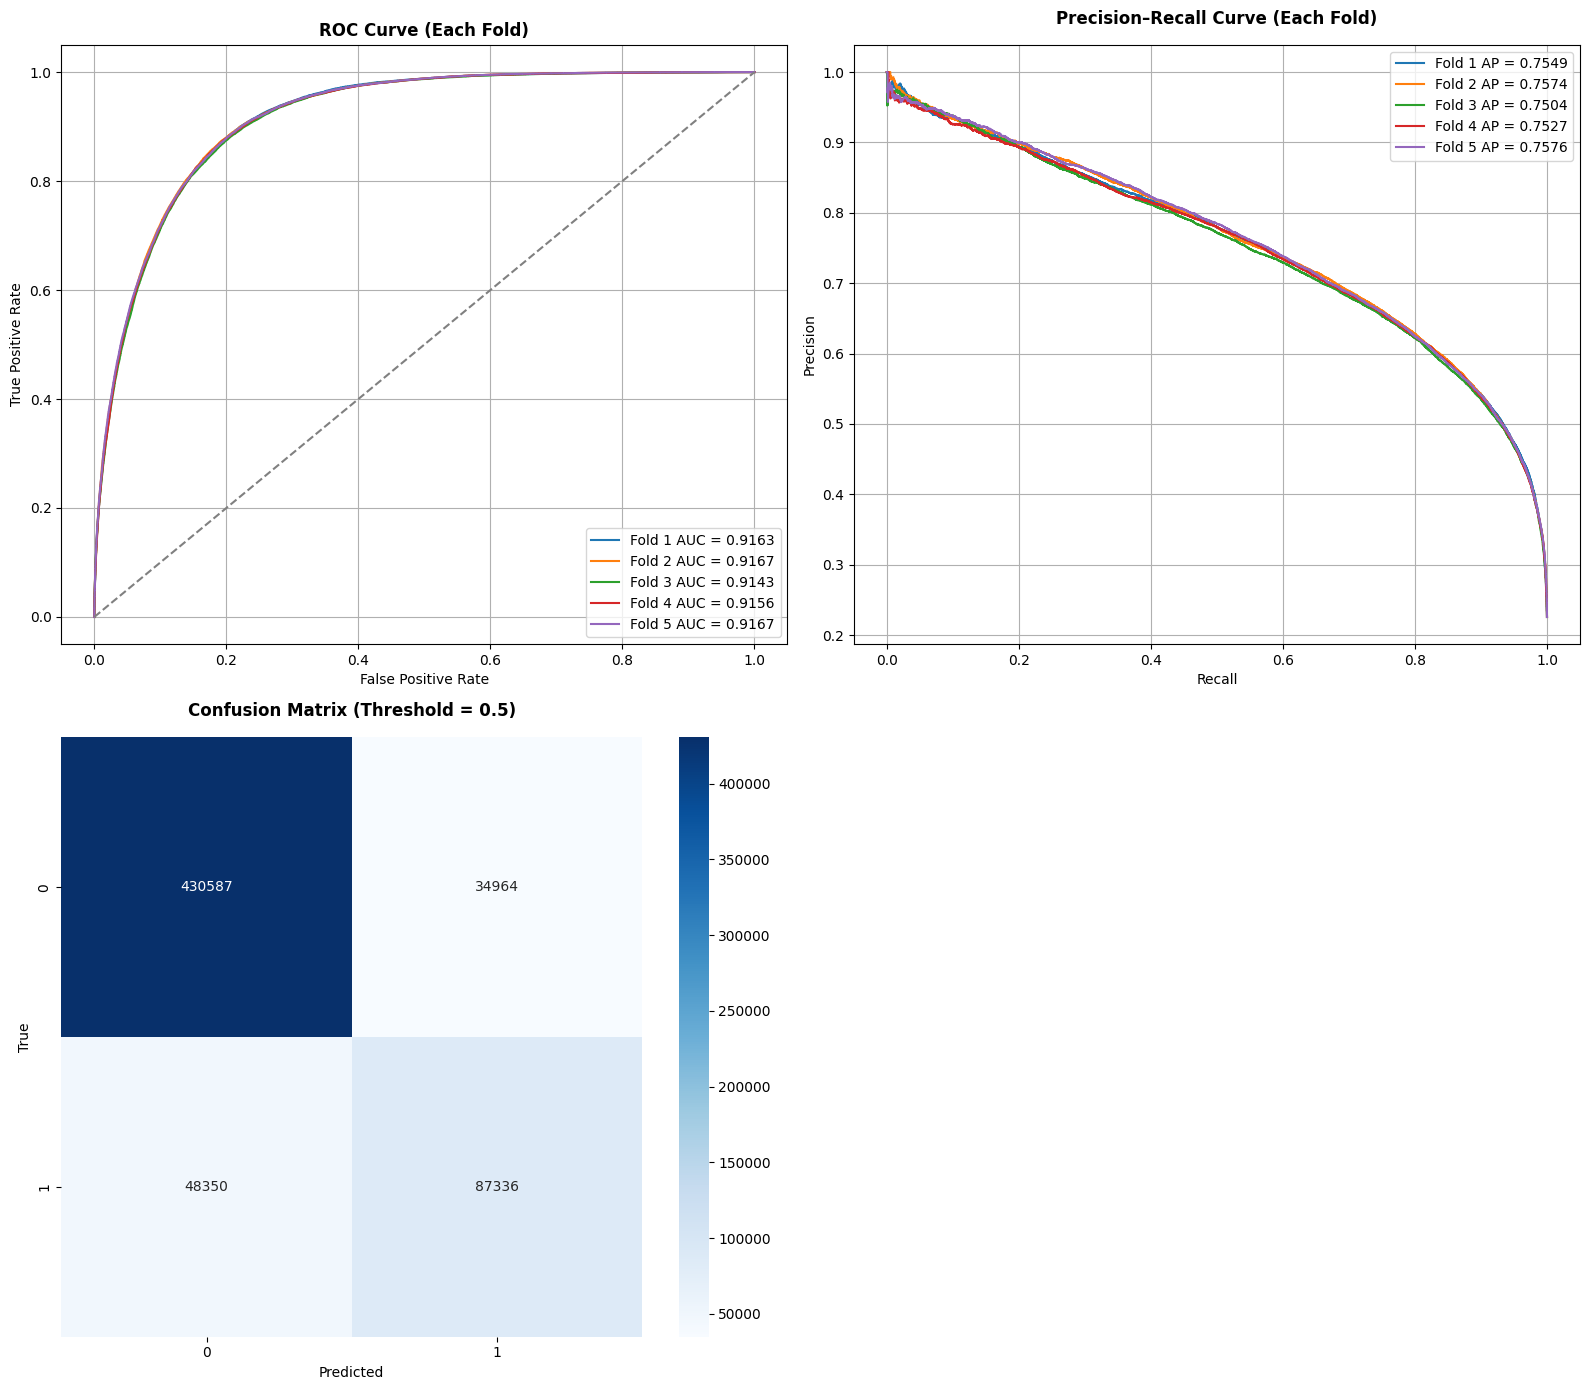

In [23]:
logger.info("Training XGBoost with 5-Fold Stratified CV...")
logger.info("*" * 80)

# Stratified K-Fold to preserve class distribution across folds
skf = StratifiedKFold(
    n_splits=config.n_split_kfold,
    shuffle=True,
    random_state=config.random_state
)

# Initialize containers
xgb_oof_preds = np.zeros(len(X_train))   # Out-of-fold predictions (for full train set)
xgb_test_preds = np.zeros(len(X_test))   # Averaged test predictions across folds
xgb_fold_scores = []                     # Store AUC score for each fold
xgb_models = []                          # Store trained models per fold
# Store predictions of each fold for later visualization/analysis
# Each element: (true_labels, predicted_probs)
fold_preds = []

# Cross-validation loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    
    # Split into training and validation subsets for this fold
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Initialize XGBoost classifier with predefined hyperparameters
    model = XGBClassifier(**config.xgb_params)
    
    # Train model with validation set for monitoring
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],  # Used for evaluation during training
        verbose=False
    )
    
    # Generate probability predictions for validation fold
    val_preds = model.predict_proba(X_val)[:, 1]
    
    # Store OOF predictions in correct validation indices
    xgb_oof_preds[val_idx] = val_preds

    # Store fold predictions for plotting
    fold_preds.append((y_val.values, val_preds))
    
    # Compute ROC-AUC score for this fold
    fold_score = roc_auc_score(y_val, val_preds)
    xgb_fold_scores.append(fold_score)
    
    # Generate test predictions for this fold
    # Average them later to reduce variance
    test_preds = model.predict_proba(X_test)[:, 1]
    xgb_test_preds += test_preds / config.n_split_kfold
    
    # Save trained model for potential ensemble or analysis
    xgb_models.append(model)
    
    logger.info(f"Fold {fold} - AUC: {fold_score:.6f}")

# Compute overall cross-validated performance
xgb_mean_score = np.mean(xgb_fold_scores)
xgb_std_score = np.std(xgb_fold_scores)

logger.info("*" * 80)
logger.info(f"XGBoost OOF AUC: {xgb_mean_score:.6f} ± {xgb_std_score:.6f}")
logger.info("*" * 80)

# Visualize OOF predictions and fold performance metrics
# y_true: actual training labels
# oof_preds: full OOF probability predictions
# fold_preds: list of fold-level AUC scores
plot_oof_metrics(
    y_true=y_train.values,
    oof_preds=xgb_oof_preds,
    fold_preds=fold_preds,
    threshold=config.threshold
)

2026-03-02 09:21:08 | INFO     | Training LightGBM with 5-Fold Stratified CV...
2026-03-02 09:21:08 | INFO     | ********************************************************************************
2026-03-02 09:21:43 | INFO     | Fold 1 - AUC: 0.915634
2026-03-02 09:22:24 | INFO     | Fold 2 - AUC: 0.916149
2026-03-02 09:23:03 | INFO     | Fold 3 - AUC: 0.913871
2026-03-02 09:23:33 | INFO     | Fold 4 - AUC: 0.914938
2026-03-02 09:24:15 | INFO     | Fold 5 - AUC: 0.916099
2026-03-02 09:24:15 | INFO     | ********************************************************************************
2026-03-02 09:24:15 | INFO     | LightGBM OOF AUC: 0.915338 ± 0.000853
2026-03-02 09:24:15 | INFO     | ********************************************************************************


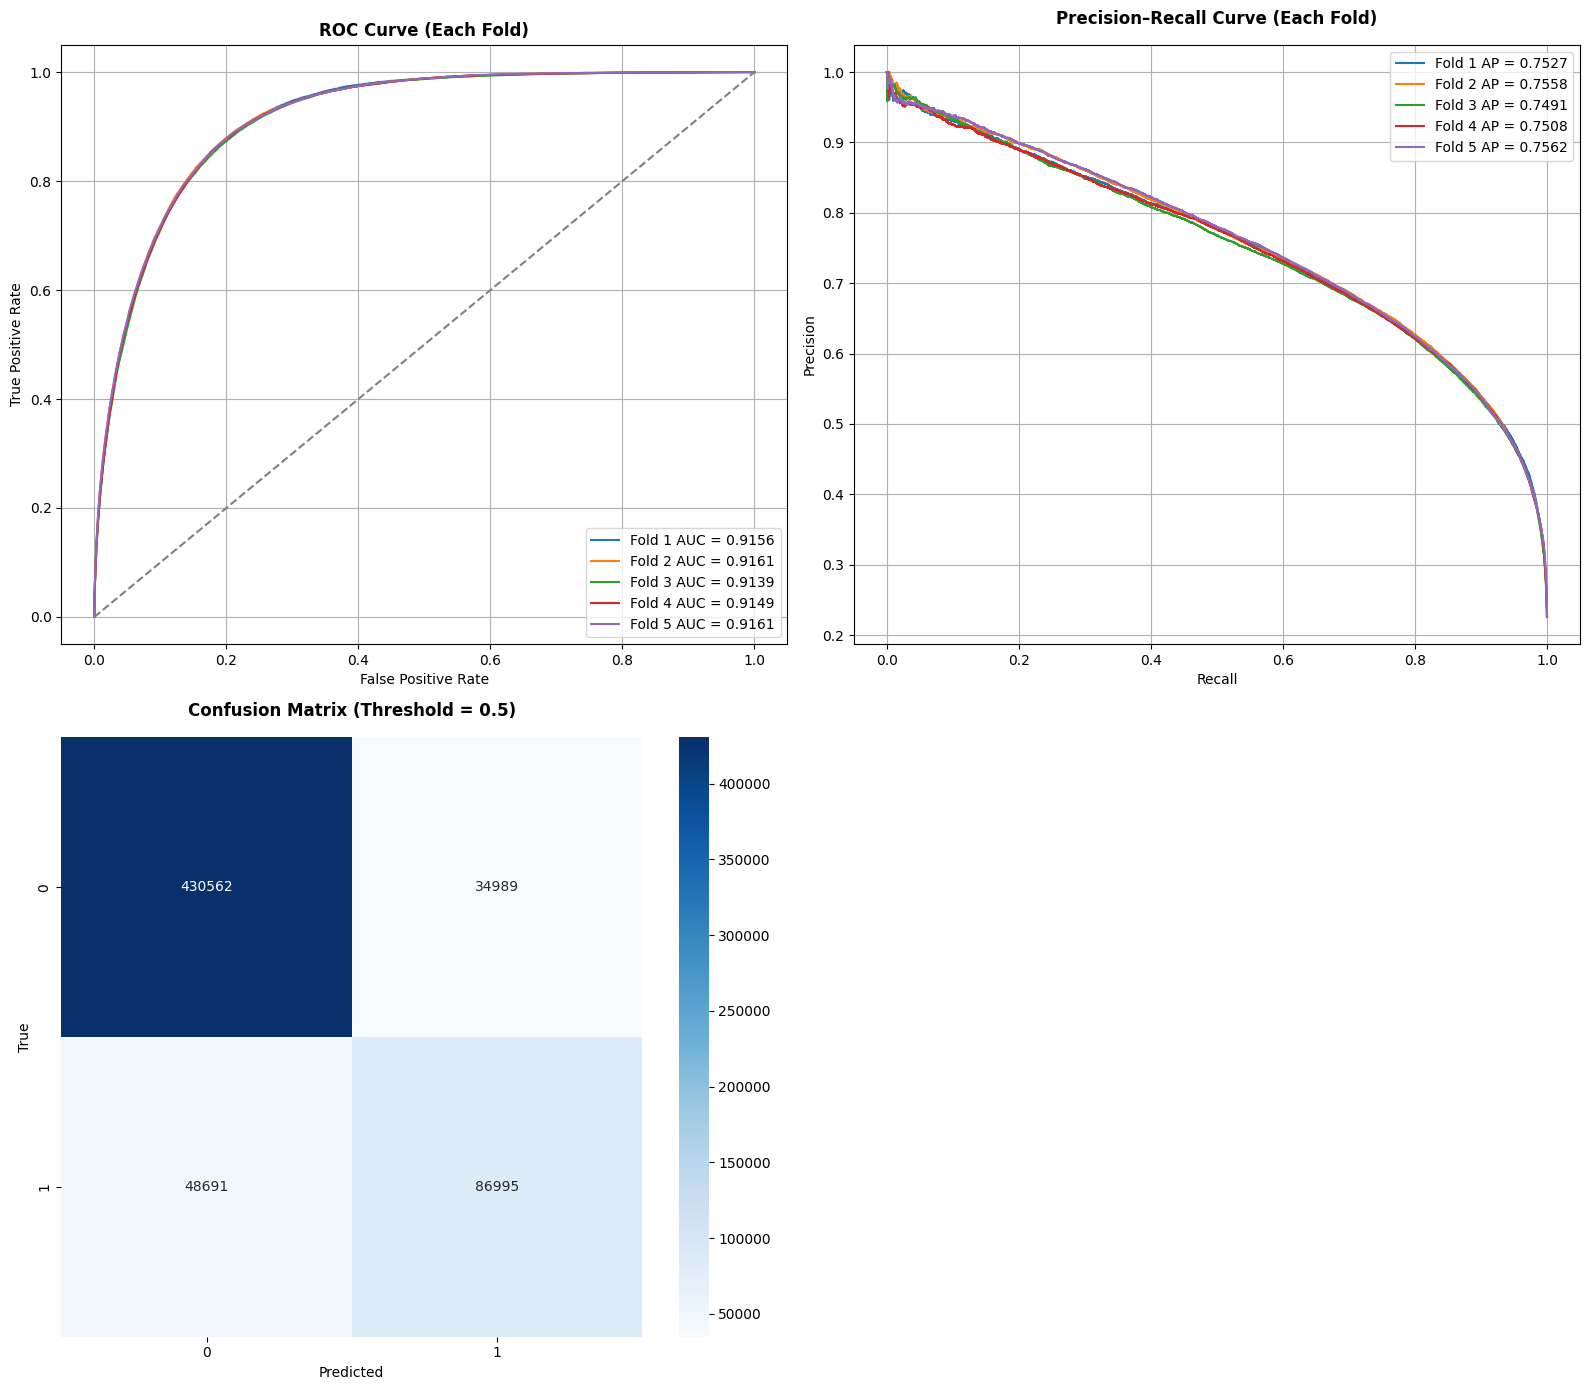

In [24]:
logger.info("Training LightGBM with 5-Fold Stratified CV...")
logger.info("*" * 80)

lgb_oof_preds = np.zeros(len(X_train))
lgb_test_preds = np.zeros(len(X_test))
lgb_fold_scores = []
lgb_models = []

# Store predictions of each fold for later visualization/analysis
lgbm_fold_preds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

     # Split into training and validation subsets for this fold
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Initialize XGBoost classifier with predefined hyperparameters
    model = lgb.LGBMClassifier(**config.lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    # Generate probability predictions for validation fold
    val_preds = model.predict_proba(X_val)[:, 1]

     # Store OOF predictions in correct validation indices
    lgb_oof_preds[val_idx] = val_preds

    # Store fold predictions for plotting
    lgbm_fold_preds.append((y_val.values, val_preds))

    # Store fold predictions for plotting
    fold_score = roc_auc_score(y_val, val_preds)
    lgb_fold_scores.append(fold_score)

    # Generate test predictions for this fold
    # Average them later to reduce variance
    test_preds = model.predict_proba(X_test)[:, 1]
    lgb_test_preds += test_preds / config.n_split_kfold

    # Save trained model for potential ensemble or analysis
    lgb_models.append(model)

    logger.info(f"Fold {fold} - AUC: {fold_score:.6f}")

lgb_mean_score = np.mean(lgb_fold_scores)
lgb_std_score = np.std(lgb_fold_scores)

logger.info("*" * 80)
logger.info(f"LightGBM OOF AUC: {lgb_mean_score:.6f} ± {lgb_std_score:.6f}")
logger.info("*" * 80)

# Visualize OOF predictions and fold performance metrics
plot_oof_metrics(
    y_true=y_train.values,
    oof_preds=lgb_oof_preds,
    fold_preds=lgbm_fold_preds,
    threshold=config.threshold
)

2026-03-02 09:24:17 | INFO     | Training CatBoost with 5-Fold Stratified CV...
2026-03-02 09:24:17 | INFO     | ********************************************************************************
2026-03-02 09:26:28 | INFO     | Fold 1 - AUC: 0.915642
2026-03-02 09:28:22 | INFO     | Fold 2 - AUC: 0.915996
2026-03-02 09:30:13 | INFO     | Fold 3 - AUC: 0.913873
2026-03-02 09:32:05 | INFO     | Fold 4 - AUC: 0.915022
2026-03-02 09:33:57 | INFO     | Fold 5 - AUC: 0.915972
2026-03-02 09:33:57 | INFO     | ********************************************************************************
2026-03-02 09:33:57 | INFO     | CatBoost OOF AUC: 0.915301 ± 0.000796
2026-03-02 09:33:57 | INFO     | ********************************************************************************


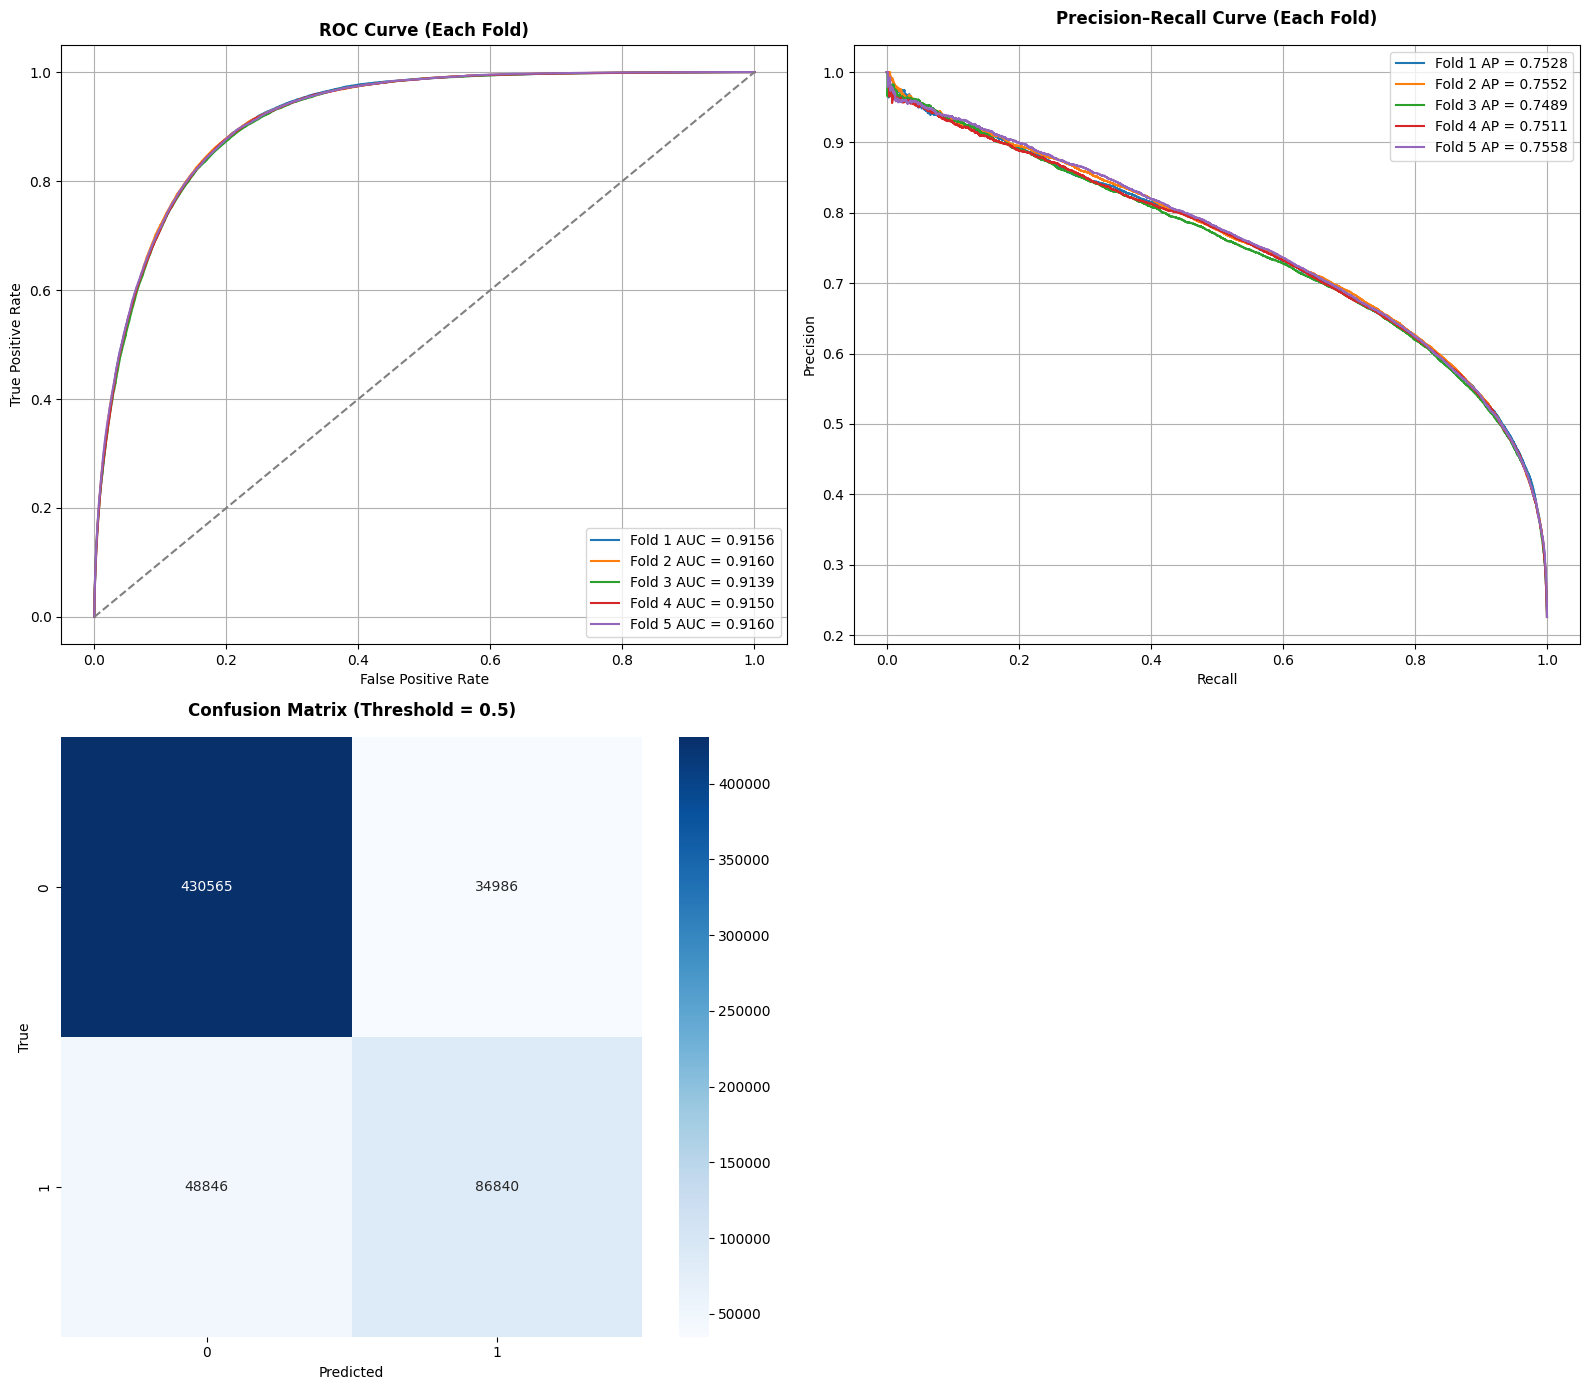

In [25]:
logger.info("Training CatBoost with 5-Fold Stratified CV...")
logger.info("*" * 80)

cat_oof_preds = np.zeros(len(X_train))
cat_test_preds = np.zeros(len(X_test))
cat_fold_scores = []
cat_models = []

# Store predictions of each fold for later visualization/analysis
cat_fold_preds = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

    # Split into training and validation subsets for this fold
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Initialize XGBoost classifier with predefined hyperparameters
    model = CatBoostClassifier(**config.cat_params)

    # Train model with validation set for monitoring
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )

    # Generate probability predictions for validation fold
    val_preds = model.predict_proba(X_val)[:, 1]

    # Store OOF predictions in correct validation indices
    cat_oof_preds[val_idx] = val_preds

    # Store fold predictions for plotting
    cat_fold_preds.append((y_val.values, val_preds))

    # Compute ROC-AUC score for this fold
    fold_score = roc_auc_score(y_val, val_preds)
    cat_fold_scores.append(fold_score)

    # Generate test predictions for this fold
    # Average them later to reduce variance
    test_preds = model.predict_proba(X_test)[:, 1]
    cat_test_preds += test_preds / config.n_split_kfold

    # Save trained model for potential ensemble or analysis
    cat_models.append(model)

    logger.info(f"Fold {fold} - AUC: {fold_score:.6f}")

cat_mean_score = np.mean(cat_fold_scores)
cat_std_score = np.std(cat_fold_scores)

logger.info("*" * 80)
logger.info(f"CatBoost OOF AUC: {cat_mean_score:.6f} ± {cat_std_score:.6f}")
logger.info("*" * 80)

# Visualize OOF predictions and fold performance metrics
plot_oof_metrics(
    y_true=y_train.values,
    oof_preds=cat_oof_preds,
    fold_preds=cat_fold_preds,
    threshold=config.threshold
)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>

In [26]:
results_df = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost"],
    "Mean CV Score": [xgb_mean_score, lgb_mean_score, cat_mean_score],
    "Std": [xgb_std_score, lgb_std_score, cat_std_score]
})

results_df = results_df.sort_values("Mean CV Score", ascending=False)
display(results_df.style.background_gradient(subset=["Mean CV Score"], cmap="Blues"))

,Model,Mean CV Score,Std
0,XGBoost,0.915917,0.000908
1,LightGBM,0.915338,0.000853
2,CatBoost,0.915301,0.000796


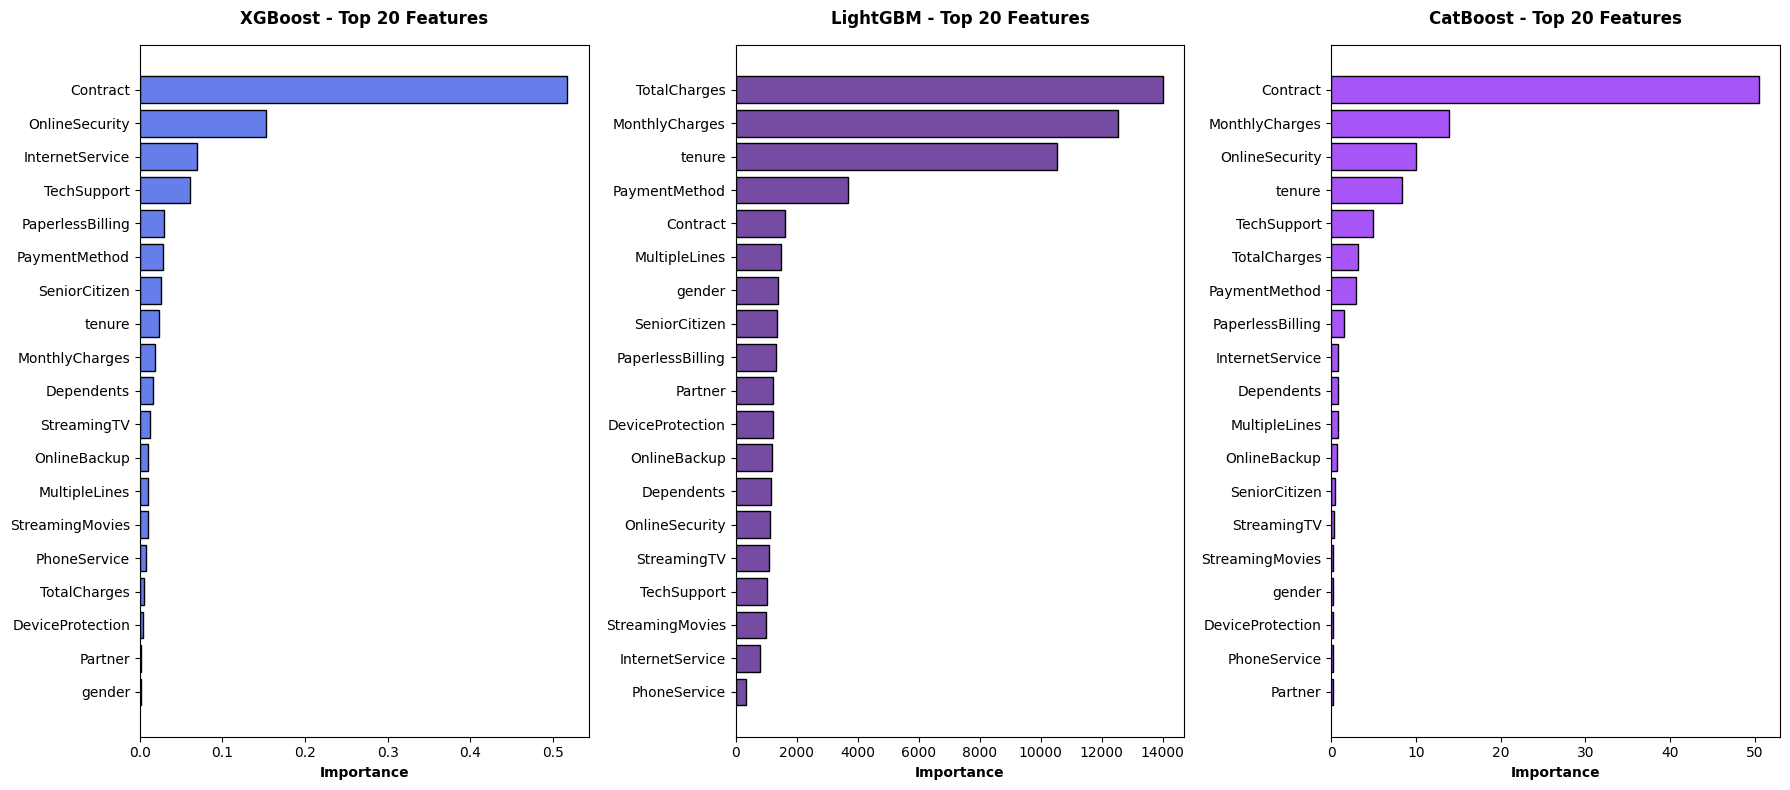

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_models[1].feature_importances_
}).sort_values("importance", ascending=False).head(20)

ax = axes[0]
ax.barh(range(len(xgb_importance)), xgb_importance["importance"].values,
        color=config.COLORS[0], edgecolor="black", linewidth=1)
ax.set_yticks(range(len(xgb_importance)))
ax.set_yticklabels(xgb_importance["feature"])
ax.set_xlabel("Importance", fontweight="bold")
ax.set_title("XGBoost - Top 20 Features", fontweight="bold", pad=15, fontsize=12)
ax.invert_yaxis()

lgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_models[1].feature_importances_
}).sort_values("importance", ascending=False).head(20)

ax = axes[1]
ax.barh(range(len(lgb_importance)), lgb_importance["importance"].values,
        color=config.COLORS[1], edgecolor="black", linewidth=1)
ax.set_yticks(range(len(lgb_importance)))
ax.set_yticklabels(lgb_importance["feature"])
ax.set_xlabel("Importance", fontweight="bold")
ax.set_title("LightGBM - Top 20 Features", fontweight="bold", pad=15, fontsize=12)
ax.invert_yaxis()

cat_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_models[4].feature_importances_
}).sort_values("importance", ascending=False).head(20)

ax = axes[2]
ax.barh(range(len(cat_importance)), cat_importance["importance"].values,
        color=config.COLORS[2], edgecolor="black", linewidth=1)
ax.set_yticks(range(len(cat_importance)))
ax.set_yticklabels(cat_importance["feature"])
ax.set_xlabel("Importance", fontweight="bold")
ax.set_title("CatBoost - Top 20 Features", fontweight="bold", pad=15, fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
xgb_binary = (xgb_oof_preds >= config.threshold).astype(int)
lgb_binary = (lgb_oof_preds >= config.threshold).astype(int)
cat_binary = (cat_oof_preds >= config.threshold).astype(int)

logger.info("XGBoost Classification Report:")
logger.info("\n" + classification_report(y_train, xgb_binary, target_names=['No Churn', 'Churn']))
logger.info("*" * 80)

logger.info("LightGBM Classification Report:")
logger.info("\n" + classification_report(y_train, lgb_binary, target_names=['No Churn', 'Churn']))
logger.info("*" * 80)

logger.info("CatBoost Classification Report:")
logger.info("\n" + classification_report(y_train, cat_binary, target_names=['No Churn', 'Churn']))
logger.info("*" * 80)

2026-03-02 09:34:00 | INFO     | XGBoost Classification Report:
2026-03-02 09:34:00 | INFO     | 
              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91    465551
       Churn       0.71      0.64      0.68    135686

    accuracy                           0.86    601237
   macro avg       0.81      0.78      0.79    601237
weighted avg       0.86      0.86      0.86    601237

2026-03-02 09:34:00 | INFO     | ********************************************************************************
2026-03-02 09:34:00 | INFO     | LightGBM Classification Report:
2026-03-02 09:34:00 | INFO     | 
              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91    465551
       Churn       0.71      0.64      0.68    135686

    accuracy                           0.86    601237
   macro avg       0.81      0.78      0.79    601237
weighted avg       0.86      0.86      0.86    601237

2026-03-02 09:34:00 | INFO     | **

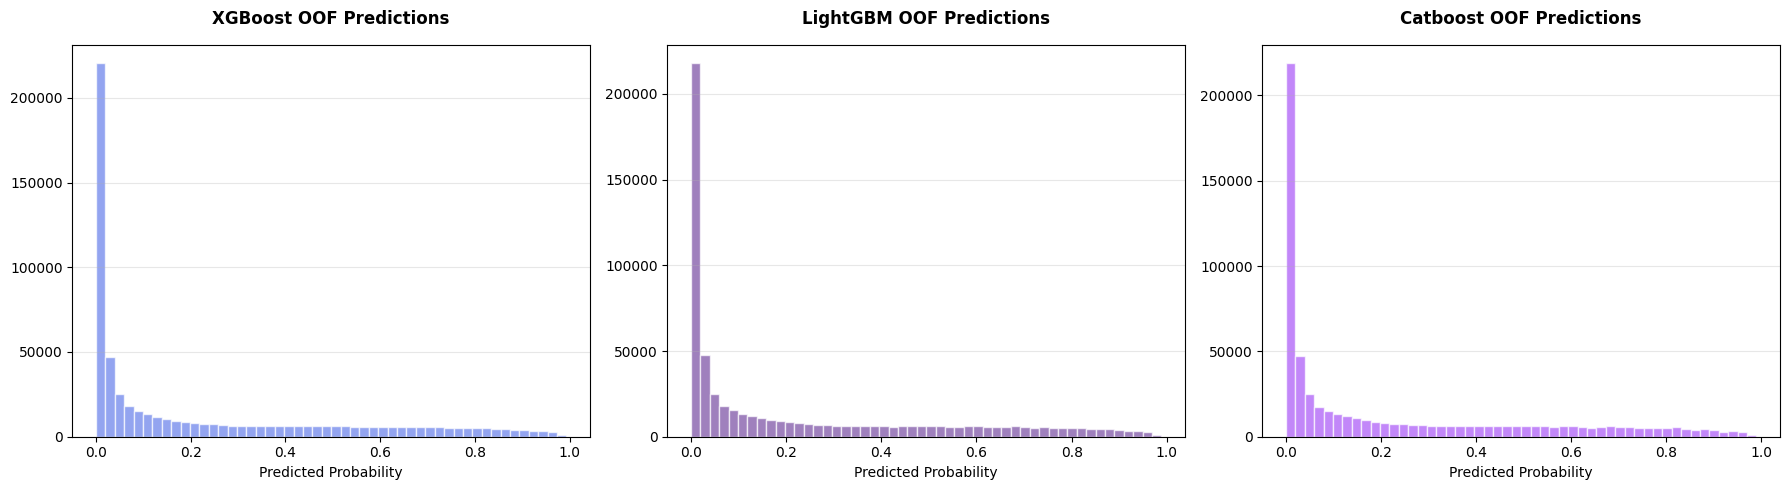

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].hist(xgb_oof_preds, bins=50, color=config.COLORS[0], alpha=0.7, edgecolor="white")
ax[0].set_title("XGBoost OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[0].set_xlabel("Predicted Probability", fontsize=10)
ax[0].grid(axis="y", alpha=0.3)

ax[1].hist(lgb_oof_preds, bins=50, color=config.COLORS[1], alpha=0.7, edgecolor="white")
ax[1].set_title("LightGBM OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[1].set_xlabel("Predicted Probability", fontsize=10)
ax[1].grid(axis="y", alpha=0.3)

ax[2].hist(cat_oof_preds, bins=50, color=config.COLORS[2], alpha=0.7, edgecolor="white")
ax[2].set_title("Catboost OOF Predictions", fontsize=12, fontweight="bold", pad=15)
ax[2].set_xlabel("Predicted Probability", fontsize=10)
ax[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Submission</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Submission
    </h1>
</div>

In [30]:
xgb_auc = roc_auc_score(y_train, xgb_oof_preds)
lgb_auc = roc_auc_score(y_train, lgb_oof_preds)
cat_auc = roc_auc_score(y_train, cat_oof_preds)

logger.info("*" * 80)
logger.info(f"XGB OOF AUC: {xgb_auc:.6f}")
logger.info(f"LGBM OOF AUC: {lgb_auc:.6f}")
logger.info(f"CATBOOST OOF AUC: {cat_auc:.6f}")
logger.info("*" * 80)

# Prepare submission file
if cat_auc > lgb_auc and cat_auc > xgb_auc:
    test_final_preds = catboost_test_preds
elif lgb_auc > cat_auc and lgb_auc > xgb_auc:
    test_final_preds = lgb_test_preds
else:
    test_final_preds = xgb_test_preds
    
submission = pd.DataFrame({
    "id": list_test_id,
    config.target_feature: test_final_preds
})
submission.to_csv("submission.csv", index=False)
logger.info("*" * 80)
logger.info("SUBMISSION SAVED")
logger.info("*" * 80)
submission.head()

2026-03-02 09:34:02 | INFO     | ********************************************************************************
2026-03-02 09:34:02 | INFO     | XGB OOF AUC: 0.915913
2026-03-02 09:34:02 | INFO     | LGBM OOF AUC: 0.915330
2026-03-02 09:34:02 | INFO     | CATBOOST OOF AUC: 0.915295
2026-03-02 09:34:02 | INFO     | ********************************************************************************
2026-03-02 09:34:02 | INFO     | ********************************************************************************
2026-03-02 09:34:02 | INFO     | SUBMISSION SAVED
2026-03-02 09:34:02 | INFO     | ********************************************************************************


,id,Churn
0,594194,0.082564
1,594195,0.000463
2,594196,0.100331
3,594197,0.003324
4,594198,0.518116


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f; 
    margin: 0 0 20px 0; 
    font-size: 22px; 
    font-weight: 600;
    letter-spacing: 0.5px;
">
🎯 Key Business Recommendations
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">1. Increase Long-Term Contract Adoption</b>
<ul>
<li>Promote incentives for <b>1–2 year contracts</b></li>
<li>Design upgrade campaigns to convert month-to-month customers to long-term plans</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Contract length is the strongest retention driver.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">2. Encourage Automatic Payments</b>
<ul>
<li>Offer small discounts for <b>automatic payments (bank transfer / credit card)</b></li>
<li>Reduce reliance on electronic check users</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Automatic payment methods are strongly associated with lower churn risk.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">3. Bundle Support & Security Add-Ons</b>
<ul>
<li>Create bundled packages: Internet + TechSupport + OnlineSecurity + DeviceProtection</li>
<li>Focus upselling on new customers during onboarding</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Support and protection services significantly reduce churn risk.
</div>
</div>

<div style="margin-bottom:20px;">
<b style="color:#f7dc6f;">4. Focus on Early Lifecycle Retention (0–12 Months)</b>
<ul>
<li>Improve onboarding experience</li>
<li>Implement proactive follow-ups at months 1, 3, and 6</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Churn risk is highest in the early customer lifecycle.
</div>
</div>

<div>
<b style="color:#f7dc6f;">5. Reassess Fiber Optic Segment</b>
<ul>
<li>Conduct deeper analysis on pricing, service quality, and expectation gaps</li>
<li>Consider pricing adjustments or service improvements</li>
</ul>
<div style="color:#d5dbdb; font-style:italic;">
→ Fiber optic customers show significantly higher churn rates.
</div>
</div>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Upvote if you liked it 🙌😊
    </p>
</div>
